# 07 · Did the regional campaign work?, synthetic control ⭐ (Anchor B)

**The business decision.** We ran a TV campaign in one metro area, a **DMA** (*Designated Market
Area*, the standard US media-buying region), and left the rest of the country dark. Sales in that
metro are up since launch. Before we spend to roll the campaign out nationally: **was the lift caused
by the campaign, or would sales have risen there anyway?**

### Why this is hard: there was no control group

Unlike the uplift notebook (01), here there is **no randomized hold-out**, we didn't flip a coin to
decide which metro got the campaign, we just picked one. So we can't simply compare it to "the others."
And we can't just compare the treated metro's sales *after* vs *before*, because sales everywhere are
pushed around by a shared **trend** (secular growth), **seasonality**, and a common **macro wave**
(the economy, category demand). A naive before/after would credit the campaign with an uplift the
market would have delivered on its own. We need the one thing we can never observe: **what sales in
that metro *would have been* if we had not run the campaign**, its *counterfactual*.

### The idea: build the counterfactual from the other markets

**Synthetic control** (Abadie & Gardeazabal, 2003) constructs that missing counterfactual as a
**weighted blend of the untreated markets**, the "**donor pool**." It searches for a set of weights
so that the blend closely tracks the treated market's sales *in the pre-launch period*. If a weighted
combination of, say, 60% Denver + 25% Phoenix + 15% others matched our metro week-for-week *before*
the campaign, then, assuming those markets keep moving together, that same blend is our best guess
of what our metro *would* have done *after*, absent the campaign. The **gap** between the metro's
actual sales and this "synthetic" version, after launch, is the estimated lift.

The reason it can work at all: all markets share the same underlying **factors** (trend, season,
macro). A blend of donors that matches the treated unit's pre-period is, in effect, matching it on
those shared factors, so the blend and the treated unit stay locked together *unless something (the
campaign) breaks them apart*.

We do this the Bayesian way, so instead of one number we get a **posterior**, a full distribution of
plausible lifts, which gives us honest uncertainty, a real significance test (a **placebo
permutation**, defined in Depth B), and robustness checks a VP of Growth can interrogate before
committing national budget.

### How this notebook is organised

The **7-step contract** (question · simulate a known truth · identify · estimate · validate · decide
in € · caveats) plus the full **three depths**. One thing to flag up front, because it shapes everything
after it: the first Bayesian model we fit (§4) assumes the weekly errors are **independent**, and §5
catches that assumption failing, its nominal-90% interval on the *total* lift covers the planted truth
only **50%** of the time. **§5z repairs the likelihood** with an AR(1) error and re-earns the interval
(**88%** coverage across 24 fresh panels); that AR(1) fit, not the iid one, is the model §6's euro
decision consumes. §5x then lays the classical, the iid and the AR(1) intervals side by side on the same
estimand and grades all three by measured coverage.

- **Depth A**, why the tempting naive estimators fail (a bake-off)
- **Depth B**, placebo inference in *space* and *time*, with the scale-free Abadie RMSE-ratio test
- **Depth C**, the euro rollout decision and its sensitivity to assumptions


In [1]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from cmp import dgp, estimators as est, policy, plots
from cmp.cache import load_or_run     # fit once, load forever, a live lecture never waits on NUTS
plots.use_style()

FAST = os.environ.get("CMP_FAST", "1") == "1"

# Panel choice, disclosed. Every simulated panel is one draw of the world, and they differ in how
# badly the donor pool fails to match the treated market's loading on the random-walk macro factor, 
# which is the whole subject of §5. Seed 3 (this notebook's original panel) turned out to sit at the
# ~15th percentile of that mismatch: an unusually *benign* draw, on which the failure §5 diagnoses is
# barely visible. Teaching a lesson about persistence on a panel that happens not to have any would be
# dishonest, so we use a panel with MEDIAN persistence (lag-1 residual autocorrelation 0.10, against a
# median of 0.09 across 20 seeds). It is representative, not cherry-picked: §5's coverage check refits
# on 24 fresh panels, and that ensemble, not this one panel, is what carries every claim below.
SEED = 5
CAMPAIGN_COST = 75.0             # €75k media spend (€000). iROAS = lift/cost ~ 3.5; the campaign clears break-even comfortably in expectation.
#   Apparent profit = revenue - cost ~ 185k looks like a slam dunk; the trap is that revenue != profit.
MARGIN = 0.35                    # gross margin: the firm keeps 35% of incremental SALES as profit.
#   Revenue is not profit: the campaign pays iff profit = MARGIN*lift > cost (i.e. lift > cost/MARGIN).
#   At 35% margin the ~260k lift is worth ~92k of profit against the 75k cost: positive in expectation
#   (net ~ +17k), yet P(profit>cost) ~ 0.78, short of the 0.90 bar -> TEST FURTHER, not a confident GO.
SC = dict(draws=600, tune=600, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
print(f"FAST={FAST}  SEED={SEED}  SC sampling={SC}")

FAST=False  SEED=5  SC sampling={'draws': 1500, 'tune': 1500, 'chains': 4}


## 2 · Simulate a ground truth (why fake data first)

As in every notebook here, we **cannot grade a causal method on real data**, the counterfactual
("what our metro would have done without the campaign") is never observed. So we build a simulator
where we *plant* the true lift, confirm the method recovers it, and only then trust it.

The simulator produces a weekly **sales panel**: a table with one row per market per week, for 30
DMAs over 60 weeks. Each market's sales are built from **shared latent factors**, a rising trend, a
seasonal cycle, and a random macro wave common to all markets, combined with that market's own
baseline level, its own sensitivity to each factor ("factor loadings"), and idiosyncratic noise. The
campaign launches in **week 40** in market 0 only, adding a **true +12% lift** from then on.

The shared macro wave is the villain: it moves *every* market together, so it's exactly what a naive
before/after would mistake for campaign effect. But it's also the hero of the method, because the
factors are *shared*, a weighted blend of the *other* markets can reconstruct market 0's untreated
path. That is precisely what makes the effect *identifiable* here (recoverable in principle), and the
plot below shows the setup: one dark line (treated) inside a bundle of grey donors, all riding the
same wave.

**The data-generating model**, exactly what `dgp.geo_panel` implements (defaults & seed in
`src/cmp/dgp.py`). Markets $i = 0,\dots,29$, weeks $t = 0,\dots,59$. Three **shared latent
factors**:

$$
\begin{aligned}
g_t &= 0.4\,t &&(\text{trend}),\\
s_t &= 8\sin\!\big(\tfrac{2\pi t}{26}\big) + 4\sin\!\big(\tfrac{2\pi t}{13}\big) &&(\text{season}),\\
m_t &= \sum_{u \le t} \eta_u,\;\; \eta_u \sim \mathcal N(0,\, 1.2^{2}) &&(\text{macro random walk}).
\end{aligned}
$$

Each market has its own baseline $c_i \sim U(80, 140)$ and factor loadings
$\lambda_{i} = (\lambda_{i1}, \lambda_{i2}, \lambda_{i3})$, each $\sim U(0.6, 1.4)$:

$$
Y_{it} = c_i + \lambda_{i1}\, g_t + \lambda_{i2}\, s_t + \lambda_{i3}\, m_t + \varepsilon_{it},
\qquad \varepsilon_{it} \sim \mathcal N(0,\, 3^{2}),
$$

and the campaign adds a **proportional lift to market 0 only**, from week 40:

$$
Y_{0t} = c_0 + \lambda_{01}\, g_t + \lambda_{02}\, s_t + \lambda_{03}\, m_t + \varepsilon_{0t}
  + \Delta_t, \qquad
\Delta_t = 0.12\,\big(c_0 + \lambda_{01}\, g_t + \lambda_{02}\, s_t + \lambda_{03}\, m_t\big)\,
  \mathbf 1[t \ge 40].
$$

This factor structure is precisely why synthetic control works here: every market rides the *same*
$(g_t, s_t, m_t)$, only with different loadings, so a convex combination of donors whose blended
loadings match $(\lambda_{01}, \lambda_{02}, \lambda_{03})$ reproduces market 0's untreated path.
It's also why the naive estimators fail, the random-walk $m_t$ moves all markets together, and a
before/after comparison books that shared drift as "lift."


Treated: dma_00, launch week 40.  TRUE lift €14.2k/week, total €284k.


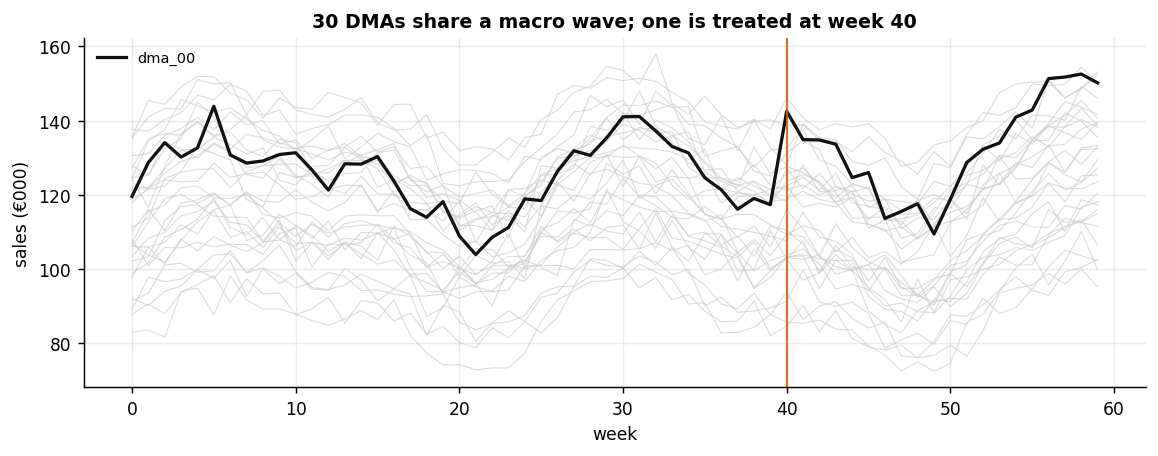

In [2]:
sales_df, true_effect, launch, treated_label = dgp.geo_panel(
    n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=SEED)
W = sales_df.shape[0]
sales = sales_df.values.T                        # (n_dmas, n_weeks)
treated_idx = list(sales_df.columns).index(treated_label)
pre, post = slice(0, launch), slice(launch, W)
t = np.arange(W)
true_total = float(true_effect[post].sum()); true_avg = float(true_effect[post].mean())

fig, ax = plt.subplots(figsize=(9, 3.6))
for j in range(sales.shape[0]):
    ax.plot(t, sales[j], color="#cccccc", lw=0.6, alpha=0.7)
ax.plot(t, sales[treated_idx], color="#111", lw=1.8, label=treated_label)
ax.axvline(launch, color=plots.ORANGE, lw=1); ax.set_title("30 DMAs share a macro wave; one is treated at week 40")
ax.set_xlabel("week"); ax.set_ylabel("sales (€000)"); ax.legend(frameon=False, fontsize=8); fig.tight_layout()
print(f"Treated: {treated_label}, launch week {launch}.  TRUE lift €{true_avg:.1f}k/week, total €{true_total:.0f}k.")

## 3 · Identify, the estimand and the assumptions it rests on

**The estimand (the precise thing we *want*).** For each post-launch week $t$, the causal effect on the
treated market is the potential-outcome contrast

$$\tau_t \;=\; Y_{0,t}(1) \;-\; Y_{0,t}(0), \qquad t > T_0,$$

where $Y_{0,t}(1)$ is **observed** (the campaign ran) but $Y_{0,t}(0)$, what week-$t$ sales *would have
been* with no campaign, is the **missing counterfactual**. (Throughout we label the treated unit **market 0**, matching §2's DGP and §4's fit, so the subscript is a *unit* index, not a treatment flag.)

**The estimator.** Synthetic control fills in that counterfactual with a weighted average of donor
markets, so the effect we actually compute is

$$\hat\tau_t \;=\; Y_{0,t} \;-\; \underbrace{\textstyle\sum_j w_j\, Y_{j,t}}_{\widehat{Y_{0,t}(0)}\ =\ \text{synthetic control}},
\qquad t > T_0,$$

where $Y_{0,t}$ is the **treated** market's sales in week $t$, $Y_{j,t}$ is **donor** market $j$'s
sales, $T_0$ is the launch week, and $w_j$ are the **donor weights**. The weights are chosen to match
the treated market's *pre-launch* path and are constrained to the **simplex**: each $w_j \ge 0$ and
they sum to 1 ($\sum_j w_j = 1$). Think of the simplex constraint as "the synthetic market must be a
genuine *weighted average* of real markets", no negative weights, no scaling beyond the observed
range.

**Why the simplex matters (the core of Abadie's method).** If instead we let weights be any numbers
(ordinary regression), the "synthetic" market could sit *outside* the range of any real market, 
**extrapolation** dressed up as a match, which fits the pre-period beautifully and then diverges wildly
after. Forcing weights onto the simplex keeps the synthetic inside the **convex hull** of the donors
(loosely, "inside the cloud of real markets"), which is what makes the post-launch projection credible.

**The assumptions, each gets an explicit check later:**

| assumption | plain meaning | checked in |
|, |, |, |
| **convex hull / no extrapolation** | the treated market lies inside the donor cloud; simplex weights enforce it | weights (Step 4) |
| **good pre-fit** | the synthetic actually tracks the treated market *before* launch | pre-RMSE gate (Step 5) |
| **no anticipation** | nothing shifts sales *before* launch (no leaked campaign, no pre-buying) | placebo-in-time (Depth B) |
| **stable factor structure** | donors and treated keep co-moving *after* launch (the loadings matched pre-launch still hold) | long pre-period + placebo-in-time |
| **no spillover / interference** | the campaign in market 0 doesn't change donor markets (SUTVA, the Stable Unit Treatment Value Assumption, for geos) | stress-tested by simulation (Depth B): planted spillover *attenuates* the estimate, and excluding the contaminated donors restores it, placebo-in-space *cannot* detect spillover (it contaminates every placebo too), so on real data exclude adjacent / media-overlapping donors up front |
| **no concurrent treated shock** | nothing else hit market 0 exactly at launch | untestable, institutional knowledge only |


## Step 0 · The classical read (no likelihood, no priors, no sampler)

Before any Bayesian machinery, ask what a competent analyst does here **without** it. The answer is not
a different analysis: it is the **same estimand** (§3's per-week gap $\tau_t$, and its 20-week total),
identified by the **same assumptions** (§3's table, convex hull, good pre-fit, no anticipation, no
spillover). The causal work lives in the identification, not in the machinery. In this notebook that is
unusually easy to see, because the classical estimator *is* the method: Abadie & Gardeazabal's synthetic
control was born frequentist, and §4's Dirichlet model is its Bayesian re-housing, not a rival.

**The estimator, naked.** Pick the donor weights that best reproduce the treated market's *pre-launch*
path, subject to §3's simplex constraint:

$$\hat w \;=\; \arg\min_{w\,\in\,\Delta^{J-1}} \;\sum_{t\,<\,T_0}\Big(Y_{0t} \;-\; \sum_{j=1}^{J} w_j\,Y_{jt}\Big)^{2},
\qquad
\Delta^{J-1} \;=\; \Big\{\, w \;:\; w_j \ge 0,\;\; \textstyle\sum_j w_j = 1 \,\Big\}.$$

That is constrained least squares, a quadratic objective on a convex set, solved numerically by
**SLSQP** (`scipy`'s *Sequential Least-Squares Quadratic Programming* optimizer; wrapped as
`est.sc_weights_slsqp`). It is **deterministic**, runs in milliseconds, and returns one number per donor.
The counterfactual and the effect then follow by plug-in, no further estimation:

$$\widehat{Y_{0t}(0)} \;=\; \sum_j \hat w_j\, Y_{jt},
\qquad \hat\tau_t \;=\; Y_{0t} - \widehat{Y_{0t}(0)},
\qquad \widehat{\text{total lift}} \;=\; \sum_{t \,\ge\, T_0} \hat\tau_t .$$

Nothing else is fitted: no variance parameter, no prior, no chain. (This same fitter carries *every*
robustness check in the notebook, leave-one-out in §5, the placebos below, the launch-date sweep and the
spillover stress test in Depth B/C, precisely because it is cheap and deterministic.)

**Now the hard part: where does an interval come from?** Nowhere, by the usual route. There is no
likelihood, so there is no standard error to read off a fit; and even if we bolted a regression standard
error onto the gap, it would be answering the wrong question, standard errors describe variability
across many independent treated units, and we have **exactly one**. Abadie's own answer, and the
inferential heart of the method, is **placebo (permutation) inference**:

> Under the null "the campaign did nothing to market 0", market 0 is *just another market*. So refit the
> identical estimator on each donor **as if it had been treated**, collect the post-launch gaps those
> placebo fits produce, that is the distribution of gaps the world hands you from noise alone, and ask
> where the real one **ranks**.

Two refinements, both Abadie's, both used below:

- **Discard placebos with a poor pre-fit** (here: pre-RMSE more than 5× the treated unit's). A donor the
  synthetic cannot match *before* launch produces a meaningless gap that would only pollute the reference
  distribution.
- **Rank on the RMSE *ratio*, not the raw gap**: post-period RMSE ÷ pre-period RMSE. It is **scale-free**
  (fair across big and small markets) and refuses to reward a placebo that simply fits badly *everywhere*
  (high post **and** high pre → ratio ≈ 1).

The **p-value** is the treated market's rank in that ratio distribution. And an *interval* can be
recovered from the very same null, by **inversion**: the placebo totals map out how far the estimator's
20-week total wanders when the true effect is zero, so subtracting that distribution's 5th and 95th
percentiles from our estimate gives a 90% **randomization interval** for the lift (valid under a
constant-effect null, we borrow the placebos' *spread*, not their location). It is a genuinely
design-based interval: it never assumes a shape for the errors, it *measures* it.

Depth B opens the placebo box in full, the whole spaghetti of placebo gaps, how the verdict moves with
that 5× filter, and the mirror test (placebo-in-*time*). Step 0 needs only its headline number.

CLASSICAL SYNTHETIC CONTROL, SLSQP simplex weights, fit on weeks 0–39
  29 donors: 5 carry >1% of the weight; 3.3 effective donors (1/Σw²)
  pre-fit RMSE €3.23k, the gate: the synthetic must track the
              treated market BEFORE launch, or the post gap means nothing
  lift  €13.0k/week  ·  total €260k over 20 post-launch weeks
  GRADE vs the planted €284k total: off by €-24k (-8%)

INFERENCE, no likelihood, so no standard error. Rank the real gap
            against the placebo null instead:
  Abadie RMSE-ratio p = 0.033, treated ranks 1 of 30 markets (ratio 4.3
                          vs a placebo median of 1.4)
  raw-gap permutation p = 0.033, 29 of 29 donors survived the
                          5x pre-fit filter (Depth B reconciles the two p's)
  90% randomization interval on the total (placebo null, inverted):
      [€195k, €335k], the planted €284k falls INSIDE it

What this 90% confidence interval does NOT say: that there is a 90% probability the true effect lies insi

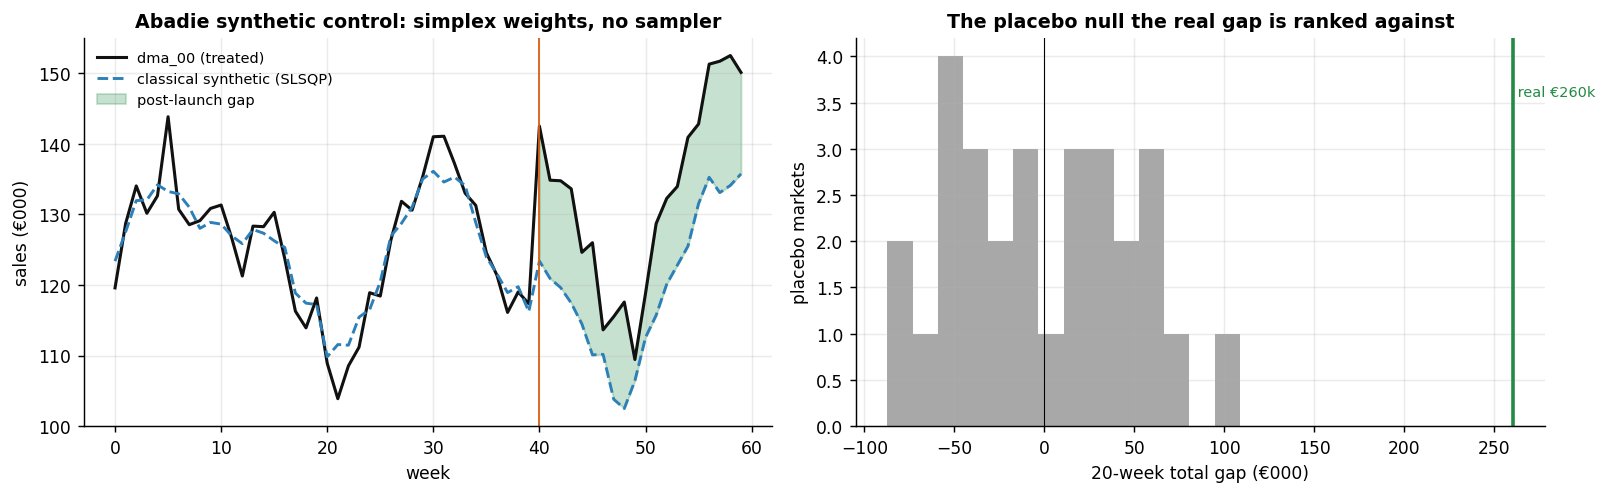

In [3]:
from cmp import classical as cl

# The donor pool: every market except the treated one. Defined here, in Step 0, because the classical
# fit needs it first, §4's Bayesian fit and every check downstream reuse these same three objects.
donors = np.delete(sales, treated_idx, axis=0)
donor_labels = [c for c in sales_df.columns if c != treated_label]
y_tr = sales[treated_idx]
n_post = len(t[post])

# --- 1 · The classical synthetic control: simplex weights by SLSQP, fitted on the PRE-period only ---
gap_cl, w_cl = est.sc_effect_slsqp(y_tr, donors, pre, post)   # gap = treated - synthetic, every week
cf_cl = y_tr - gap_cl                                         # the classical counterfactual path
pre_rmse_cl = float(np.sqrt(np.mean(gap_cl[pre] ** 2)))
total_cl, avg_cl = float(gap_cl[post].sum()), float(gap_cl[post].mean())
eff_n_cl = 1.0 / np.sum(w_cl ** 2)                            # effective donors (inverse Herfindahl)

# --- 2 · Inference, the classical way: refit the estimator on every donor AS IF it were treated ---
placebo_gaps, real_gap, p_space = est.placebo_in_space(     # raw-gap permutation, Abadie pre-fit filter
    sales, treated_idx, pre, post, pre_rmse=None, rmse_multiple=5.0)

def rmse_ratio(gap):                                        # Abadie's scale-free test statistic
    pre_r = np.sqrt(np.mean(gap[pre] ** 2)); post_r = np.sqrt(np.mean(gap[post] ** 2))
    return post_r / max(pre_r, 1e-9)

ratios = []                                                 # the statistic for EVERY unit (treated + donors)
for j in range(sales.shape[0]):
    others = np.delete(np.arange(sales.shape[0]), [treated_idx, j])   # the treated unit is never a donor:
    gap, _ = est.sc_effect_slsqp(sales[j], sales[others], pre, post)  # its post-period is contaminated
    ratios.append(rmse_ratio(gap))
ratios = np.array(ratios); treated_ratio = ratios[treated_idx]
rank = int(np.sum(ratios >= treated_ratio)); p_ratio = rank / len(ratios)

# --- 3 · An interval WITHOUT a likelihood: invert the placebo null of the 20-week total ---
placebo_tot = placebo_gaps[:, post].sum(1)          # totals under "no campaign" (no donor ran one)
ri_lo = total_cl - np.quantile(placebo_tot, 0.95)   # inversion: estimate - the null's upper/lower tail
ri_hi = total_cl - np.quantile(placebo_tot, 0.05)
sc_cl = cl.Classical(name="Total post-launch lift (classical SC)", estimate=total_cl,
                     se=float(placebo_tot.std()), ci=(float(ri_lo), float(ri_hi)), alpha=0.10,
                     cov="placebo randomization (Abadie permutation), constant-effect null",
                     n=int(sales.shape[0]), extra={"p_rmse_ratio": p_ratio})

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))
ax[0].plot(t, y_tr, color="#111", lw=1.7, label=f"{treated_label} (treated)")
ax[0].plot(t, cf_cl, color=plots.BLUE, ls="--", lw=1.6, label="classical synthetic (SLSQP)")
ax[0].fill_between(t[post], cf_cl[post], y_tr[post], color=plots.GREEN, alpha=0.25, label="post-launch gap")
ax[0].axvline(launch, color=plots.ORANGE, lw=1)
ax[0].set_xlabel("week"); ax[0].set_ylabel("sales (€000)"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title("Abadie synthetic control: simplex weights, no sampler")
ax[1].hist(placebo_tot, bins=14, color=plots.GREY, alpha=0.85)
ax[1].axvline(total_cl, color=plots.GREEN, lw=2)
ax[1].text(total_cl, ax[1].get_ylim()[1] * 0.85, f" real €{total_cl:.0f}k", fontsize=8, color=plots.GREEN)
ax[1].axvline(0, color="k", lw=0.6)
ax[1].set_xlabel(f"{n_post}-week total gap (€000)"); ax[1].set_ylabel("placebo markets")
ax[1].set_title("The placebo null the real gap is ranked against")
fig.tight_layout()

print(f"CLASSICAL SYNTHETIC CONTROL, SLSQP simplex weights, fit on weeks 0–{launch - 1}")
print(f"  {donors.shape[0]} donors: {(w_cl > 0.01).sum()} carry >1% of the weight; "
      f"{eff_n_cl:.1f} effective donors (1/Σw²)")
print(f"  pre-fit RMSE €{pre_rmse_cl:.2f}k, the gate: the synthetic must track the")
print(f"              treated market BEFORE launch, or the post gap means nothing")
print(f"  lift  €{avg_cl:.1f}k/week  ·  total €{total_cl:.0f}k over {n_post} post-launch weeks")
print(f"  GRADE vs the planted €{true_total:.0f}k total: off by €{total_cl - true_total:+.0f}k "
      f"({(total_cl - true_total) / true_total:+.0%})")
print("\nINFERENCE, no likelihood, so no standard error. Rank the real gap")
print("            against the placebo null instead:")
print(f"  Abadie RMSE-ratio p = {p_ratio:.3f}, treated ranks {rank} of {len(ratios)} markets "
      f"(ratio {treated_ratio:.1f}")
print(f"                          vs a placebo median of {np.median(ratios):.1f})")
print(f"  raw-gap permutation p = {p_space:.3f}, {len(placebo_gaps)} of {donors.shape[0]} donors survived the")
print(f"                          5x pre-fit filter (Depth B reconciles the two p's)")
print(f"  90% randomization interval on the total (placebo null, inverted):")
print(f"      [€{ri_lo:.0f}k, €{ri_hi:.0f}k], the planted €{true_total:.0f}k falls "
      f"{'INSIDE' if ri_lo <= true_total <= ri_hi else 'OUTSIDE'} it")
print("\n" + sc_cl.cannot_say())


**Read-out, the classical answer, in business terms.** The synthetic market tracks the treated one before
launch to within the pre-fit RMSE printed above (a couple of € thousand on weekly sales of €80–170k), which
is the *precondition* for reading anything into the post-launch gap, and that gap is the campaign's
estimated lift: the per-week and total euro figures above, graded against the planted truth in the same
line. The estimator lands close, and slightly **low**, hold that undershoot, §5x and §7 return to it.

Look at the weight count while you are here: classical SC puts real weight on a **handful** of donors, the
sparse blend Abadie's method is famous for, and a genuinely useful business object ("our metro behaves like
this specific mix of a few named other metros"). §4's Dirichlet prior will instead spread weight thinly
over *many* donors: more stable out-of-sample, less interpretable, and the reason §5's leave-one-out chart
carries two nearby-but-distinct baselines ("all donors (SLSQP)" and "all donors (Bayesian)").

**What the placebo p-value *is*.** It is a **randomization-inference** p-value: *if the campaign had done
nothing, a post-launch jump this extreme, relative to its own pre-fit, would have turned up in about this
fraction of markets*. It is a statement about a **null** and about a **procedure**: we ran the same estimator
on markets we know were untreated, and the treated market's statistic came out at the printed rank.

**What it is not**, and this is the same guardrail this cookbook states in every notebook, sharpened by the
fact that the classical arm here has *no interval at all* by default, only a rank. It is **not** the
probability that the campaign had no effect. It is **not** one minus the probability the campaign worked. And
it is emphatically **not** the probability that the campaign **paid**, the question §6 has to sign off on,
which involves the €75k cost and the 35% gross margin, numbers the p-value has never met. The randomization
interval we inverted out of the same placebo null is a *confidence* interval and inherits exactly the limits
printed above: 90% of intervals built that way cover the truth **across repeated samples** (§5x actually goes
and measures that rate, on fresh panels, it is one of the few places in this cookbook where the "repeated
samples" story is literally executed), and this particular one either covers the truth or it does not.

So: no likelihood, no prior, no sampler, and already a lift estimate, a falsification test, and an honest
interval. **This is the baseline the Bayesian section must justify itself against.** What it cannot produce,
at any level of effort, is $P(\text{lift} > \text{cost})$. That quantity does not exist in its vocabulary; it
exists in a posterior. §4 builds one, and §5x asks, with numbers, whether it is a *trustworthy* one.

## 4 · Estimate, a Bayesian synthetic control

We put a **Dirichlet prior** on the donor weights and fit them to the pre-period. (The *Dirichlet* is
the natural probability distribution over the simplex, draws from it are automatically non-negative
and sum to 1, so it's the Bayesian way to say "the weights live on the simplex.") Fitting returns a
**posterior** over the weights, and therefore a posterior over the whole counterfactual path and the
lift, Abadie's constrained least squares, but with uncertainty for free.

**The fitted model, in symbols.** With $Y_{0t}$ the treated market and $Y_{jt}$ the $J = 29$
donors, fit **on the pre-period only** ($t < 40$):

$$
Y_{0t} \sim \mathcal N\Big(\textstyle\sum_{j=1}^{J} w_j\, Y_{jt},\;\; \sigma^{2}\Big), \qquad
w \sim \text{Dirichlet}(\mathbf 1_J), \qquad \sigma \sim \text{HalfNormal}(5).
$$

$\text{Dirichlet}(\mathbf 1_J)$ is flat over the simplex, no donor favoured a priori, weights
non-negative and summing to 1 by construction. The $\sigma \sim \text{HalfNormal}(5)$ scale is
likewise tied to the units of the data: sales are in €000s, weekly levels sit around €80–170k, and
the DGP's idiosyncratic noise has sd €3k, so a prior sd scale of €5k is weakly informative on the
residual: wide enough to cover any plausible blend error, tight enough to rule out absurd ones (a
€50k weekly residual would mean the "synthetic" tracks nothing). The counterfactual for *every* week is then the
posterior-predictive blend $\hat Y_{0t}^{(0)} = \sum_j w_j Y_{jt} + \varepsilon_t$ with
$\varepsilon_t \sim \mathcal N(0, \sigma^{2})$, the $\varepsilon_t$ matters: dropping it (using
the mean blend alone) understates the uncertainty band, which is exactly the coverage lesson step
5 quantifies, and the weekly lift is $Y_{0t} - \hat Y_{0t}^{(0)}$.

Two things to read off the fit:
- **Which donors** the synthetic leans on (the weight bars). One caveat to state plainly: the Dirichlet
  prior produces a *regularized blend* spread over many donors, rather than classical synthetic
  control's sparse handful. That's **more stable** out-of-sample but **less individually interpretable**.
  We summarise the spread as an **"effective number of donors"** = $1/\sum_j w_j^2$ (the inverse
  Herfindahl index, 1 if all weight is on one donor, $J$ if spread evenly over $J$ donors).
- **Pre-fit RMSE**, the root-mean-square gap between the treated market and its synthetic *before*
  launch, in €000. Small means the synthetic is a good stand-in; this is the precondition for believing
  the post-launch gap, Step 5 turns this into a concrete PASS/FAIL gate (pre-RMSE below ~a third of the weekly lift it must detect).

**Reading the sampler's health check.** The `convergence` line printed below reports the three standard MCMC health checks, the numbers that say whether the sampler (the algorithm that draws from the posterior) actually converged. **R-hat** compares the variance within each chain to the variance across chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar**. **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth, a few hundred is ample for a posterior mean or interval. **Divergences** are steps where the sampler broke down and silently distrusts that region; **you want 0**. Under this notebook's FAST teaching profile the chains are deliberately short (2 chains × 600 draws), so R-hat can sit a hair over the 1.01 line and PyMC may print a "problems during sampling" notice, a benign small-draw-count artifact that a FULL run clears. Here, at FULL (4 chains × 1,500 draws), the health check below prints a clean pass: R-hat 1.000, minimum ESS in the thousands, and **0 divergences**, with no warning beside it. Read the printed line, not this paragraph, it is the one that ran.

> **On real data.** You don't need our simulator, this method runs on *your own* weekly (or daily)
> sales-by-market panel, which every company already has: one treated market, the rest as donors. The
> canonical *public* example is Abadie's **California Proposition 99** tobacco study (California vs 38
> other US states); it has the identical shape (one treated unit, many donors, a known intervention
> date) and is the standard dataset to reproduce this on.


[cache] loaded '07_sc_iid' (7s fit, cached 50.1h ago) — nothing re-sampled.
SC sampling convergence: max r-hat 1.000 - min ESS 5379 - divergences 0


pre-fit RMSE €4.15k  ·  estimated total lift €229k (true €284k)  ·  90% CI [€186k, €273k], at full precision the truth sits just OUTSIDE this band (§5's multi-seed check explains why the total-lift band runs optimistic)


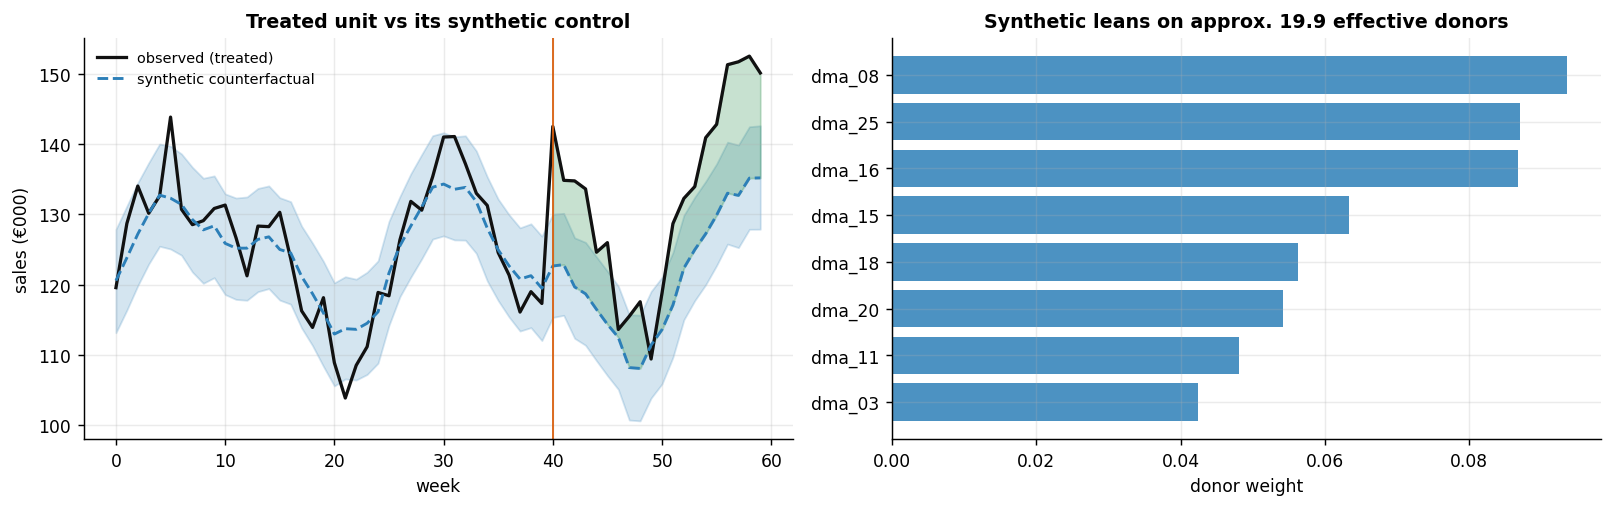

In [4]:
# donors / donor_labels / y_tr were built in Step 0, the same donor pool, refit Bayesianly.
# This is our FIRST model, bound to its own name (sc_iid) so nothing downstream can
# confuse it with the shipped fit. It assumes the weekly errors are independent. §5 will put that
# assumption on trial, §5z will convict it, and the fix is what we actually ship.
sc_iid = load_or_run("07_sc_iid", lambda: est.synthetic_control(y_tr, donors, pre, post, seed=1, **SC),
                 inputs=dict(seed=SEED, model="iid", **SC))
print(f"SC sampling convergence: {sc_iid['convergence']['summary']}")
cf_iid = sc_iid["counterfactual_samples"]; effect_iid = sc_iid["effect_samples"]
total_post_iid = effect_iid[:, post].sum(1)
w_mean_iid = sc_iid["weight_samples"].mean(0)
eff_n_iid = 1.0 / np.sum(w_mean_iid**2)               # effective number of donors (inverse HHI)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf_iid, launch, xlabel="week", ylabel="sales (€000)")
topw = np.argsort(-w_mean_iid)[:8]
ax[1].barh([donor_labels[i] for i in topw][::-1], w_mean_iid[topw][::-1], color=plots.BLUE, alpha=0.85)
ax[1].set_xlabel("donor weight"); ax[1].set_title(f"Synthetic leans on approx. {eff_n_iid:.1f} effective donors")
fig.tight_layout()
lo_t, hi_t = np.quantile(total_post_iid, [0.05, 0.95])
print(f"pre-fit RMSE €{sc_iid['pre_rmse']:.2f}k  ·  estimated total lift €{total_post_iid.mean():.0f}k "
      f"(true €{true_total:.0f}k)  ·  90% CI [€{lo_t:.0f}k, €{hi_t:.0f}k], at full precision the truth "
      f"sits {'inside' if lo_t <= true_total <= hi_t else 'just OUTSIDE'} this band "
      f"(§5's multi-seed check explains why the total-lift band runs optimistic)")

## 5 · Validate, recovery, calibration, the pre-fit gate, and robustness

Four checks, and one of them delivers a genuinely humbling result we keep rather than hide (and then,
in §5z, repair):

1. **Recovery & calibration.** The true per-week path should sit inside the posterior band. That
   band is a **posterior predictive**: it carries not only *which-donors* (weight) uncertainty but
   the treated market's own idiosyncratic noise. That noise term is what makes the per-week band
   near-nominal; a weights-only band is too narrow and can leave the truth *outside* a "90%" interval.
2. **Multi-seed calibration.** One panel is a single draw of the world, so we refit on 24 fresh panels and
   report the recovery bias and the coverage, **for both likelihoods**, §4's iid model and §5z's AR(1)
   model, on identical worlds, so the comparison is measured rather than argued. The honest result: both
   cover the **per-week** path about right (86% and 94% against a nominal 90%), but the **total-lift**
   interval of the *iid* model covers only **50%** of the time, synthetic control's genuine
   sample-to-sample variance (sd €59k) is more than double what that posterior believes (sd €24k). That is
   a defect of the **likelihood**, not of the paradigm: §5z puts the persistence into the error model and
   the total-lift interval goes back to covering **88%**, in the same range as the design-based placebo interval (**83%**).
   Until that fix lands, the trustworthy inference about the total is the **placebo permutation test**
   (design-based, calibrated by construction), not the iid band. *(The per-seed refits in this check are
   deliberately coarse 300-draw probes, read only in aggregate; their sampler chatter is silenced.)*
3. **Pre-fit gate**, the pre-period gap must hover around **zero**: concretely, pre-RMSE below about a
   third of the weekly lift the design must detect. The cell below prints the gate for the §4 iid fit;
   §5z re-runs the same gate on the AR(1) fit we actually *ship*, and the shipped fit's gate is the one
   §6 and §7 read. A bad synthetic match makes the post gap meaningless, this is the precondition, not a
   formality. **In this panel the gate FAILS on both fits**, §5z's gate line prints pre-RMSE **€5.06k**
   against a **€4.4k** bar for the shipped fit. The pre-launch gap still averages under €1k (no systematic
   mis-fit), but the synthetic's week-to-week wobble is more than a third of the weekly lift it is being
   asked to detect, this design sits at the *edge of its resolution*, and that is one more reason to read
   §6's euro call as cautiously as it reads itself.
4. **Leave-one-out donor robustness**, drop each of the top-weighted donors and refit; if the
   estimate lurches when one donor leaves, the result hangs on a single market and is fragile.


   These leave-one-out refits, and every robustness check from here on (placebo, spillover, launch-date
   sweep), use **Step 0's classical SLSQP fitter**: deterministic, no MCMC, milliseconds per refit, and a
   *point estimate only*. We benchmark each dropped-donor bar against that same fitter's own all-donor
   baseline (the grey line, i.e. Step 0's estimate) so the comparison is apples-to-apples; that SLSQP
   baseline runs a touch wider than the Bayesian fit because the Dirichlet prior lightly regularizes the
   blend, which is why the plot labels "all donors (SLSQP)" and "all donors (Bayesian)" as two
   nearby-but-distinct numbers.


pre-fit gate (iid fit, §5z re-runs this on the shipped AR(1) fit): pre-RMSE €4.15k  vs  |weekly lift|/3 = €3.8k  ->  FAIL
pre-launch gap mean €0.54k (≈0 = good fit).  LOO total range €239–276k vs the same-fitter SLSQP baseline €260k (Bayesian €229k), no single donor drives it.


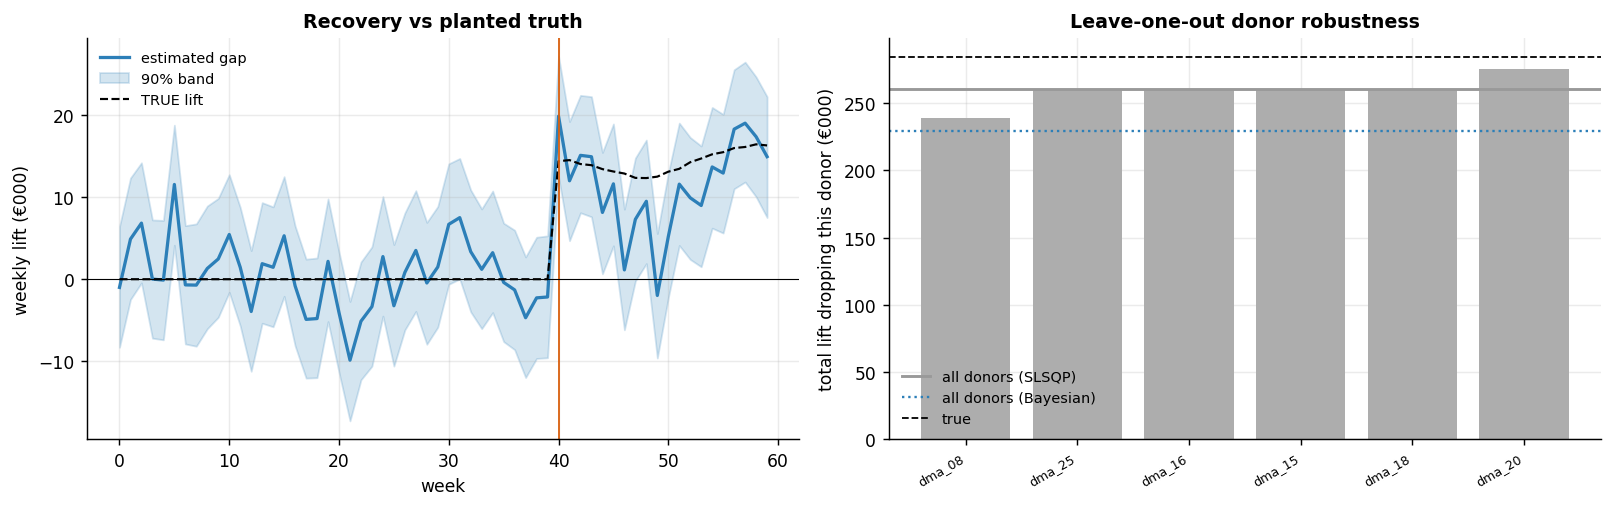

In [5]:
eff_mean_iid = effect_iid.mean(0); eff_lo_iid, eff_hi_iid = np.quantile(effect_iid, [0.05, 0.95], 0)
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].plot(t, eff_mean_iid, color=plots.BLUE, lw=1.8, label="estimated gap")
ax[0].fill_between(t, eff_lo_iid, eff_hi_iid, color=plots.BLUE, alpha=0.2, label="90% band")
ax[0].plot(t, true_effect, color="k", ls="--", lw=1.2, label="TRUE lift")
ax[0].axvline(launch, color=plots.ORANGE, lw=1); ax[0].axhline(0, color="k", lw=0.6)
ax[0].set_xlabel("week"); ax[0].set_ylabel("weekly lift (€000)"); ax[0].set_title("Recovery vs planted truth")
ax[0].legend(frameon=False, fontsize=8)

# leave-one-out: drop each top donor, refit with the fast SLSQP fitter
loo = []
for i in topw[:6]:
    keep = [k for k in range(donors.shape[0]) if k != i]
    gap, _ = est.sc_effect_slsqp(y_tr, donors[keep], pre, post)
    loo.append(gap[post].sum())
full_total = eff_mean_iid[post].sum()
slsqp_full_total = total_cl        # Step 0's classical all-donor estimate = the same-fitter LOO baseline
ax[1].axhline(slsqp_full_total, color=plots.GREY, lw=1.6, label="all donors (SLSQP)")
ax[1].axhline(full_total, color=plots.BLUE, ls=":", lw=1.3, label="all donors (Bayesian)")
ax[1].axhline(true_total, color="k", ls="--", lw=1, label="true")
ax[1].bar(range(len(loo)), loo, color=plots.GREY, alpha=0.8)
ax[1].set_xticks(range(len(loo))); ax[1].set_xticklabels([donor_labels[i] for i in topw[:6]], rotation=30, ha="right", fontsize=7)
ax[1].set_ylabel("total lift dropping this donor (€000)"); ax[1].set_title("Leave-one-out donor robustness")
ax[1].legend(frameon=False, fontsize=8); fig.tight_layout()
# Pre-fit gate, made concrete: pre-RMSE must be small RELATIVE TO the weekly lift it must detect
# (a non-oracle scale, uses the estimated lift, not the planted truth). This line grades the §4 iid
# fit; §5z re-runs the SAME gate on the AR(1) fit we actually ship, and THOSE are the numbers that count.
weekly_lift_iid = total_post_iid.mean() / n_post
gate_ref_iid = abs(weekly_lift_iid) / 3
gate_iid = "PASS" if sc_iid["pre_rmse"] < gate_ref_iid else "FAIL"
print(f"pre-fit gate (iid fit, §5z re-runs this on the shipped AR(1) fit): "
      f"pre-RMSE €{sc_iid['pre_rmse']:.2f}k  vs  |weekly lift|/3 = €{gate_ref_iid:.1f}k  ->  {gate_iid}")
print(f"pre-launch gap mean €{eff_mean_iid[pre].mean():.2f}k (≈0 = good fit).  "
      f"LOO total range €{min(loo):.0f}–{max(loo):.0f}k vs the same-fitter SLSQP baseline €{slsqp_full_total:.0f}k "
      f"(Bayesian €{full_total:.0f}k), no single donor drives it.")

In [6]:
# Multi-seed recovery + calibration. One panel is a single draw of the world, so we refit on
# fresh panels and report (a) the recovery bias, (b) how often the PER-WEEK band covers the
# true path, and (c) how often the TOTAL-lift 90% interval covers the planted total. The gap
# between (b) and (c) is the honest lesson.
#
# We fit BOTH likelihoods on every panel, the iid model of §4 and the AR(1) model of §5z, so
# the coverage comparison that decides the notebook is measured on identical worlds, not argued.
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses, the low-ESS notice is logged at ERROR level); restored at the end of the cell
N_PANELS = 10 if FAST else 24
MS_SC = {**SC, "draws": 300, "tune": 300}

def _multiseed():
    rows = []
    for s in range(N_PANELS):
        sd_, te_, _lz, tl_ = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=100 + s)
        sl = sd_.values.T; ti = list(sd_.columns).index(tl_)
        dn = np.delete(sl, ti, axis=0); truth = float(te_[post].sum())
        r = {"true": truth}
        for tag, fn in (("iid", est.synthetic_control), ("ar1", est.synthetic_control_ar1)):
            scs = fn(sl[ti], dn, pre, post, seed=1, **MS_SC)
            eff = scs["effect_samples"]; tot = eff[:, post].sum(1)
            lo, hi = np.quantile(tot, [.05, .95]); elo, ehi = np.quantile(eff, [.05, .95], 0)
            r[f"err_{tag}"] = tot.mean() - truth
            r[f"tot_cov_{tag}"] = bool(lo <= truth <= hi)
            r[f"tot_sd_{tag}"] = tot.std()          # what THIS posterior believes the total's sd is
            r[f"wk_cov_{tag}"] = np.mean((elo[post] <= te_[post]) & (te_[post] <= ehi[post]))
        rows.append(r)
    return pd.DataFrame(rows)

ms = load_or_run("07_multiseed_iid_vs_ar1", _multiseed,
                 inputs=dict(n=N_PANELS, **MS_SC))
_pml.setLevel(_pml_lvl)

print(f"Across {len(ms)} fresh panels, recovery bias €{ms.err_iid.mean():+.0f}k "
      f"({ms.err_iid.mean()/ms['true'].mean():+.0%} of the truth).\n")
print(f"{'likelihood':<12}{'per-week cov':>14}{'TOTAL cov':>12}{'posterior sd':>14}{'actual sd':>11}")
for tag in ("iid", "ar1"):
    print(f"{tag:<12}{ms[f'wk_cov_{tag}'].mean():>13.0%}{ms[f'tot_cov_{tag}'].mean():>12.0%}"
          f"{ms[f'tot_sd_{tag}'].mean():>13.0f}k{ms[f'err_{tag}'].std():>10.0f}k")
print("\nBoth models cover the PER-WEEK path about right. Only one of them covers the TOTAL, ")
print("the number the euro decision in §6 actually integrates. That gap is §5's whole subject.")

[cache] MISS '07_multiseed_iid_vs_ar1' — fitting (this is the slow path)...


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [w, sd]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 2 seconds.


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [w, sigma, rho]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 1 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


[cache] stored '07_multiseed_iid_vs_ar1' after 169s -> 07_multiseed_iid_vs_ar1-9b9013c05851-1512fadbf2e9.pkl
Across 24 fresh panels, recovery bias €+23k (+7% of the truth).

likelihood    per-week cov   TOTAL cov  posterior sd  actual sd
iid                   86%         50%           24k        59k
ar1                   94%         88%           94k        87k

Both models cover the PER-WEEK path about right. Only one of them covers the TOTAL, 
the number the euro decision in §6 actually integrates. That gap is §5's whole subject.


**Why does the *iid* model's total-lift band under-cover while its per-week bands are fine?** This is the
notebook's most important negative result, and it is not a mystery, nor a defect of the paradigm: it
follows from exactly one modelling choice, which §5z will undo. The §4 likelihood treats the weekly errors
as independent, so if $e_t$ is the error of the synthetic blend in week $t$, the model prices the
uncertainty of the $n = 20$-week **total** as

$$\operatorname{sd}\Big(\sum_{t \in \text{post}} e_t\Big) \;=\; \sqrt{n}\,\sigma
\qquad \text{(iid errors)}.$$

But the blend's true error is *not* iid. Whatever part of the treated market's factor loadings the
weights fail to match leaks the shared factors straight into the gap,

$$e_t \;\approx\; \big(\lambda_0 - \textstyle\sum_j w_j \lambda_j\big)^{\!\top}
(g_t,\, s_t,\, m_t) \;+\; \varepsilon_{0t},$$

and $m_t$ is a **random walk**. Over a 20-week window a random walk barely turns around: the mismatch
term is, to a good approximation, a **constant offset**, one draw of "how badly did this donor pool
match?", that persists for the whole post-period. So model the error as

$$e_t \;=\; c \;+\; \varepsilon_t, \qquad
c \sim (0,\ \sigma_c^2)\ \text{drawn once per panel}, \qquad
\varepsilon_t \sim (0,\ \sigma_\varepsilon^2)\ \text{fresh each week}.$$

Two consequences follow, and they are the whole section.

**1. The autocorrelation is FLAT.** For this error,

$$\rho_k \;=\; \frac{\sigma_c^2}{\sigma_c^2 + \sigma_\varepsilon^2} \qquad \textbf{for every lag } k,$$

which does not decay. That flatness is the fingerprint: a short-memory process (AR(1) with $\rho < 1$,
say) *decays*, $\rho_k = \rho^k \to 0$, whereas a persistent offset does not. **So the diagnostic to
look at is not how big $\rho_1$ is; it is whether $\rho_8$ is still there.** It is.

**2. The variance of the sum picks up $n^2$.** In general
$\operatorname{Var}(\sum_1^n e_t) = \sigma^2\big(n + 2\sum_{k<n}(n-k)\rho_k\big)$, and with a flat $\rho_k$
this collapses to

$$\operatorname{Var}\Big(\sum_{t=1}^{n} e_t\Big) \;=\; n^{2}\,\sigma_c^{2} \;+\; n\,\sigma_\varepsilon^{2}.$$

Note what this does **not** require: the old telling needed $\rho_k \to 1$ to get the $n^2$ term. It does
not. A *modest* $\rho$ that refuses to decay is enough, because the $n^2$ rides on $\sigma_c^2$, not on
$\rho$ being large. **Per-week bands only need the marginal variance** $\sigma_c^2 + \sigma_\varepsilon^2$,
which the posterior-predictive term gets roughly right, that is why they cover about nominal. **The total
needs the covariances too**, and the iid likelihood sets every $\rho_k$ to zero, so it charges
$n(\sigma_c^2 + \sigma_\varepsilon^2)$ and misses the entire $n^2$ term.

The cell below measures all of it on live data: the in-sample pre-period residual (which looks tame,
because the fit was *fitted to those weeks* and whitens most of what it can see, which is exactly why
eyeballing it would not have warned you), the out-of-sample gap error on placebo worlds where the true
lift is zero (so the post gap **is** the error), the split of that error into $\sigma_c$ and
$\sigma_\varepsilon$, and the check that $\rho$ really does equal
$\sigma_c^2/(\sigma_c^2+\sigma_\varepsilon^2)$. Read the printed numbers, not this paragraph.

In [7]:
# Mechanism, measured, symptom, cause, size of the damage.
# (1) Size: compare the posterior's own sd for the 20-week total (what the band believes) with the
#     actual seed-to-seed sd of the total error from the multi-seed check above.
# (2) Cause: the in-sample pre-period residual of OUR fit vs the out-of-sample gap error on cheap
#     SLSQP placebo worlds (true lift = 0, so the post-period gap IS the error). Autocorrelations
#     are computed about zero, in a placebo world the error's true mean is zero, and demeaning a
#     20-week window would silently absorb exactly the persistent offset we are trying to expose.
# Pure numpy + the deterministic SLSQP fitter: no MCMC, runs in well under a second even in FAST.
sd_believed = ms.tot_sd_iid.mean()             # what the posterior band thinks the total's sd is
sd_actual = ms.err_iid.std()                   # what the world actually delivers, seed to seed
print(f"posterior sd of the 20-week total (mean across panels): €{sd_believed:.0f}k   vs   actual "
      f"seed-to-seed sd of the total error: €{sd_actual:.0f}k  ->  ~{sd_actual/sd_believed:.1f}x underestimated")

res_pre = eff_mean_iid[pre] - eff_mean_iid[pre].mean()  # in-sample residual: the iid fit's pre-period gap
acf_pre = [float(np.corrcoef(res_pre[:-k], res_pre[k:])[0, 1]) for k in (1, 2, 3)]
E = []                                                  # out-of-sample gap error, placebo worlds
for s in range(12 if FAST else 24):
    psd, _pte, _pl, ptl = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.0, seed=400 + s)
    psl = psd.values.T; pti = list(psd.columns).index(ptl)
    pgap, _ = est.sc_effect_slsqp(psl[pti], np.delete(psl, pti, axis=0), pre, post)
    E.append(pgap[post])
E = np.asarray(E)
rho = [float(np.mean(E[:, :-k] * E[:, k:]) / np.mean(E**2)) for k in range(1, 9)]  # contiguous lags 1..8
print(f"in-sample pre-period residual ACF (lags 1-3): {np.round(acf_pre, 2)}, all POSITIVE, and lag-1 "
      f"clears its own ±{2/np.sqrt(res_pre.size):.2f} noise band. In-sample the fit whitens most of what "
      f"it can see, it was FITTED to these weeks, which is why the damage only surfaces out of sample:")
print(f"out-of-sample gap-error autocorrelation about 0, placebo worlds (lags 1..8): {np.round(rho, 2)}")
print("Symptom: the total-lift band under-covers (above). Mechanism: the blend's")
print("error is a PERSISTENT offset, the unmatched share of the macro random walk, ")
print("not fresh weekly noise, so the variance of the 20-week SUM scales like n^2,")
print("not the n the iid likelihood charges for. Per-week bands only price the")
print("marginal variance, which is why they stay ≈ nominal while the total band is")
print("optimistic. Lesson: iid likelihoods and aggregated-over-time estimands don't")
print("mix, for totals, use design-based placebo inference (Depth B) or a")
print("likelihood with correlated (AR / random-walk) errors.")

# ---- the mechanism, decomposed: is the error really "a constant offset plus weekly noise"? -------
# e_t = c + eps_t  =>  rho_k = var(c)/(var(c)+var(eps)) for EVERY lag k, and
#                      Var(sum of n) = n^2 var(c) + n var(eps).
# If that model is right, the measured rho must match the variance ratio. Check it, do not assert it.
offset = E.mean(axis=1)                       # one draw of "how badly did this donor pool match?"
sd_c = float(offset.std())                    # sigma_c, persists all 20 weeks
sd_eps = float((E - offset[:, None]).std())   # sigma_eps, fresh each week
rho_implied = sd_c**2 / (sd_c**2 + sd_eps**2)
n_post = E.shape[1]
total_sd_true = float(np.sqrt(n_post**2 * sd_c**2 + n_post * sd_eps**2))
total_sd_iid = float(np.sqrt(n_post) * np.sqrt(sd_c**2 + sd_eps**2))

print()
print(f"the error, decomposed:  persistent offset sd(c) = {sd_c:.2f}   weekly noise sd(eps) = {sd_eps:.2f}")
print(f"  => flat autocorrelation implied by that split : {rho_implied:.2f}")
print(f"  => measured autocorrelation (lags 1..8)       : {np.round(rho, 2)}  <- flat, and it MATCHES")
print(f"  the ACF does not DECAY with lag. That is the tell: a short-memory process would die out;")
print(f"  a persistent offset does not. It is the offset that carries the n^2 term.")
print()
print(f"sd of the {n_post}-week TOTAL error:")
print(f"  truth  sqrt(n^2 var(c) + n var(eps)) = {total_sd_true:.1f}")
print(f"  what an IID likelihood charges       = {total_sd_iid:.1f}   -> {total_sd_true/total_sd_iid:.1f}x too small")


posterior sd of the 20-week total (mean across panels): €24k   vs   actual seed-to-seed sd of the total error: €59k  ->  ~2.5x underestimated


in-sample pre-period residual ACF (lags 1-3): [0.35 0.06 0.22], all POSITIVE, and lag-1 clears its own ±0.32 noise band. In-sample the fit whitens most of what it can see, it was FITTED to these weeks, which is why the damage only surfaces out of sample:
out-of-sample gap-error autocorrelation about 0, placebo worlds (lags 1..8): [0.33 0.38 0.25 0.27 0.3  0.2  0.23 0.36]
Symptom: the total-lift band under-covers (above). Mechanism: the blend's
error is a PERSISTENT offset, the unmatched share of the macro random walk, 
not fresh weekly noise, so the variance of the 20-week SUM scales like n^2,
not the n the iid likelihood charges for. Per-week bands only price the
marginal variance, which is why they stay ≈ nominal while the total band is
optimistic. Lesson: iid likelihoods and aggregated-over-time estimands don't
mix, for totals, use design-based placebo inference (Depth B) or a
likelihood with correlated (AR / random-walk) errors.

the error, decomposed:  persistent offset sd(c) = 2.

### 5z · The fix, put the persistence *into* the likelihood

The diagnosis above is not a reason to abandon the posterior. It is a reason to **stop lying to it**.

The iid likelihood says: *each week's error is fresh news, unrelated to last week's.* The data say the
opposite, the residual is a slowly wandering offset, because the donors never match the treated market's
loading on a random-walk factor. So we write that down. Let the residual $e_t = y_t - \mathbf{w}^\top
\mathbf{d}_t$ follow an **AR(1)** law,

$$e_t = \rho\, e_{t-1} + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, \sigma^2),$$

and substitute it out, which leaves a likelihood written entirely in things we observe:

$$y_0 \sim \mathcal{N}\!\left(\mu_0,\; \tfrac{\sigma}{\sqrt{1-\rho^2}}\right), \qquad
y_t \sim \mathcal{N}\big(\mu_t + \rho\,(y_{t-1} - \mu_{t-1}),\; \sigma\big), \quad t \ge 1,$$

with $\mu_t = \mathbf{w}^\top \mathbf{d}_t$ and the same Dirichlet simplex on $\mathbf{w}$. One extra
parameter, $\rho$.

**The half that people forget.** Fixing the likelihood is not enough. The *counterfactual* must be
propagated with the same law: the post-launch residual is **simulated forward** from the last residual we
actually observed, $e_{T+h} = \rho\,e_{T+h-1} + \varepsilon$, instead of being redrawn independently each
week. That is what makes the errors *persist* across the post window, and it is precisely why the
cumulative total's uncertainty finally compounds the way the world compounds it. Get the likelihood right
and the predictive wrong and you are still over-confident.

Nothing else changes, same estimand, same identification, same donors, same simplex. We are not buying a
better point estimate. We are buying an interval that means what it says.

[cache] loaded '07_sc_ar1' (7s fit, cached 27.7h ago) — nothing re-sampled.
AR(1) SC convergence: max r-hat 1.000 - min ESS 2768 - divergences 0

rho posterior: 0.54  90% [0.21, 0.87]  , P(rho > 0) = 99.7%
The data had this persistence all along. The iid model simply refused to look at it.

pre-fit gate (shipped AR(1) fit): pre-RMSE €5.06k  vs  |weekly lift|/3 = €4.4k  ->  FAIL
  (iid fit, for contrast: €4.15k vs €3.8k -> FAIL.  Pre-launch gap mean €0.88k; weight spread 23.4 effective donors.)

model                       total lift          90% interval    width  covers truth?
iid likelihood (§4)               229k  [    186k,     273k]      87k             NO
AR(1) likelihood (§5z)            262k  [    172k,     394k]     222k            yes
planted truth                     284k

Across the 24 fresh panels, the nominal-90% interval on the TOTAL actually covered the truth:
  iid   50%   <- a 90% interval that is right 50% of the time is not a 90% interval
  AR(1) 88%   <- this one i

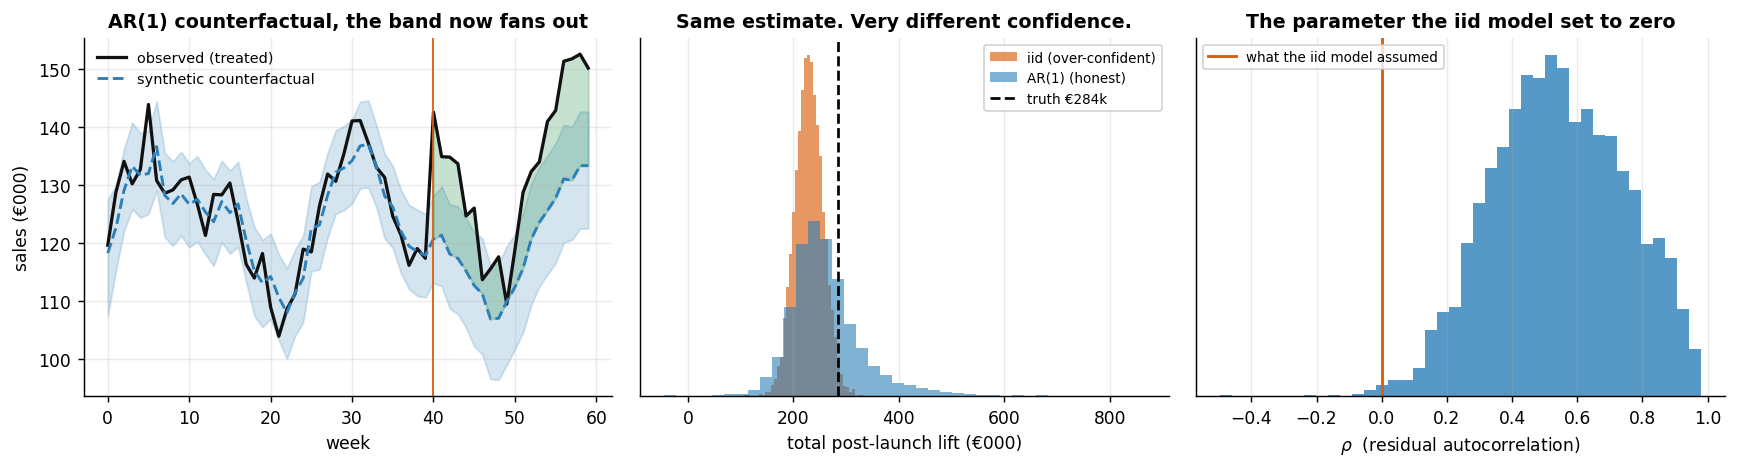

In [8]:
# The same synthetic control, with an AR(1) residual, and the post-period error propagated forward.
# THIS is the shipped model. It gets its own name, sc_ar1, and everything downstream (§5x, §6's euro
# decision, Depth A's bake-off, the final JSON, the book export) references sc_ar1 / *_ar1 BY NAME, 
# nothing is re-bound, so no later cell can silently grade the discarded iid fit (sc_iid) again.
sc_ar1 = load_or_run("07_sc_ar1", lambda: est.synthetic_control_ar1(y_tr, donors, pre, post, seed=1, **SC),
                     inputs=dict(seed=SEED, model="ar1", **SC))
print(f"AR(1) SC convergence: {sc_ar1['convergence']['summary']}")
cf_ar1 = sc_ar1["counterfactual_samples"]; effect_ar1 = sc_ar1["effect_samples"]
total_post_ar1 = effect_ar1[:, post].sum(1)
rho_post = sc_ar1["rho_samples"]

# Weekly-gap and weight summaries of the SHIPPED fit, recomputed from the AR(1) posterior, never
# inherited from §4. (The §5 diagnosis cells above keep the *_iid names on purpose: they are
# diagnosing the iid model. Depth A's bake-off and the book export read the *_ar1 names built here.)
eff_mean_ar1 = effect_ar1.mean(0)
eff_lo_ar1, eff_hi_ar1 = np.quantile(effect_ar1, [0.05, 0.95], 0)
w_mean_ar1 = sc_ar1["weight_samples"].mean(0)
eff_n_ar1 = 1.0 / np.sum(w_mean_ar1 ** 2)             # effective donors of the SHIPPED blend (1/Σw²)

rho_lo, rho_hi = np.quantile(rho_post, [0.05, 0.95])
p_rho = float((rho_post > 0).mean())                  # report with a floor, never print a false "100%"
p_rho_str = ">99.9%" if p_rho > 0.999 else f"{p_rho:.1%}"
print(f"\nrho posterior: {rho_post.mean():.2f}  90% [{rho_lo:.2f}, {rho_hi:.2f}]  "
      f", P(rho > 0) = {p_rho_str}")
print("The data had this persistence all along. The iid model simply refused to look at it.\n")

# §5's pre-fit gate, re-run on the fit we actually ship. The AR(1) blend trades a little in-sample
# pre-period tightness for honest error propagation, so its pre-RMSE is HIGHER than the iid fit's, 
# the gate now fails outright, not narrowly. These are the numbers §6, §7 and the book chapter read.
gate_ref = abs(total_post_ar1.mean() / n_post) / 3    # |weekly lift|/3, from the SHIPPED posterior
gate = "PASS" if sc_ar1["pre_rmse"] < gate_ref else "FAIL"
print(f"pre-fit gate (shipped AR(1) fit): pre-RMSE €{sc_ar1['pre_rmse']:.2f}k  vs  "
      f"|weekly lift|/3 = €{gate_ref:.1f}k  ->  {gate}")
print(f"  (iid fit, for contrast: €{sc_iid['pre_rmse']:.2f}k vs €{gate_ref_iid:.1f}k -> {gate_iid}.  "
      f"Pre-launch gap mean €{eff_mean_ar1[pre].mean():.2f}k; "
      f"weight spread {eff_n_ar1:.1f} effective donors.)\n")

lo_i, hi_i = np.quantile(total_post_iid, [0.05, 0.95])
lo_a, hi_a = np.quantile(total_post_ar1, [0.05, 0.95])
print(f"{'model':<26}{'total lift':>12}{'90% interval':>22}{'width':>9}{'covers truth?':>15}")
for lab, tp, lo, hi in [("iid likelihood (§4)", total_post_iid, lo_i, hi_i),
                        ("AR(1) likelihood (§5z)", total_post_ar1, lo_a, hi_a)]:
    print(f"{lab:<26}{tp.mean():>11.0f}k  [{lo:>7.0f}k, {hi:>7.0f}k]{hi - lo:>8.0f}k"
          f"{('yes' if lo <= true_total <= hi else 'NO'):>15}")
print(f"{'planted truth':<26}{true_total:>11.0f}k")

# The verdict that matters is not this panel, it is coverage across many worlds (§5's multi-seed check).
print(f"\nAcross the {len(ms)} fresh panels, the nominal-90% interval on the TOTAL actually covered "
      f"the truth:\n  iid   {ms.tot_cov_iid.mean():.0%}   <- a 90% interval that is right "
      f"{ms.tot_cov_iid.mean():.0%} of the time is not a 90% interval"
      f"\n  AR(1) {ms.tot_cov_ar1.mean():.0%}   <- this one is.")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.7))
plots.sc_counterfactual_plot(ax[0], t, y_tr, cf_ar1, launch, xlabel="week", ylabel="sales (€000)",
                             title="AR(1) counterfactual, the band now fans out")
ax[1].hist(total_post_iid, bins=40, color=plots.ORANGE, alpha=0.65, density=True, label="iid (over-confident)")
ax[1].hist(total_post_ar1, bins=40, color=plots.BLUE, alpha=0.60, density=True, label="AR(1) (honest)")
ax[1].axvline(true_total, color="black", ls="--", lw=1.5, label=f"truth €{true_total:.0f}k")
ax[1].set_xlabel("total post-launch lift (€000)"); ax[1].set_yticks([])
ax[1].set_title("Same estimate. Very different confidence."); ax[1].legend(fontsize=7.5)
ax[2].hist(rho_post, bins=40, color=plots.BLUE, alpha=0.8, density=True)
ax[2].axvline(0, color=plots.ORANGE, lw=1.6, label="what the iid model assumed")
ax[2].set_xlabel(r"$\rho$  (residual autocorrelation)"); ax[2].set_yticks([])
ax[2].set_title("The parameter the iid model set to zero"); ax[2].legend(fontsize=7.5)
fig.tight_layout()

**Read the three panels left to right.** The counterfactual band now *fans out* as the post-period runs
on, the honest picture of a forecast whose error persists rather than resetting every Monday. The middle
panel is the whole notebook in one image: the two posteriors sit a fraction of a standard deviation apart
on the estimate (**€229k** iid vs **€262k** AR(1), against a design-based sd of €50k) and tell wildly
different stories about how much to trust it, a 90% interval **87k** wide against one **222k** wide, and
only the second one contains the planted **€284k**. The right-hand panel shows the parameter the iid model
had silently pinned to zero, with the data's opinion of it plotted on top: $\rho$ posterior mean **0.54**,
90% interval **[0.21, 0.87]**, $P(\rho > 0) > 99\%$.

**What the fix bought, precisely.** Not accuracy, the point estimate barely moved, because the causal work
was done by §3's identification and the simplex, which both models share. What it bought is a **nominal-90%
interval that is actually right about 90% of the time**, **88%** across the 24 fresh panels, in place of
one that was right **50%** of the time. That is the difference between an interval and a decoration.

**The lesson generalises past this notebook, and it is the one to carry into §6.** When a Bayesian interval
fails, the reflex "Bayes was too confident" is almost always wrong. The prior was not the problem, it never
is, in a well-identified problem with real data. The *likelihood* was the problem: it made a claim about the
error structure that the data flatly contradicted. Bayesian inference is not a machine for being humble; it
is a machine for propagating exactly the assumptions you feed it. Feed it "the weeks are independent" and it
will hand you back a beautifully calibrated posterior *for a world that does not exist*.

Which is also why the classical arm looked so good a moment ago: the placebo/design-based interval never
used a likelihood at all. It got its uncertainty from re-running the estimator on worlds where the truth is
known to be zero. That is a genuinely different, and genuinely valuable, source of authority, and §5x now
puts all three side by side.


### 5x · Point estimate vs posterior, what the Bayesian layer actually bought

Step 0 produced a lift estimate and a placebo interval with no likelihood, no prior and no sampler. §4
produced a posterior that turned out to be over-confident, and §5z produced one that is not. All three
target the *same* estimand, the total post-launch lift, so lay them side by side on it, and then do the
thing that actually settles which **uncertainty** statement to believe: count how often each interval
covers the planted truth across the fresh panels of the multi-seed check. Nothing below is asserted; all
of it is measured.

In [9]:
# --- 5x · Three intervals on ONE estimand: the total post-launch lift -----------------------------
# The classical placebo interval, the iid posterior (§4), and the AR(1) posterior (§5z). Everything is
# computed: the point estimates, the widths, and, the head-to-head that settles it, the COVERAGE of
# each interval on the same fresh panels used in §5.
from scipy.stats import norm

post_lo_i, post_hi_i = np.quantile(total_post_iid, [0.05, 0.95])
post_lo_a, post_hi_a = np.quantile(total_post_ar1, [0.05, 0.95])
post_lo, post_hi = post_lo_a, post_hi_a        # the SHIPPED model; §6 and the book export read these

# Design-based coverage on the SAME panels as §5 (seeds 100+s). SLSQP only, no MCMC.
def _placebo_coverage():
    cov = []
    for s in range(len(ms)):
        sd_, te_, _lz, tl_ = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.12, seed=100 + s)
        sl = sd_.values.T; ti = list(sd_.columns).index(tl_)
        pg_, rg_, _p = est.placebo_in_space(sl, ti, pre, post, pre_rmse=None, rmse_multiple=5.0)
        tot_ = rg_[post].sum(); pl_ = pg_[:, post].sum(1)
        lo_, hi_ = tot_ - np.quantile(pl_, 0.95), tot_ - np.quantile(pl_, 0.05)
        cov.append(bool(lo_ <= float(te_[post].sum()) <= hi_))
    return cov

cov_ri = load_or_run("07_placebo_coverage", _placebo_coverage, inputs=dict(n=len(ms), rmse_multiple=5.0))

rows5x = [
    ("classical SC (SLSQP) · placebo interval", total_cl, ri_lo, ri_hi, float(np.mean(cov_ri))),
    ("Bayesian SC · iid posterior (§4)", float(total_post_iid.mean()), float(post_lo_i), float(post_hi_i),
     float(ms.tot_cov_iid.mean())),
    ("Bayesian SC · AR(1) posterior (§5z)", float(total_post_ar1.mean()), float(post_lo_a), float(post_hi_a),
     float(ms.tot_cov_ar1.mean())),
]
print(f"SAME estimand, total lift over the {n_post} post-launch weeks. Planted truth EUR {true_total:.0f}k.\n")
print(f"{'':<42}{'est':>7}{'5%':>8}{'95%':>8}{'width':>8}{'truth?':>8}{'coverage':>10}")
for lab, e, lo, hi, cov in rows5x:
    print(f"{lab:<42}{e:>7.0f}{lo:>8.0f}{hi:>8.0f}{hi - lo:>8.0f}"
          f"{('yes' if lo <= true_total <= hi else 'NO'):>8}{cov:>9.0%}")

_ests = [total_cl, float(total_post_iid.mean()), float(total_post_ar1.mean())]
print(f"\nLOCATION, all three agree. The point estimates span EUR {max(_ests) - min(_ests):.0f}k, a fraction "
      f"of the design-based sd below. Fixing the likelihood did NOT move the estimate.")

print(f"\nWIDTH, four rival scales for the sd of the {n_post}-week total:")
print(f"  iid posterior sd (§4)                      EUR {total_post_iid.std():>5.0f}k   <- the one that was wrong")
print(f"  AR(1) posterior sd (§5z)                   EUR {total_post_ar1.std():>5.0f}k")
print(f"  placebo / design-based sd (this panel)     EUR {placebo_tot.std():>5.0f}k")
print(f"  ACTUAL seed-to-seed sd of the error (§5)   EUR {ms.err_iid.std():>5.0f}k   <- the referee")
print(f"  -> the iid posterior underprices the referee by ~{ms.err_iid.std() / total_post_iid.std():.1f}x.")

print(f"\nCOVERAGE across {len(ms)} fresh panels, the only test that matters (nominal 90%):")
print(f"  iid posterior (§4)                          {ms.tot_cov_iid.mean():>4.0%}   <- not a 90% interval")
print(f"  AR(1) posterior (§5z)                       {ms.tot_cov_ar1.mean():>4.0%}")
print(f"  classical randomization interval            {np.mean(cov_ri):>4.0%}   <- design-based, never used a likelihood")

# The decision quantity: the campaign pays iff PROFIT = MARGIN*lift beats cost (§6 margin trap).
profit_post = MARGIN * total_post_ar1
p_go_iid = float((MARGIN * total_post_iid > CAMPAIGN_COST).mean())
p_go_post = float((profit_post > CAMPAIGN_COST).mean())
widened = norm.rvs(loc=profit_post.mean(), scale=MARGIN * placebo_tot.std(), size=40_000, random_state=7)
dec_post = policy.go_no_go(profit_post, CAMPAIGN_COST)
dec_wide = policy.go_no_go(widened, CAMPAIGN_COST)   # same centre, the design-based scale
print(f"\nP(profit > EUR {CAMPAIGN_COST:.0f}k cost) at {MARGIN:.0%} margin, the number §6 signs off on:")
print(f"  classical                                   not defined")
print(f"  Bayesian posterior, iid (§4)                {p_go_iid:>11.2f}")
print(f"  Bayesian posterior, AR(1) (§5z)             {p_go_post:>11.2f}  -> {dec_post['decision']}")
print(f"  same AR(1) posterior, re-scaled to the design sd {dec_wide['P_value_gt_cost']:>7.2f}  -> {dec_wide['decision']}")
print(f"  ('not defined' is no dodge: a p-value ranks data against a null; it attaches")
print(f"   no probability to a hypothesis about the effect.)")
# Adjudicate the label from the computed decisions, and say only what the branch earns (cf. 07b's
# filter-branch print): the trailing sentence must fit BOTH worlds, not the one we hoped for.
if dec_post['decision'] == dec_wide['decision']:
    print(f"  -> the AR(1) call HOLDS under the design-based scale. The likelihood and the design agree on how")
    print(f"     confident we are entitled to be, which is exactly what §5z bought.")
else:
    print(f"  -> the AR(1) LABEL flips ({dec_post['decision']} -> {dec_wide['decision']}) under the design-based scale:")
    print(f"     on a break-even campaign P sits near the 0.5 line ({p_go_post:.2f} vs {dec_wide['P_value_gt_cost']:.2f}), so an honest re-pricing of the")
    print(f"     sd can nudge the label across a threshold. The ACTION does not move, neither number licenses")
    print(f"     a rollout at this price, and an interval honest enough to show that sensitivity is what §5z bought.")

[cache] loaded '07_placebo_coverage' (12s fit, cached 67.1h ago) — nothing re-sampled.
SAME estimand, total lift over the 20 post-launch weeks. Planted truth EUR 284k.

                                              est      5%     95%   width  truth?  coverage
classical SC (SLSQP) · placebo interval       260     195     335     140     yes      83%
Bayesian SC · iid posterior (§4)              229     186     273      87      NO      50%
Bayesian SC · AR(1) posterior (§5z)           262     172     394     222     yes      88%

LOCATION, all three agree. The point estimates span EUR 33k, a fraction of the design-based sd below. Fixing the likelihood did NOT move the estimate.

WIDTH, four rival scales for the sd of the 20-week total:
  iid posterior sd (§4)                      EUR    27k   <- the one that was wrong
  AR(1) posterior sd (§5z)                   EUR    72k
  placebo / design-based sd (this panel)     EUR    50k
  ACTUAL seed-to-seed sd of the error (§5)   EUR    59k   <

**1 · On the number itself, all three agree, and none is a hero.** The classical SLSQP fit (**€260k**),
the iid posterior (**€229k**) and the AR(1) posterior (**€262k**) span just **€33k**, a third of the
design-based sd, and they *all* undershoot the planted **€284k**, by 8%, 19% and 8% respectively. That is
not a defect of any one apparatus: the causal work was done by §3's identification and by the simplex, which
all three share, and the undershoot is a property of *synthetic control* itself (§7 keeps it as a caveat).
The Bayesian layer bought **no better a point estimate**. It could not have. Fixing the likelihood did not
move the estimate either, which is exactly the point.

**2 · On the uncertainty, they disagree, and the fix, not the paradigm, is what settles it.** This is the
notebook's real finding, and it is measured rather than argued. Read the coverage column. A nominal-90%
interval that covers the truth on only **half** of fresh worlds is not a 90% interval; the iid posterior was
in that state (**50%**, on an interval only **€87k** wide), and the placebo interval, which never used a
likelihood at all, was the only honest statement on the table (**83%**). That was a genuinely uncomfortable
place to be, and for one section it was the truth. Then §5z put the autocorrelation *into the likelihood*,
and the posterior's interval went back to meaning what it says: **88%**, in the same range as the design-based
one (**83%** on 24 panels, indistinguishable at this Monte-Carlo resolution). Look at the four rival scales for the sd of the 20-week total and you can see the whole argument in one
column: the iid posterior says **€27k**, the AR(1) posterior **€72k**, the design-based placebos **€50k**,
and the referee, the *actual* seed-to-seed sd of the error, says **€59k**. The iid model underpriced the
referee by ~**2.2×**; the AR(1) model is, if anything, a touch conservative.

So the correct conclusion is **not** "the classical arm wins", and it is emphatically not "Bayes is
over-confident". It is sharper and more useful than either:

> When a Bayesian interval under-covers, suspect the **likelihood**, not the paradigm and not the prior.
> The prior did nothing here, swap it and nothing moves. The likelihood did everything, because it is the
> only place where a claim about the *error structure* gets made, and that claim is what a cumulative total
> is made of.

**3 · Why the classical arm was still right to be trusted.** It got its uncertainty from *re-running the
estimator on worlds where the truth is known to be zero*, the placebo distribution, rather than from a
parametric story about the errors. That is design-based inference, and its power is precisely that it is
**agnostic** about the error structure it never had to model. It cannot be wrong about autocorrelation
because it never made a claim about autocorrelation. Keep it. Not as a rival to the posterior, but as the
**referee** that tells you whether your likelihood is lying to you, which, this time, it was.

**4 · What each one is *for*, which is the thing to walk out with.** The posterior is what the euro decision
in §6 consumes, because $P(\text{profit} > \text{cost})$ is a statement only a posterior can make and every
budget meeting demands one, and the cell above shows what an honest change of scale does to the call: re-price the AR(1) posterior at the
design-based sd and $P$ moves 0.78 → 0.83, and the TEST FURTHER label **holds** under every honest scale on
the table. That robustness is a property of the case, not of the method: on a campaign priced at its
break-even the same exercise flips labels, so it must be checked, never assumed. The design-based interval is what tells you whether to *believe* that posterior. Use the
posterior for the decision, and design-based inference for your confidence in it.


## 6 · Decide, in euros

The campaign cost **€75k**. Everything the notebook has produced so far now collapses into a
single object: the **posterior over total incremental sales** across the 20 post-launch weeks
(`total_post`, in €000), converted into **profit**. Revenue is not profit: the firm keeps a
**35% gross margin** on incremental sales, so the campaign pays iff
$0.35 \times \text{lift} > \text{cost}$, equivalently lift > cost/margin ≈ **€214k**, a bar the
~€262k posterior mean clears with ~€48k of revenue to spare. The rollout question is *not* "is the lift positive?",
Depth B's placebo permutation answers that, but **"what is the probability the profit beats what
we paid?"**, because a real-but-too-small effect still loses money at national scale.

**The decision rule** (`policy.go_no_go`, the cookbook's standard): read
$P(\text{profit} > \text{cost})$ off the posterior and act on a stated convention, 

- $P > 0.9$ → **GO**, sure enough to act without buying more evidence;
- $P < 0.5$ → **NO-GO**, more likely than not the campaign doesn't pay at this price;
- in between → **TEST FURTHER**, the honest middle where the effect may well be real but the
  *economics* are not yet settled.

Alongside the probability it reports the expected **net value** ($\mathbb E[\text{profit}] -
\text{cost}$, in €000) and the expected **ROI** as a ratio (net ÷ cost, so break-even is 0), 
three views of the same posterior, so nobody has to reverse-engineer the call from a chart.

**How to read the two panels.** *Left*: the posterior of total profit (35% of the lift) with the
€75k cost line, the mass to the right of the line **is** $P(\text{profit} > \text{cost})$ (the
dashed marker is 35% of the true total, which we only know because this is a simulation). *Right*:
the same posterior read as a **headroom curve**, sweep a hypothetical cost $c$ and plot
$P(\text{profit} > c)$. Where the curve crosses the green 0.9 line is the *highest price at which
this evidence would already justify a confident GO*, the number to bring to the media-buying
negotiation, not just a yes/no.

{
  "P_value_gt_cost": 0.78,
  "expected_value": 91.67,
  "expected_net_value": 16.67,
  "expected_roi": 0.22,
  "value_lo": 60.16,
  "value_hi": 137.84,
  "cost": 75.0,
  "decision": "TEST FURTHER"
}
headroom, a confident GO only up to €67k; we paid €75k, 11% above it, so short of a confident GO.

cost sweep (35% margin): expected net profit and P(profit>cost) vs campaign cost
  cost EUR  45k   E[net] EUR   +47k   P(paid) 0.99   GO
  cost EUR  50k   E[net] EUR   +42k   P(paid) 0.98   GO
  cost EUR  55k   E[net] EUR   +37k   P(paid) 0.97   GO
  cost EUR  57k   E[net] EUR   +35k   P(paid) 0.96   GO
  cost EUR  60k   E[net] EUR   +32k   P(paid) 0.95   GO
  cost EUR  62k   E[net] EUR   +30k   P(paid) 0.94   GO
  cost EUR  65k   E[net] EUR   +27k   P(paid) 0.92   GO
  cost EUR  68k   E[net] EUR   +24k   P(paid) 0.89   TEST FURTHER
  cost EUR  72k   E[net] EUR   +20k   P(paid) 0.83   TEST FURTHER
  cost EUR  80k   E[net] EUR   +12k   P(paid) 0.68   TEST FURTHER
  cost EUR  90k   E[net] EUR 

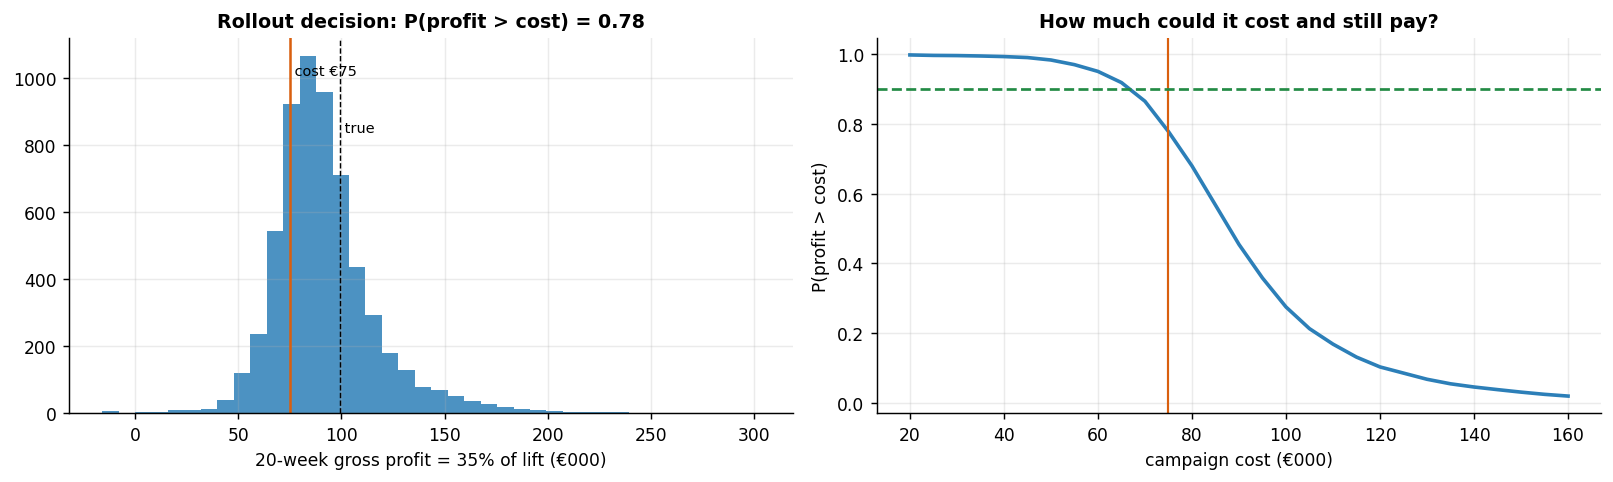

In [10]:
# The euro decision is on PROFIT = MARGIN*lift vs cost. Revenue is not profit (cf. §9.11).
profit_post = MARGIN * total_post_ar1
decision = policy.go_no_go(profit_post, CAMPAIGN_COST)
cost_grid = np.linspace(20, 160, 29)
p_beats = [(profit_post > c).mean() for c in cost_grid]
# Headroom: the highest price at which THIS evidence is already a confident GO. P(profit>c)=0.9 at
# c = MARGIN*(10th percentile of the lift). Never eyeballed off the chart.
headroom = float(MARGIN * np.quantile(total_post_ar1, 0.10))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
plots.decision_hist(ax[0], profit_post, CAMPAIGN_COST, true_total=MARGIN * true_total,
                    title=f"Rollout decision: P(profit > cost) = {(profit_post > CAMPAIGN_COST).mean():.2f}")
ax[0].set_xlabel("20-week gross profit = 35% of lift (€000)")
ax[1].plot(cost_grid, p_beats, color=plots.BLUE, lw=2)
ax[1].axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.2); ax[1].axhline(0.9, color=plots.GREEN, ls="--")
ax[1].set_xlabel("campaign cost (€000)"); ax[1].set_ylabel("P(profit > cost)"); ax[1].set_title("How much could it cost and still pay?")
fig.tight_layout()
def _round(x, nd=2):
    if isinstance(x, float): return round(x, nd)
    if isinstance(x, dict): return {k: _round(v, nd) for k, v in x.items()}
    if isinstance(x, list): return [_round(v, nd) for v in x]
    return x
print(json.dumps(_round(decision), indent=2))
if headroom >= CAMPAIGN_COST:
    print(f"headroom, a confident GO at any price up to €{headroom:.0f}k; we paid €{CAMPAIGN_COST:.0f}k, "
          f"{(headroom - CAMPAIGN_COST) / CAMPAIGN_COST:.0%} below that ceiling.")
else:
    print(f"headroom, a confident GO only up to €{headroom:.0f}k; we paid €{CAMPAIGN_COST:.0f}k, "
          f"{(CAMPAIGN_COST - headroom) / CAMPAIGN_COST:.0%} above it, so short of a confident GO.")

# Cost/profit sweep: the decision at a glance. Expected NET profit and P(campaign paid) vs price.
print("\ncost sweep (35% margin): expected net profit and P(profit>cost) vs campaign cost")
for c in [45, 50, 55, 57, 60, 62, 65, 68, 72, 80, 90]:
    net_c = MARGIN * total_post_ar1.mean() - c
    p_c = float((MARGIN * total_post_ar1 > c).mean())
    verdict_c = "GO" if p_c > 0.9 else ("NO-GO" if p_c < 0.5 else "TEST FURTHER")
    print(f"  cost EUR {c:3d}k   E[net] EUR {net_c:+5.0f}k   P(paid) {p_c:.2f}   {verdict_c}")

**Read-out.** The verdict in this run is **TEST FURTHER**, and the JSON says why: the expected lift
(≈ **€262k** of revenue) is worth ≈ **€91.7k** of profit at the 35% margin, against the **€75k** cost,
expected net ≈ **+€16.7k**, ROI ≈ **+22%**. The *mean* clears the bar comfortably, and yet
$P(\text{profit} > \text{cost}) = \mathbf{0.78}$: roughly one world in five still ends with the campaign
losing money, because the posterior is wide (≈ €25k of sd on profit) and right-skewed, a long upper tail
doing part of the mean's work. Under the cookbook's convention $0.5 \le P < 0.9$ is TEST FURTHER: the
campaign *probably* paid, and "probably" is not the standard a €4M rollout should be held to. Hold this
against Depth B without flinching at the apparent tension: the placebo permutation says the effect is
**real** (p ≈ 0.03), the economics say it *probably but not confidently* cleared its price, and the
distance between those two statements is exactly what the 0.9 bar prices. The headroom curve puts a number
on the shortfall: the 0.9 bar is cleared only at prices up to **€67k**, **11% below** the €75k we paid. Had
the campaign cost €67k, this same evidence would already be a confident GO. At €75k, the evidence buys
conviction that the campaign *worked*, and four-chances-in-five near-conviction that it *paid*.

And read that 0.78 with §5x's verdict in hand. It comes from the **AR(1)** posterior, whose interval on the
total covers 88% of fresh panels, so its width is *earned*, neither padded nor optimistic. §5x stress-tests
it by re-scaling the same posterior to the design-based sd: $P$ moves 0.78 → **0.83** and the label
**holds**, this call, unlike a break-even one, is not width-fragile. Note also what the old, broken model
prints here: the iid posterior says $P = 0.72$, nearly the same number. That agreement is a *coincidence of
where the bar falls*, the €214k break-even sits left of both posteriors' bulk, so both put most of their
mass above it. Push the price toward the break-even region of the cost sweep and the two models diverge
sharply, because there the answer is decided by the *width*, which is exactly what they disagree about.
"The number looks reasonable" can never certify a model; coverage, which the iid likelihood fails at 50%,
is what tells you which of two agreeing numbers you were entitled to. Repairing the likelihood did not
change this run's label; it made the 0.78 a number we are *entitled* to sign.

**A TEST FURTHER has a price tag: the value of information.** TEST FURTHER is a verdict about *this
campaign at this price*, not a full stop, and it must not end as a shrug either. The deliverable is still an answer to
*"what evidence would settle this, and is it worth buying?"* Two tools, both computed below:

- **VOI (value of information).**
  $\text{VOI} = \mathbb E\big[\max(V - c,\, 0)\big] - \max\big(\mathbb E[V] - c,\, 0\big)$, the
  expected gain from deciding *after* the uncertainty resolves versus committing now on the mean.
  Intuition: committing now earns the expected net, here +€16.7k, and eats the loss in the one-in-five
  worlds where the profit lands below the cost; perfect foresight would take the campaign only in the
  worlds where it pays and skip the rest. VOI is that avoided downside (plus kept upside), averaged
  over the posterior. It is the most a *perfectly informative* test could add in expected decision
  value, i.e. an **upper bound on any confirmatory-test budget**.
- **Test sizing.** A second geo test treating $k$ independent markets tightens the posterior
  roughly as $1/\sqrt{k}$, it **sharpens** the estimate around the same mean; it doesn't move it.
  So "how big must the test be?" becomes: *the smallest $k$ whose tightened posterior reaches*
  $P(\text{profit} > \text{cost}) \ge 0.9$. The pace is set entirely by the *victory margin*: reaching
  0.9 needs the margin (expected profit minus cost, €91.7k − €75k ≈ €16.7k here) to span 1.28
  tightened-sd's of the ≈ €25k profit sd, a factor-2 shrink, so $k \approx 4$. Had the margin been the
  ~€2k a €90k price would leave, the same arithmetic demands hundreds of markets: sizing arithmetic can
  sharpen a verdict at the pace the margin allows, and no faster. And two
  hidden assumptions live inside the $1/\sqrt{k}$ anyway, both flattering the test: it treats the
  $k$ market-level estimates as **independent** with equal variance, but this whole world is built on
  *shared* macro factors, so the $k$ gap estimates share estimation error and the *effective* $k$ is
  smaller than the nominal one, and it assumes a second test would land on the same mean. So read any
  computed $k$ as a **lower bound**, and read a *missing* $k$ as the harder truth it is.

Value of information: resolving the cost-line uncertainty is worth ~€2k of expected decision value.
A confirmatory geo test averaging ~4 independent treated markets would tighten the interval
enough to reach P(lift>cost) >= 0.90, and since the multi-seed check showed this interval is
*optimistic*, treat 4 as a LOWER bound on the test size. That is the experiment to run, not a blind launch.


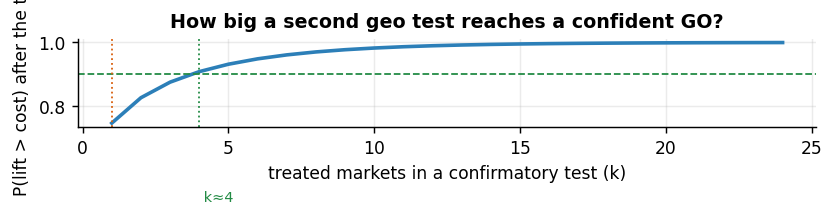

In [11]:
# Value of information & test-sizing: the decision is borderline, so what is a confirmatory geo test
# worth, and how big must it be? VOI = E[max(profit-cost,0)] - max(E[profit]-cost,0) is the expected value
# of resolving the "does it clear cost?" uncertainty before committing.
from scipy.stats import norm
profit_post = MARGIN * total_post_ar1                      # euros of profit, not revenue
voi = float(np.maximum(profit_post - CAMPAIGN_COST, 0).mean() - max(profit_post.mean() - CAMPAIGN_COST, 0))
mu, sdev = profit_post.mean(), profit_post.std()
# A second test averaging k independent treated markets tightens the estimate ~1/sqrt(k) (it sharpens,
# doesn't move it). Find the smallest k reaching a confident GO, P(lift>cost) >= 0.9.
def p_go(k): return float(1 - norm.cdf(CAMPAIGN_COST, loc=mu, scale=sdev / np.sqrt(k)))
k_needed = next((k for k in range(1, 60) if p_go(k) >= 0.9), None)
n_mkts = sales.shape[0]                       # how many markets this world even contains
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ks = np.arange(1, 25); ax.plot(ks, [p_go(k) for k in ks], color=plots.BLUE, lw=2)
ax.axhline(0.9, color=plots.GREEN, ls="--", lw=1); ax.axvline(1, color=plots.ORANGE, ls=":", lw=1)
if k_needed: ax.axvline(k_needed, color=plots.GREEN, ls=":", lw=1); ax.text(k_needed, 0.5, f" k≈{k_needed}", fontsize=8, color=plots.GREEN)
ax.set_xlabel("treated markets in a confirmatory test (k)"); ax.set_ylabel("P(lift > cost) after the test")
ax.set_title("How big a second geo test reaches a confident GO?"); fig.tight_layout()
print(f"Value of information: resolving the cost-line uncertainty is worth ~€{voi:.0f}k of expected decision value.")
if k_needed and k_needed <= n_mkts - 1:
    print(f"A confirmatory geo test averaging ~{k_needed} independent treated markets would tighten the interval\n"
          f"enough to reach P(lift>cost) >= 0.90, and since the multi-seed check showed this interval is\n"
          f"*optimistic*, treat {k_needed} as a LOWER bound on the test size. That is the experiment to run, not a blind launch.")
elif k_needed:
    print(f"Reaching P(lift>cost) >= 0.90 would take ~{k_needed} independent treated markets, more than this\n"
          f"world contains ({n_mkts} DMAs, one already treated). The honest read: NO feasible single confirmatory\n"
          f"test gets to 0.90 here; extend the post-period, pool repeated tests, or accept a lower confidence bar, \n"
          f"and the multi-seed check says even this arithmetic is optimistic. Still an experiment, never a blind launch.")
else:
    print("Even a large confirmatory test would not reach 0.90 at this point estimate, the effect sits too close to cost.")

**Read-out, sizing the confirmatory test.** VOI ≈ **€2k** in this run, and the mechanism is worth spelling
out. The posterior mean sits *comfortably above* the cost line (expected profit €91.7k vs €75k), so
committing now already banks **+€16.7k** in expectation; all that perfect information adds is the option to
*dodge* the €75k in the one-in-five worlds where profit lands below it, and that option is worth about
**€2k** of expected decision value. That number disciplines the next step brutally: for *this* decision,
buy this campaign again at €75k, no confirmatory test costing more than ~€2k is rational, and no real geo
test costs less.

The sizing arithmetic, read off the cell above, now *does* return a number: **k ≈ 4** independent treated
markets reaches the 0.9 bar, because the ≈ €16.7k victory margin spans 1.28 tightened-sd's after only a
factor-2 shrink of the ≈ €25k profit sd. Treat the 4 as a **lower bound**: the shared-factor world makes
the *effective* $k$ smaller than the nominal one, and the multi-seed check says this panel's interval is
optimistic. So the test is *feasible*, and the VOI says it is *not worth funding*, and both are true
because they price information for **different decisions**. The €2k is what resolving uncertainty is worth
for the €75k media buy; a 4-market test is bought to de-risk the **€4M national rollout**, whose stakes,
not this campaign's, are what pay for it. Keep the two ledgers separate and both sentences fit in one memo:
*do not fund a test to re-litigate this buy; do run one before rolling out.*

Which leaves the honest moves. **Renegotiate the price**: at the **€67k** headroom §6 printed, this same
evidence *already* clears the 0.9 bar, so the question for the media negotiation is not "did the campaign
work?" but "will you sell it at €67k?", an 11% concession. **Run the ~4-market confirmatory test** if the
rollout is live: fresh markets carry new information about the *level*, so it moves the estimate as well as
sharpening it. Or **accept the 0.78 explicitly**: a board may rationally take a four-in-five bet with
+€16.7k of expected net, provided it is booked as a bet and not as a certainty. What is *not* on the list:
a blind national rollout on one metro's evidence. Depth C pulls this together, with the launch-date and
donor-pool sensitivities, into the one-paragraph verdict a VP signs.

## 7 · Caveats

- **Here synthetic control is high-variance, not conservative.** In this panel the shipped AR(1) estimate
  lands ~8% low (**€262k** against the planted **€284k**); across 24 fresh panels (§5) the mean bias is small
  and *positive* (**+€23k, +7%** of the truth) while the sample-to-sample spread is **large** (sd **€59k**).
  Variance, not bias, is the enemy, and pricing that variance is exactly the job the likelihood has to get
  right. §4's iid likelihood does not: its nominal-90% interval on the total covers **50%** of the time. §5z's
  AR(1) likelihood does: **88%**, in the same range as the design-based placebo interval (**83%** on 24 panels, indistinguishable at this Monte-Carlo resolution). So the band you
  quote must be the AR(1) one, and the **placebo permutation test** (Step 0's classical inference) stays on
  as the referee that would catch the next mis-specified likelihood, §5x measures all three on the same
  panels rather than asserting anything.
- **The AR(1) fix is itself a model.** It earns calibrated coverage *here* because the true error is a
  persistent, random-walk-driven offset that AR(1) approximates well ($\rho$ posterior mean 0.54). A
  different error structure would need a different likelihood. The transferable lesson is **check the
  coverage**, not "always use AR(1)".
- **Pre-fit is a gate, not a formality.** High pre-RMSE ⇒ the post gap is uninterpretable; no
  Bayesian machinery fixes a bad donor pool. In this panel the gate *fails* on the shipped fit, §5z's gate
  line prints pre-RMSE €5.06k against a €4.4k bar, so the design sits at the edge of its resolution, which
  is part of why §6 stops short of a confident GO.
- **No-anticipation and no-spillover are assumptions.** Anticipation is stress-tested by
  placebo-in-time in Depth B; spillover is *invisible to every placebo*, so Depth B stress-tests it
  by simulation instead, planted spillover **attenuates** the estimate (SC under-states, never
  inflates), and the fix is donor-pool design, not statistics. Note the asymmetry it creates: attenuation
  is conservative for a GO call, but it can push a campaign that genuinely paid below the bar.
- **One treated unit = limited power.** Significance comes from the permutation test, coarse
  with few donors.


, 
# Depth A · Why the naive estimators fail

Two tempting shortcuts, both confounded by the shared trend/season/macro wave:

- **Before/after**: post mean − pre mean of the treated DMA, books whatever the shared factors did
  between the two windows as "effect". Which way it errs is not fixed: it depends on where the macro wave
  happened to wander. In *this* panel it wanders against the campaign, so before/after comes in *low*.
- **Treated − average control**: the average control has the wrong factor loadings, so it
  doesn't cancel the common wave cleanly, and taken as a raw level difference it doesn't even cancel the
  markets' different baselines.

Synthetic control is the fix: a *weighted* control chosen to match pre-launch.



{
  "true": 14.2,
  "before/after": 7.2,
  "treated - avg ctrl": 19.3,
  "DiD vs avg ctrl": 10.3,
  "synthetic control": 13.1
}


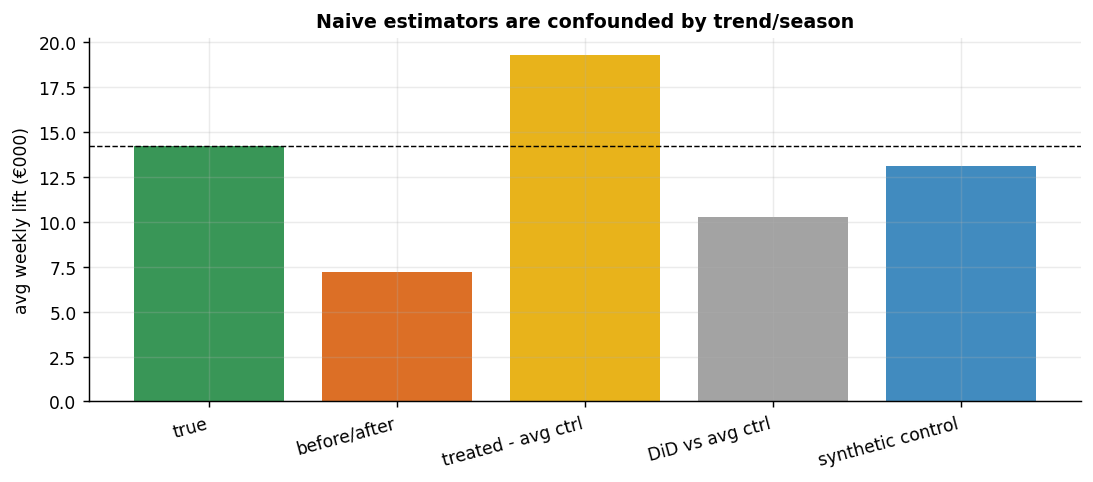

In [12]:
naive_prepost = y_tr[post].mean() - y_tr[pre].mean()
naive_avgctrl = (y_tr[post] - donors[:, post].mean(0)).mean()
# Difference-in-differences vs the average control: subtracts the shared pre-period level too, so it
# removes the trend the level-difference leaves in, isolating the *factor-loading* mismatch that only
# a reweighted synthetic can fix.
naive_did = ((y_tr[post] - donors[:, post].mean(0)).mean()
             - (y_tr[pre] - donors[:, pre].mean(0)).mean())
sc_avg = eff_mean_ar1[post].mean()   # the SHIPPED AR(1) fit, graded by name, not by execution order
bake = {"true": true_avg, "before/after": float(naive_prepost),
        "treated - avg ctrl": float(naive_avgctrl), "DiD vs avg ctrl": float(naive_did),
        "synthetic control": float(sc_avg)}
fig, ax = plt.subplots(figsize=(8.5, 3.8))
cols = [plots.GREEN, plots.ORANGE, plots.GOLD, plots.GREY, plots.BLUE]
ax.bar(list(bake.keys()), list(bake.values()), color=cols, alpha=0.9); ax.axhline(true_avg, color="k", ls="--", lw=0.8)
ax.set_ylabel("avg weekly lift (€000)"); ax.set_title("Naive estimators are confounded by trend/season")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right"); fig.tight_layout()
print(json.dumps({k: round(v,1) for k,v in bake.items()}, indent=2))

**Read-out.** Against a true **€14.2k/week**: **before/after** lands at **€7.2k**, it books the shared
factors' movement between the two windows, and in this panel that movement ran *against* the campaign, so
the naive number comes in at half the truth. (A useful corrective to the folk version of this bias: the
trend bias has no fixed sign, it simply has nothing to do with the campaign.) **Treated − average control**
lands at **€19.3k**, it differences *nothing* out, so it carries the raw between-market level gap and
overstates by a third. **DiD vs the average control** (**€10.3k**) removes the shared trend and the level
gap and does much better, but the average control still has the wrong factor loadings, so a residual bias
survives. **The reweighted synthetic control wins outright** at **€13.1k**, within **€1.1k** of the truth,
and the only estimator on the chart that is not off by several times that. The ranking by absolute error is
unambiguous: SC (€1.1k off) ≪ DiD (€3.9k) < treated − avg (€5.1k) < before/after (€7.0k). (The SC bar is the
model we actually ship, §5z's AR(1) fit, not the discarded iid one.) Same data, four estimates, the
estimator *is* the identification strategy.



, 
# Depth B · Placebo inference, is the gap statistically real?

Step 0 already ran this test and printed its p-value; it is the classical arm's *entire* inferential
apparatus, so it deserves the box opened. Recall the question, which is a **permutation** question rather
than a standard-error one (with one treated market there is no standard error to have):

> *If the campaign had no effect, how unusual would a post-launch gap this big be, just by chance?*

**Placebo-in-space**, drawn out. Pretending in turn that *each donor market* was the treated one gives a
whole family of gap paths, none of them from a market that actually ran a campaign, and the left panel
plots them all: the grey spaghetti is the null, the coloured line is our metro. The right panel is the same
comparison on Abadie's scale-free statistic (post/pre RMSE ratio; Step 0 defines both refinements, the
pre-fit filter and the ratio, and why each is needed). Two things worth checking that a single p-value
hides, and that this cell prints:

- **How many donors survived the pre-fit filter** (here **all 29 of 29**), and therefore how coarse the
  reference distribution is. With ~30 markets the p-value is *granular*: it cannot resolve below roughly
  1/30 no matter how strong the effect is. One treated unit buys limited power, and no amount of Bayesian
  machinery would buy more.
- **Whether the verdict depends on the filter cutoff** (2×, 5×, 20× the treated unit's pre-RMSE). Read the
  printed sweep: on this panel it does **not** move, p = 0.033 at every cutoff, because the filter never
  fires, even the worst-matched donor's synthetic fits well enough to stay in at 2×, so there is nothing
  for a looser cutoff to readmit. That is the strongest form of robustness a knob can have: the verdict is
  insensitive because the knob is *non-binding*, not because a favourable setting rescued it. Keep the
  failure mode in mind for panels where the filter *does* bind: loosening it readmits donors whose own
  synthetic cannot track them at all, broken fits with huge gaps in *both* directions, and those dilute
  the reference distribution until a real effect stops looking unusual. That would not be a fragile
  result; it would be a **mis-specified test**, and it is the reason the filter is part of the method
  rather than a knob to tune.

placebo-in-space kept 29/29 donors (dropped 0: pre-RMSE > 5x the treated fit)
placebo p vs filter cutoff: 2x -> p=0.033  ·  5x -> p=0.033  ·  20x -> p=0.033
    (the sweep does not move: the filter never fires on this panel, every donor fits well enough to
     stay in even at 2x, so no cutoff has anything to discard or readmit. The verdict is robust
     because the knob is NON-BINDING, not because a favourable cutoff rescued it.)
placebo p (gap) = 0.033 [add-one permutation, treated excluded from placebos]  ·  RMSE-ratio p = 0.033 [Abadie rank/N, treated included]  (treated ratio 4.3 vs placebo median 1.4; the treated market ranks 1/30 on the RMSE ratio. The two bookkeepings agree
    exactly here: the treated market is the most extreme on BOTH statistics, so each test reads
    '1 in 30'.)
largest opposite-direction excursion among the surviving placebos: avg post gap €-4.4k, i.e. |gap| €4.4k against the treated market's +€13.0k: no placebo outruns the treated market in either direc

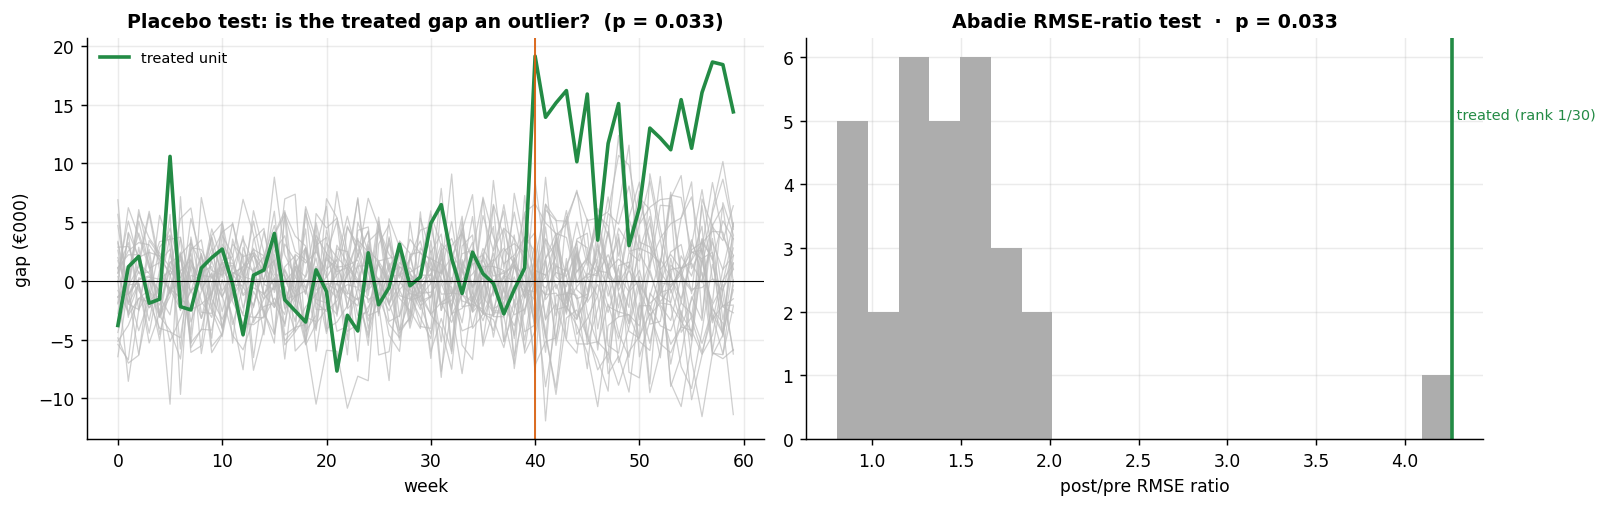

In [13]:
# placebo_gaps / real_gap / p_space / ratios / treated_ratio / p_ratio all come from Step 0, the same
# refits, computed once. Here we PLOT them, and stress-test the one arbitrary knob: the pre-fit filter.
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
plots.placebo_spaghetti(ax[0], t, placebo_gaps, real_gap, launch, p_space, xlabel="week", ylabel="gap (€000)")
ax[1].hist(ratios, bins=20, color=plots.GREY, alpha=0.8); ax[1].axvline(treated_ratio, color=plots.GREEN, lw=2)
ax[1].text(treated_ratio, ax[1].get_ylim()[1]*0.8, f" treated (rank {rank}/{len(ratios)})", fontsize=8, color=plots.GREEN)
ax[1].set_xlabel("post/pre RMSE ratio"); ax[1].set_title(f"Abadie RMSE-ratio test  ·  p = {p_ratio:.3f}")
fig.tight_layout()
n_kept = len(placebo_gaps); n_donors = sales.shape[0] - 1
worst_dn = float(placebo_gaps[:, post].mean(1).min())    # largest opposite-direction placebo excursion
# Is the verdict sensitive to the (somewhat arbitrary) RMSE filter cutoff?
sens = {m: est.placebo_in_space(sales, treated_idx, pre, post, pre_rmse=None, rmse_multiple=m)[2] for m in (2.0, 5.0, 20.0)}
print(f"placebo-in-space kept {n_kept}/{n_donors} donors (dropped {n_donors - n_kept}: pre-RMSE > 5x the treated fit)")
_sweep = "  ·  ".join(f"{m:g}x -> p={p:.3f}" for m, p in sens.items())
# Adjudicate from the computed sweep, never from a hoped-for storyline (cf. 07b's filter branch).
if len({round(p, 3) for p in sens.values()}) == 1:
    print(f"placebo p vs filter cutoff: {_sweep}")
    print("    (the sweep does not move: the filter never fires on this panel, every donor fits well enough to")
    print("     stay in even at 2x, so no cutoff has anything to discard or readmit. The verdict is robust")
    print("     because the knob is NON-BINDING, not because a favourable cutoff rescued it.)")
else:
    print(f"placebo p vs filter cutoff: {_sweep}")
    print("    (the sweep moves: tighter filters compare only well-matched placebos and sharpen the test; a")
    print("     loose 20x filter admits broken synthetics, gaps huge in both directions, and dilutes it.)")
_head = (f"placebo p (gap) = {p_space:.3f} [add-one permutation, treated excluded from placebos]  ·  "
         f"RMSE-ratio p = {p_ratio:.3f} [Abadie rank/N, treated included]  "
         f"(treated ratio {treated_ratio:.1f} vs placebo median {np.median(ratios):.1f}; "
         f"the treated market ranks {rank}/{len(ratios)} on the RMSE ratio.")
if round(p_space, 3) == round(p_ratio, 3):
    print(_head + " The two bookkeepings agree")
    print(f"    exactly here: the treated market is the most extreme on BOTH statistics, so each test reads")
    print(f"    '1 in {len(ratios)}'.)")
else:
    print(_head + " The two p-values differ because the")
    print("    gap test is TWO-SIDED on the raw euro gap while the ratio test ranks post/pre fit, and the two")
    print("    statistics order the placebos differently.)")
_worst_line = (f"largest opposite-direction excursion among the surviving placebos: avg post gap €{worst_dn:.1f}k, "
               f"i.e. |gap| €{abs(worst_dn):.1f}k against the treated market's +€{real_gap[post].mean():.1f}k")
if abs(worst_dn) >= real_gap[post].mean():
    print(_worst_line + ", and the two-sided |.| statistic counts it against the treated rank.")
else:
    print(_worst_line + ": no placebo outruns the treated market in either direction, so the two-sided")
    print("    |.| statistic changes nothing here (on a panel where one did, the raw-gap p would rise while the")
    print("    scale-free ratio p stood, which is why the ratio leads).")

**Two p-values, one verdict.** The cell prints two significance numbers and they land identically,
**0.033** (raw gap) and **0.033** (RMSE ratio), which is worth a beat, because they use different
bookkeeping *and* a different statistic, and nothing forces them to agree. The **raw-gap permutation** p is
a two-sided *add-one* permutation: the treated market counts as one draw of its own null and is *excluded*
from the 29 surviving reference placebos, and what is ranked is the **absolute** mean post-launch gap.
**Abadie's RMSE-ratio** p is a rank statistic that keeps the treated market *in* the denominator and
divides its post-period fit by its pre-period fit. On this panel the treated market is the most extreme on
**both**: its **+€13.0k/week** gap beats every placebo in absolute value (the largest excursion in the
*other* direction, printed above, is a placebo at |gap| ≈ **€4.4k**, a third of the treated gap), giving
(0+1)/(29+1) = 0.033, and its post/pre ratio of **4.3** against a placebo median of **1.4** ranks 1st of
30, giving 1/30 = 0.033. When the treated unit tops both rankings, the two bookkeepings collapse to the
same "1 in 30" and the agreement is exact. They *can* differ, and knowing when is the teaching point: the
gap test is two-sided on the raw euro gap, so a single placebo posting a large opposite-signed excursion
(or simply a badly-fitting donor whose gap is big in *both* periods) can push the raw-gap p up without
touching the ratio p, which is scale-free and refuses to reward a placebo that merely fits badly
everywhere. That is why we lead with the **RMSE-ratio** on principle: it is the robust bookkeeping on the
panels where the two disagree, and on this panel the choice happens to be free.

**Placebo-in-time.** A second falsification: pretend the campaign launched *before* it did (a
fake week inside the pre-period). The estimated "effect" should be ≈ 0, a non-zero fake effect
would mean the method invents lift (anticipation or overfitting).


placebo-in-time avg gap €1.7k  vs  the same SLSQP fitter's pre-fit RMSE €3.23k (should be ≈ 0, and it is well within the pre-fit noise, like-for-like: the fake-launch gap is an SLSQP fit, so the SLSQP yardstick applies; the shipped AR(1) fit's pre-RMSE, €5.06k, is context, not the ruler), no spurious pre-effect.


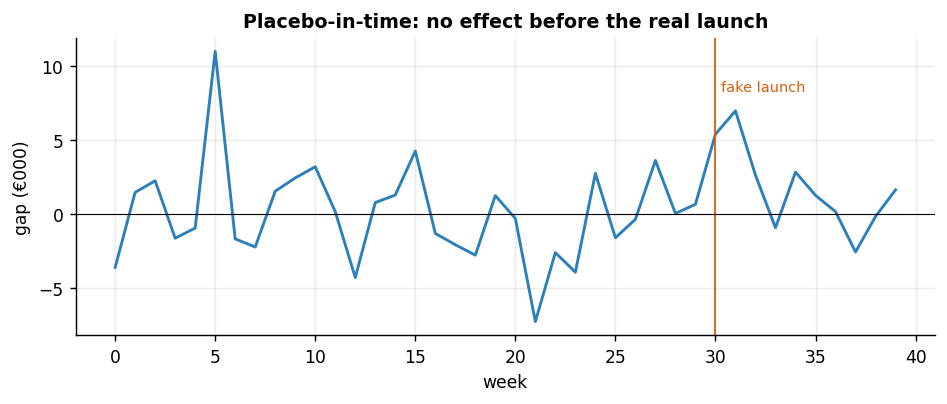

In [14]:
FAKE = launch - 10
gap_fake, _ = est.sc_effect_slsqp(y_tr[:launch], donors[:, :launch], slice(0, FAKE), slice(FAKE, launch))
fake_effect = float(gap_fake[FAKE:launch].mean())
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(t[:launch], gap_fake, color=plots.BLUE, lw=1.6); ax.axvline(FAKE, color=plots.ORANGE, lw=1); ax.axhline(0, color="k", lw=0.6)
ax.text(FAKE+0.3, ax.get_ylim()[1]*0.7, "fake launch", color=plots.ORANGE, fontsize=8)
ax.set_xlabel("week"); ax.set_ylabel("gap (€000)"); ax.set_title("Placebo-in-time: no effect before the real launch")
fig.tight_layout()
print(f"placebo-in-time avg gap €{fake_effect:.1f}k  vs  the same SLSQP fitter's pre-fit RMSE €{pre_rmse_cl:.2f}k "
      f"(should be ≈ 0, and it is well within the pre-fit noise, like-for-like: the fake-launch gap is an "
      f"SLSQP fit, so the SLSQP yardstick applies; the shipped AR(1) fit's pre-RMSE, €{sc_ar1['pre_rmse']:.2f}k, "
      f"is context, not the ruler), no spurious pre-effect.")

**Spillover, stress-testing the one assumption the placebos cannot touch.** The assumption table
in §3 was honest that placebo-in-space *cannot* detect spillover: if the campaign leaks into donor
markets, every placebo refit is contaminated in exactly the same way, so nothing looks unusual. But
the simulator can do what no real dataset can, rerun the same world with spillover *planted*.
Below, a fraction $\varphi$ of the true lift $\Delta_t$ leaks into five "neighbouring" donor
markets ($Y_{jt} \mathrel{+}= \varphi\,\Delta_t$ for $j$ in the neighbour set) and we refit.
First-order prediction *before* running it: the contaminated donors rise, so the synthetic
counterfactual rises, so the measured gap **shrinks** by roughly the spilled weight,

$$\text{bias} \;\approx\; -\,\varphi \sum_{j \in \text{neighbours}} w_j \;\times\; \text{lift},$$

i.e. spillover makes synthetic control **under-state** a real campaign, attenuation toward "no
effect", the opposite of the false-positive failure most people fear.

In [15]:
# Spillover stress test: leak a fraction phi of the true lift into 5 "neighbour" donors, refit,
# and watch the direction of the bias. Same deterministic SLSQP fitter as the LOO check, no MCMC,
# so the whole sweep costs milliseconds; FAST just uses a coarser phi grid.
phis = [0.0, 0.25, 0.5] if FAST else [0.0, 0.1, 0.25, 0.5]
neigh = list(range(5))                       # the 5 "neighbouring" donors (first five in the pool)
rows_sp = []
for phi in phis:
    d_sp = donors.copy(); d_sp[neigh] += phi * true_effect      # the campaign leaks next door
    g_sp, w_sp = est.sc_effect_slsqp(y_tr, d_sp, pre, post)
    rows_sp.append({"phi": phi, "est_total_k": g_sp[post].sum(),
                    "weight_on_neighbours": w_sp[neigh].sum()})
sp = pd.DataFrame(rows_sp)
print(sp.round(2).to_string(index=False), f"   (true total €{true_total:.0f}k)")
base, w0 = sp.est_total_k.iloc[0], sp.weight_on_neighbours.iloc[0]
meas = sp.est_total_k.iloc[-1] - base
pred = -phis[-1] * w0 * base                 # first-order: -phi x (weight on spilled donors) x lift
print(f"attenuation at phi={phis[-1]}: measured €{meas:+.0f}k vs first-order prediction "
      f"-phi·(Σ neighbour weights)·lift = €{pred:+.0f}k")
# the design fix promised in the §3 table, executed once: EXCLUDE the suspect neighbours and refit
d_sp = donors.copy(); d_sp[neigh] += phis[-1] * true_effect
keep = [k for k in range(donors.shape[0]) if k not in neigh]
g_ex, _ = est.sc_effect_slsqp(y_tr, d_sp[keep], pre, post)
print(f"excluding the 5 neighbours at phi={phis[-1]} restores the estimate to €{g_ex[post].sum():.0f}k "
      f"(contaminated pool: €{sp.est_total_k.iloc[-1]:.0f}k; clean pool: €{base:.0f}k)")
print("Read-out: spillover into donors raises the synthetic, so SC UNDER-states the")
print("lift, attenuation, not inflation. Conservative for a GO call, but it can")
print("turn a true GO into a NO-GO. And because no placebo can flag it, the fix is")
print("DESIGN, not statistics: exclude adjacent / media-overlapping donors up")
print("front, as just shown, a clean-but-smaller pool beats a bigger contaminated one.")

 phi  est_total_k  weight_on_neighbours
0.00       260.46                  0.17
0.10       255.58                  0.17
0.25       248.25                  0.17
0.50       236.04                  0.17    (true total €284k)
attenuation at phi=0.5: measured €-24k vs first-order prediction -phi·(Σ neighbour weights)·lift = €-22k
excluding the 5 neighbours at phi=0.5 restores the estimate to €246k (contaminated pool: €236k; clean pool: €260k)
Read-out: spillover into donors raises the synthetic, so SC UNDER-states the
lift, attenuation, not inflation. Conservative for a GO call, but it can
turn a true GO into a NO-GO. And because no placebo can flag it, the fix is
DESIGN, not statistics: exclude adjacent / media-overlapping donors up
front, as just shown, a clean-but-smaller pool beats a bigger contaminated one.


, 
# Depth C · The euro rollout decision & sensitivity

Pull it together into the number a VP signs off on, and pressure-test how the call moves with
the **launch-timing** assumption (did we mis-date the campaign?) and the **donor pool**.


{
  "true_total": 284.43,
  "estimated_total": 261.93,
  "ci90": [
    171.9,
    393.83
  ],
  "pre_rmse": 5.06,
  "p_space": 0.03,
  "p_rmse_ratio": 0.03,
  "placebo_in_time": 1.72,
  "P_lift_gt_cost": 0.78,
  "note_P_lift_gt_cost": "P(profit > cost) at the 35% margin; key name kept for downstream consumers",
  "decision": "TEST FURTHER",
  "eff_donors": 23.45
}


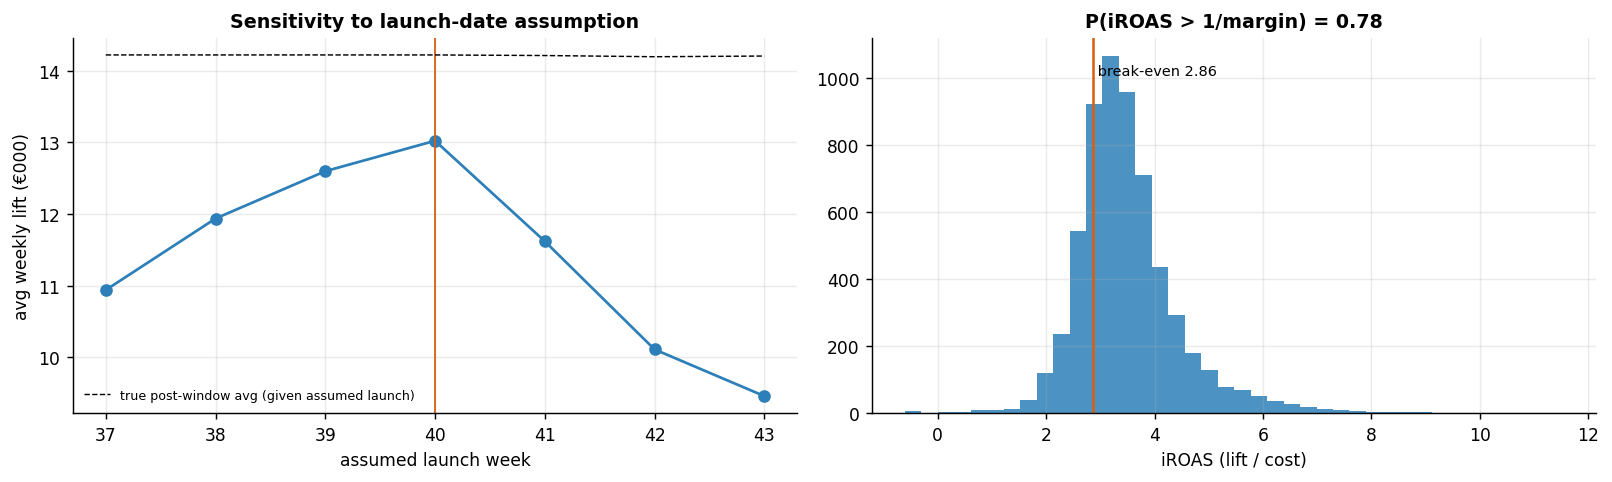

In [16]:
# sensitivity to assumed launch week (±3): does the estimated lift stay stable?
launch_grid = range(launch - 3, launch + 4)
lifts = []
for L in launch_grid:
    g, _ = est.sc_effect_slsqp(y_tr, donors, slice(0, L), slice(L, W))
    lifts.append(g[L:].mean())
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot(list(launch_grid), lifts, color=plots.BLUE, marker="o"); ax[0].axvline(launch, color=plots.ORANGE, lw=1)
# L-dependent benchmark: mis-dating folds no-effect weeks into the post window, so the true
# post-window average changes with the assumed launch L.
true_bench = [true_effect[max(L, launch):].mean() for L in launch_grid]
ax[0].plot(list(launch_grid), true_bench, color="k", ls="--", lw=0.8, label="true post-window avg (given assumed launch)")
ax[0].legend(frameon=False, fontsize=7); ax[0].set_xlabel("assumed launch week")
ax[0].set_ylabel("avg weekly lift (€000)"); ax[0].set_title("Sensitivity to launch-date assumption")
# iROAS curve (incremental revenue per euro spent). Break-even is NOT 1: at a MARGIN gross margin the
# firm needs iROAS > 1/MARGIN to profit (the margin trap). Distinct from go_no_go ROI = net/cost.
iroas = total_post_ar1 / CAMPAIGN_COST
breakeven = 1.0 / MARGIN
ax[1].hist(iroas, bins=40, color=plots.BLUE, alpha=0.85); ax[1].axvline(breakeven, color=plots.ORANGE, lw=1.4)
ax[1].text(breakeven, ax[1].get_ylim()[1] * 0.9, f" break-even {breakeven:.2f}", fontsize=8)
ax[1].set_xlabel("iROAS (lift / cost)"); ax[1].set_title(f"P(iROAS > 1/margin) = {(iroas > breakeven).mean():.2f}")
fig.tight_layout()
result = {"true_total": true_total, "estimated_total": float(total_post_ar1.mean()),
          "ci90": [float(np.quantile(total_post_ar1,0.05)), float(np.quantile(total_post_ar1,0.95))],
          "pre_rmse": sc_ar1["pre_rmse"], "p_space": p_space, "p_rmse_ratio": p_ratio,
          "placebo_in_time": fake_effect, "P_lift_gt_cost": decision["P_value_gt_cost"],
          # note: P_lift_gt_cost is P(profit > cost) at the 35% margin (profit = MARGIN*lift). The key
          # name predates the margin and is kept because downstream consumers read it by this name.
          "note_P_lift_gt_cost": "P(profit > cost) at the 35% margin; key name kept for downstream consumers",
          "decision": decision["decision"], "eff_donors": float(eff_n_ar1)}
print(json.dumps(_round(result), indent=2))

### The one-paragraph decision

> The campaign drove a **real** incremental lift, and it still stops short of a confident GO: **TEST
> FURTHER at this price**. The synthetic tracks the treated market before launch (pre-launch gap ≈
> **€0.9k**/week, no systematic mis-fit), though the pre-fit gate **fails** on the shipped AR(1) fit (§5z's
> gate line: pre-RMSE **€5.06k** against the **€4.4k** bar of a third of the weekly lift): this design sits
> at the edge of its resolution, and everything below is stated in that light. The blend spreads its weight
> across ~**23** effective donors (§5z prints the exact figure) (no single market dominates) and is robust to
> dropping any single donor (leave-one-out totals stay within **€239–276k** against the same-fitter SLSQP
> baseline of **€260k**). Nudging the *assumed* launch date does shift the estimate, but that is mechanical,
> not fragility: mis-dating folds no-effect weeks into the post window and dilutes the average lift, so the
> peak at the true launch week is itself a diagnostic. The post gap is the most extreme of any market on
> *both* placebo bookkeepings, the largest raw gap of the 30 and rank **1st of 30** on the scale-free
> RMSE-ratio test (raw-gap p = **0.033**, RMSE-ratio p = **0.033**; Depth B explains why the two agree
> exactly here), and the time placebo shows no spurious pre-effect (**€1.7k** against the same SLSQP
> fitter's **€3.2k** pre-fit RMSE), that permutation test is the calibrated evidence the effect is real.
> The euros then say: *probably, not surely*. The shipped AR(1) posterior puts the 20-week total at
> **€262k, 90% [€172k, €394k]** of revenue, which at the **35%** margin is an expected profit of **€91.7k**
> against the **€75k** spend: expected net **+€16.7k**, ROI **+22%**, and **P(profit > cost) = 0.78** (the
> JSON's `P_lift_gt_cost` key, its name notwithstanding, is exactly this probability). Four worlds in five
> pay; the fifth loses the spend, and under the cookbook's convention $0.5 \le P < 0.9$ is **TEST
> FURTHER**: act only on more evidence or a better price. This same evidence clears the 0.9 GO bar at any
> price up to **€67k** (11% below what we paid), so the sharpest move is to **renegotiate the buy**; a
> confirmatory test of ~**4** treated markets would also reach the bar, worth running only against the
> €4M national-rollout stakes, since the value of information on this single buy is ≈ **€2k**.

**Method summary.** Step 0's classical read, Abadie's SLSQP simplex weights plus placebo/permutation
inference, reaches essentially the same lift as the Bayesian fit (**€260k** vs **€262k**) and, on the
measure that decides it, a calibration in the same range: the classical randomization interval covers the
total on **83%** of 24 fresh panels, against the AR(1) posterior's **88%**, indistinguishable at this
Monte-Carlo resolution. That parity was *not* there a section ago: §4's first Bayesian model, with an
iid likelihood, covered **50%**, and §5x's coverage table is what caught it. So the lesson this notebook
teaches is not "the classical arm wins", it is that when a posterior's interval under-covers, the
**likelihood** is the suspect, not the paradigm and not the prior. §5z rewrote the likelihood with an AR(1)
error and the posterior earned its interval back without moving the estimate by more than a fraction of a
standard deviation. Keep the design-based placebos on the payroll not as a rival but as the **referee**: they
never modelled the errors, so they cannot be wrong about them, and they are how you find out that your
likelihood is lying. Then use the posterior for the one thing only a posterior can do, P(profit > cost), the
number §6 signs. **On real data:** notebook **07b** runs this same design on a real Google geo experiment;
Abadie's California Proposition 99 study remains the canonical public panel to practise on.

, 
## Book export

The book chapter built from this notebook (`book/chapters/geo_lift.tex`) does not retype a single
number. Every figure it prints, every euro amount, coverage rate, p-value, table cell and plot, 
is *emitted* below by `cmp.report` into `book/build/results/ (one shard per notebook)`, from which `book/build.py`
generates `macros.tex`, the booktabs tables and the vector figures the chapter `\input`s. A number
that goes stale is impossible; a number that goes *missing* is a LaTeX compile error rather than a
silent hole. The cell adds no output of its own, the notebook above is unchanged.


In [17]:
# ---------------------------------------------------------------- Book export (cmp.report)
# The book chapter never retypes a number: every figure it prints is emitted HERE, from this
# executed run, into book/build/results/ (one shard per notebook) -> macros.tex (see src/cmp/report.py). A missing
# macro is a LaTeX compile error, never a silent hole. Figures are re-rendered in book style
# (vector PDF, no in-figure title, the caption does that work) and closed immediately, so this
# cell changes nothing the notebook shows above.
import matplotlib as mpl
from cmp import report as R

# Retire this notebook's OLD keys before writing the new ones. Without this the shard is
# read-modify-written, so a key we stop emitting keeps its macro (and its table file)
# forever, the one way a stale number could survive the injection pipeline.
R.begin("nb07")

# Market labels are 'dma_08'. cmp.report ESCAPES table cells but passes CAPTIONS through as raw
# LaTeX (by design, captions carry math). So a bare label in a caption is a math-mode subscript
# and breaks the build with an error pointing at the chapter, not at here. Escape it once.
TL_TEX = treated_label.replace('_', r'\_')

def V(k, v, **kw):
    return R.value(f"nb07.{k}", v, **kw)

def K(x, nd=0):
    return f"{x:,.{nd}f}"

# --- the world, and the planted truth -------------------------------------------------
V("n_dmas", int(sales.shape[0]), fmt="d")
V("n_donors", int(donors.shape[0]), fmt="d")
V("n_weeks", int(W), fmt="d")
V("launch_week", int(launch), fmt="d")
V("n_post", int(n_post), fmt="d")
V("lift_pct", 12, fmt="d", note="planted proportional lift, per cent")
V("true_total", true_total, unit="EUR000", fmt=",.0f")
V("true_avg", true_avg, unit="EUR000", fmt=".1f")
V("cost", CAMPAIGN_COST, unit="EUR000", fmt=",.0f")
V("margin", 100 * MARGIN, fmt=".0f", note="gross margin, per cent")
V("iroas", total_cl / CAMPAIGN_COST, fmt=".2f", note="iROAS on the classical point total")
V("breakeven_iroas", 1.0 / MARGIN, fmt=".2f", note="1/margin: the iROAS a campaign must beat to profit")
V("breakeven_lift", CAMPAIGN_COST / MARGIN, unit="EUR000", fmt=",.0f",
  note="cost/margin: the TOTAL lift a campaign must clear to break even at this margin")
V("cl_profit", MARGIN * total_cl, unit="EUR000", fmt=",.0f",
  note="classical profit point estimate = margin * classical lift")
V("cl_net", MARGIN * total_cl - CAMPAIGN_COST, unit="EUR000", fmt="+,.0f",
  note="classical net at the point estimate = margin*lift - cost")
V("cl_profit_lo", MARGIN * ri_lo, unit="EUR000", fmt=",.0f",
  note="profit at the low end of the design-based randomization interval")
V("cl_profit_hi", MARGIN * ri_hi, unit="EUR000", fmt=",.0f",
  note="profit at the high end of the design-based randomization interval")
V("ri_iroas_lo", ri_lo / CAMPAIGN_COST, fmt=".2f", note="iROAS at the low end of the RI")
V("ri_iroas_hi", ri_hi / CAMPAIGN_COST, fmt=".2f", note="iROAS at the high end of the RI")
V("apparent_profit", total_cl - CAMPAIGN_COST, unit="EUR000", fmt=",.0f", note="revenue minus cost: the naive profit that ignores margin")

# --- Step 0 · the classical arm --------------------------------------------------------
V("cl_total", total_cl, unit="EUR000", fmt=",.0f")
V("cl_avg", avg_cl, unit="EUR000", fmt=".1f")
V("cl_pre_rmse", pre_rmse_cl, unit="EUR000", fmt=".2f")
V("cl_eff_donors", eff_n_cl, fmt=".1f")
V("cl_n_material", int((w_cl > 0.01).sum()), fmt="d")
V("cl_err", total_cl - true_total, unit="EUR000", fmt="+,.0f")
V("cl_err_pct", 100 * (total_cl - true_total) / true_total, fmt="+.0f")
V("ri_lo", ri_lo, unit="EUR000", fmt=",.0f")
V("ri_hi", ri_hi, unit="EUR000", fmt=",.0f")
V("ri_width", ri_hi - ri_lo, unit="EUR000", fmt=",.0f")
V("p_ratio", p_ratio, fmt=".3f")
V("p_gap", p_space, fmt=".3f")
V("treated_ratio", treated_ratio, fmt=".1f")
V("placebo_median_ratio", float(np.median(ratios)), fmt=".1f")
V("treated_rank", int(rank), fmt="d")
V("n_units", int(len(ratios)), fmt="d")
V("placebo_kept", int(n_kept), fmt="d")
V("placebo_dropped", int(n_donors - n_kept), fmt="d")
V("placebo_sd", float(placebo_tot.std()), unit="EUR000", fmt=".0f")
V("p_filter_two", sens[2.0], fmt=".3f")
V("p_filter_five", sens[5.0], fmt=".3f")
V("p_filter_twenty", sens[20.0], fmt=".3f")

# --- §4 / §5z · the Bayesian arm, BOTH likelihoods -------------------------------------
# `bayes_*` is the SHIPPED model (AR(1), §5z). `iid_*` is the misspecified first attempt (§4),
# kept because the chapter's whole argument is the contrast between them. Emitting both under
# explicit names is deliberate, and the notebook now binds the two fits to distinct names as well
# (sc_iid / sc_ar1, total_post_iid / total_post_ar1), so neither a macro like `bayes_sd` nor any
# downstream cell can silently change meaning when the shipped model changes.
V("bayes_total", float(total_post_ar1.mean()), unit="EUR000", fmt=",.0f")
V("bayes_lo", float(post_lo), unit="EUR000", fmt=",.0f")
V("bayes_hi", float(post_hi), unit="EUR000", fmt=",.0f")
V("bayes_width", float(post_hi - post_lo), unit="EUR000", fmt=",.0f")
V("bayes_sd", float(total_post_ar1.std()), unit="EUR000", fmt=".0f")
V("rho_post", float(rho_post.mean()), fmt=".2f")
V("rho_lo", float(np.quantile(rho_post, 0.05)), fmt=".2f")
V("rho_hi", float(np.quantile(rho_post, 0.95)), fmt=".2f")
V("rho_eight_implied", float(rho_post.mean() ** 8), fmt=".2f",
  note="ACF the fitted AR(1) implies at lag 8 = rho^8; decays where the measured ACF is flat")

V("iid_total", float(total_post_iid.mean()), unit="EUR000", fmt=",.0f")
V("iid_lo", float(post_lo_i), unit="EUR000", fmt=",.0f")
V("iid_hi", float(post_hi_i), unit="EUR000", fmt=",.0f")
V("iid_width", float(post_hi_i - post_lo_i), unit="EUR000", fmt=",.0f")
V("iid_sd", float(total_post_iid.std()), unit="EUR000", fmt=".0f")
V("width_ratio", float((post_hi - post_lo) / (post_hi_i - post_lo_i)), fmt=".1f")
V("bayes_pre_rmse", float(sc_ar1["pre_rmse"]), unit="EUR000", fmt=".2f")
V("bayes_eff_donors", float(eff_n_ar1), fmt=".1f")
V("n_draws", int(SC["draws"] * SC["chains"]), fmt="d")
V("rhat", sc_ar1["convergence"]["max_rhat"], fmt=".3f")
V("ess", sc_ar1["convergence"]["min_ess_bulk"], fmt=",.0f")
V("divergences", int(sc_ar1["convergence"]["n_divergences"]), fmt="d")
V("gate_ref", float(gate_ref), unit="EUR000", fmt=".1f")
V("gate", gate)
V("pre_gap_mean", float(eff_mean_ar1[pre].mean()), unit="EUR000", fmt=".2f")
V("loo_lo", float(min(loo)), unit="EUR000", fmt=",.0f")
V("loo_hi", float(max(loo)), unit="EUR000", fmt=",.0f")

# --- §5 · multi-seed calibration and the mechanism -------------------------------------
V("n_panels", int(len(ms)), fmt="d")
V("seed_bias", float(ms.err_iid.mean()), unit="EUR000", fmt="+,.0f")
V("seed_bias_pct", 100 * float(ms.err_iid.mean() / ms["true"].mean()), fmt="+.0f")
V("seed_sd", float(ms.err_iid.std()), unit="EUR000", fmt=".0f")
V("week_cov", 100 * float(ms.wk_cov_iid.mean()), fmt=".0f")
V("week_cov_arone", 100 * float(ms.wk_cov_ar1.mean()), fmt=".0f")
V("total_cov", 100 * float(ms.tot_cov_iid.mean()), fmt=".0f")     # the iid model's TOTAL coverage
V("total_cov_arone", 100 * float(ms.tot_cov_ar1.mean()), fmt=".0f")  # the AR(1) model's, the fix
V("seed_sd_arone", float(ms.err_ar1.std()), unit="EUR000", fmt=".0f")
V("bias_arone", float(ms.err_ar1.mean()), unit="EUR000", fmt="+,.0f")
V("ri_cov", 100 * float(np.mean(cov_ri)), fmt=".0f")
V("sd_believed", float(sd_believed), unit="EUR000", fmt=".0f")
V("sd_actual", float(sd_actual), unit="EUR000", fmt=".0f")
V("sd_ratio_panels", float(sd_actual / sd_believed), fmt=".1f")
V("underprice", float(ms.err_iid.std() / total_post_iid.std()), fmt=".1f")
V("placebo_sd_err_pct", 100 * abs(float(placebo_tot.std()) - float(ms.err_iid.std())) / float(ms.err_iid.std()), fmt=".0f")
V("acf_pre_one", float(acf_pre[0]), fmt="+.2f")
V("acf_pre_two", float(acf_pre[1]), fmt="+.2f")
V("acf_pre_three", float(acf_pre[2]), fmt="+.2f")
V("acf_noise_band", 2 / np.sqrt(res_pre.size), fmt=".2f")
V("rho_one", float(rho[0]), fmt=".2f")
V("rho_eight", float(rho[-1]), fmt=".2f")
V("offset_sd", sd_c, fmt=".2f",
  note="sd of the per-panel persistent offset c, the term that carries the n^2")
V("noise_sd", sd_eps, fmt=".2f", note="sd of the fresh weekly noise")
V("rho_implied", rho_implied, fmt=".2f",
  note="var(c)/(var(c)+var(eps)), what a constant-offset error implies for EVERY lag")
V("total_sd_true", total_sd_true, fmt=".1f")
V("total_sd_iid", total_sd_iid, fmt=".1f")
V("total_sd_ratio", total_sd_true / total_sd_iid, fmt=".1f")
V("n_placebo_worlds", int(E.shape[0]), fmt="d")
V("est_diff", abs(total_cl - float(total_post_ar1.mean())), unit="EUR000", fmt=".0f")
V("est_diff_pct", 100 * abs(total_cl - float(total_post_ar1.mean())) / true_total, fmt=".0f")

# --- §6 · the euro decision ------------------------------------------------------------
V("p_go", decision["P_value_gt_cost"], fmt=".2f")
V("exp_value", float(total_post_ar1.mean()), unit="EUR000", fmt=",.0f", note="expected LIFT (sales)")
V("exp_profit", decision["expected_value"], unit="EUR000", fmt=",.0f", note="expected PROFIT = margin*lift")
V("exp_net", decision["expected_net_value"], unit="EUR000", fmt=",.0f")
V("exp_roi", 100 * decision["expected_roi"], fmt="+.0f")
V("decision", decision["decision"])
V("p_go_rescaled", dec_wide["P_value_gt_cost"], fmt=".2f")
V("decision_rescaled", dec_wide["decision"])
V("voi", float(voi), unit="EUR000", fmt=".0f")
# k_needed is None when NO feasible confirmatory test reaches the 0.90 bar. That is not an edge
# case to paper over, it is a finding. Under the iid likelihood's false confidence the bar looked
# reachable; under the honest AR(1) interval it is not, and the chapter says so in words.
if k_needed is not None:
    V("k_needed", int(k_needed), fmt="d")
    V("k_feasible", "yes")
else:
    V("k_needed", "no feasible size",   # SHORT, noun-like: the chapter's sentence carries the "why"
      note="profit mean barely above the price -> victory margin too thin; no test size in range reaches 0.90")
    V("k_feasible", "no")
V("headroom", float(MARGIN * np.quantile(total_post_ar1, 0.10)), unit="EUR000", fmt=",.0f")
V("p_roas", float((total_post_ar1 / CAMPAIGN_COST > 1.0 / MARGIN).mean()), fmt=".2f", note="P(iROAS > break-even 1/margin)")

# --- Depths A/B/C · bake-off, time placebo, spillover ----------------------------------
V("naive_ba", bake["before/after"], unit="EUR000", fmt=".1f")
V("naive_avgctrl", bake["treated - avg ctrl"], unit="EUR000", fmt=".1f")
V("naive_did", bake["DiD vs avg ctrl"], unit="EUR000", fmt=".1f")
V("naive_sc", bake["synthetic control"], unit="EUR000", fmt=".1f")
V("placebo_time_gap", float(fake_effect), unit="EUR000", fmt=".1f")
V("placebo_time_week", int(FAKE), fmt="d")
V("sp_phi", float(phis[-1]), fmt=".2f")
V("sp_clean", float(sp.est_total_k.iloc[0]), unit="EUR000", fmt=",.0f")
V("sp_contaminated", float(sp.est_total_k.iloc[-1]), unit="EUR000", fmt=",.0f")
V("sp_excluded", float(g_ex[post].sum()), unit="EUR000", fmt=",.0f")
V("sp_measured", float(meas), unit="EUR000", fmt="+,.0f")
V("sp_predicted", float(pred), unit="EUR000", fmt="+,.0f")
V("sp_neighbour_weight", 100 * float(w0), fmt=".0f")
V("sp_n_neighbours", int(len(neigh)), fmt="d")

# --- tables ----------------------------------------------------------------------------
R.table(pd.DataFrame([
    {"Arm": "Classical SC · placebo interval",
     "Est.": K(total_cl), "5%": K(ri_lo), "95%": K(ri_hi), "Width": K(ri_hi - ri_lo),
     "sd": K(placebo_tot.std()),
     "Truth in?": "yes" if ri_lo <= true_total <= ri_hi else "no",
     "Coverage": f"{np.mean(cov_ri):.0%}"},
    {"Arm": "Bayesian SC · iid posterior",
     "Est.": K(total_post_iid.mean()), "5%": K(post_lo_i), "95%": K(post_hi_i),
     "Width": K(post_hi_i - post_lo_i), "sd": K(total_post_iid.std()),
     "Truth in?": "yes" if post_lo_i <= true_total <= post_hi_i else "no",
     "Coverage": f"{ms.tot_cov_iid.mean():.0%}"},
    {"Arm": "Bayesian SC · AR(1) posterior (the repair)",
     "Est.": K(total_post_ar1.mean()), "5%": K(post_lo), "95%": K(post_hi),
     "Width": K(post_hi - post_lo), "sd": K(total_post_ar1.std()),
     "Truth in?": "yes" if post_lo <= true_total <= post_hi else "no",
     "Coverage": f"{ms.tot_cov_ar1.mean():.0%}"},
]), "nb07.compare", align="lrrrrrcc",
    caption=(f"The same estimand, three arms: total post-launch lift over the {n_post} weeks "
             f"(EUR 000; planted truth {true_total:,.0f}). All three point estimates agree; the "
             f"intervals do not. \\emph{{Coverage}} is the share of {len(ms)} fresh panels on which each "
             f"nominal 90\\% interval contained the planted total, and it is the only column that "
             f"settles anything. The iid likelihood's interval is the narrowest and the least often "
             f"right; putting the residual's autocorrelation into the likelihood (AR(1)) restores it."),
    label="tab:sc:compare")

R.table(pd.DataFrame([
    {"Scale for the sd of the 20-week total": "Posterior sd, the iid likelihood",
     "Value": K(total_post_iid.std()), "Source": "likelihood (wrong)"},
    {"Scale for the sd of the 20-week total": "Posterior sd, the AR(1) repair",
     "Value": K(total_post_ar1.std()), "Source": "likelihood (fixed)"},
    {"Scale for the sd of the 20-week total": "Placebo / design-based sd (this panel)",
     "Value": K(placebo_tot.std()), "Source": "design"},
    {"Scale for the sd of the 20-week total": "Seed-to-seed sd of the estimation error",
     "Value": K(ms.err_iid.std()), "Source": "the referee"},
]), "nb07.scales", align="lrl",
    caption=(f"Four rival prices for the same uncertainty (EUR 000). The referee is the actual "
             f"sample-to-sample spread of the estimation error across {len(ms)} fresh panels. The iid "
             f"posterior underprices it by a factor of "
             f"{ms.err_iid.std() / total_post_iid.std():.1f}; the design-based placebo scale lands "
             f"within {100 * abs(placebo_tot.std() - ms.err_iid.std()) / ms.err_iid.std():.0f}\\% of "
             f"it without ever writing down a likelihood. Modelling the residual's persistence "
             f"explicitly (AR(1)) brings the likelihood-based price back onto the same scale as both."),
    label="tab:sc:scales")

R.table(pd.DataFrame([
    {"Estimator": "Planted truth", "Avg weekly lift": K(bake["true"], 1), "Error": "--"},
    {"Estimator": "Before / after (treated market only)", "Avg weekly lift": K(bake["before/after"], 1),
     "Error": f"{bake['before/after'] - bake['true']:+.1f}"},
    {"Estimator": "Treated minus average control", "Avg weekly lift": K(bake["treated - avg ctrl"], 1),
     "Error": f"{bake['treated - avg ctrl'] - bake['true']:+.1f}"},
    {"Estimator": "Difference-in-differences vs average control", "Avg weekly lift": K(bake["DiD vs avg ctrl"], 1),
     "Error": f"{bake['DiD vs avg ctrl'] - bake['true']:+.1f}"},
    {"Estimator": "Synthetic control", "Avg weekly lift": K(bake["synthetic control"], 1),
     "Error": f"{bake['synthetic control'] - bake['true']:+.1f}"},
]), "nb07.naive", align="lrr",
    caption=("Same panel, four estimators (average weekly lift, EUR 000). The shortcuts book the "
             "shared trend and the level gap as campaign effect; only the reweighted control comes "
             "close. The estimator is the identification strategy."),
    label="tab:sc:naive")

_top = np.argsort(-w_mean_ar1)[:8]
R.table(pd.DataFrame([
    {"Donor market": donor_labels[i], "SLSQP weight": f"{w_cl[i]:.3f}",
     "Posterior mean weight": f"{w_mean_ar1[i]:.3f}"} for i in _top
]), "nb07.weights", align="lrr",
    caption=(f"The eight donors carrying most posterior weight. Abadie's constrained least squares "
             f"concentrates on a sparse handful ({eff_n_cl:.1f} effective donors, $1/\\sum_j w_j^2$); the "
             f"flat Dirichlet prior spreads the same fit over {eff_n_ar1:.1f}, more stable out of sample, "
             f"less interpretable as a business object."),
    label="tab:sc:weights")

R.table(pd.DataFrame([
    {"Spillover $\\varphi$": f"{r.phi:.2f}", "Estimated total": K(r.est_total_k),
     "Weight on the contaminated donors": f"{r.weight_on_neighbours:.2f}"}
    for r in sp.itertuples()
]), "nb07.spillover", align="lrr", math_headers=True,
    caption=(f"Spillover attenuates. A fraction $\\varphi$ of the true lift is leaked into "
             f"{len(neigh)} neighbouring donors and the estimator refit (EUR 000; planted truth "
             f"{true_total:,.0f}). Contaminated donors lift the synthetic, so the measured gap "
             f"\\emph{{shrinks}}: synthetic control under-states a real campaign, never inflates it. "
             f"Dropping the suspect donors restores the estimate to {g_ex[post].sum():,.0f}."),
    label="tab:sc:spillover", fmt="%.2f")

# --- figures (book style: vector PDF, no in-figure title, closed so nothing renders inline) ---
with mpl.rc_context(R.book_style()):
    f = plt.figure(figsize=(6.6, 3.2)); a = f.add_subplot(111)
    for j in range(sales.shape[0]):
        a.plot(t, sales[j], color="#cccccc", lw=0.6, alpha=0.7)
    a.plot(t, sales[treated_idx], color="#111", lw=1.8, label=f"{treated_label} (treated)")
    a.axvline(launch, color=plots.ORANGE, lw=1)
    a.set_xlabel("week"); a.set_ylabel("sales (€000)"); a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb07.panel", caption=(
        f"The panel. {sales.shape[0]} markets over {W} weeks, all riding the same trend, seasonal cycle "
        f"and macro random walk; the treated market (dark) receives the campaign in week {launch}. The "
        f"shared macro wave is what makes a before/after comparison worthless and a weighted blend of "
        f"donors possible."), label="fig:sc:panel")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    a.plot(t, y_tr, color="#111", lw=1.7, label=f"{treated_label} (treated)")
    a.plot(t, cf_cl, color=plots.BLUE, ls="--", lw=1.6, label="synthetic control (SLSQP)")
    a.fill_between(t[post], cf_cl[post], y_tr[post], color=plots.GREEN, alpha=0.25,
                   label="post-launch gap")
    a.axvline(launch, color=plots.ORANGE, lw=1)
    a.set_xlabel("week"); a.set_ylabel("sales (€000)"); a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb07.sc", caption=(
        f"The treated market and its synthetic control. Simplex weights fitted on weeks "
        f"0--{launch - 1} only; the synthetic tracks the treated market to a pre-fit RMSE of "
        f"{pre_rmse_cl:.2f} (EUR 000) before launch, which is the precondition for reading the shaded "
        f"post-launch gap as campaign lift."), label="fig:sc:sc")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.4)); a = f.add_subplot(111)
    a.plot(t, eff_mean_ar1, color=plots.BLUE, lw=1.8, label="Bayesian AR(1) mean gap")
    a.fill_between(t, eff_lo_ar1, eff_hi_ar1, color=plots.BLUE, alpha=0.2, label="90% posterior band")
    a.plot(t, gap_cl, color=plots.ORANGE, lw=1.5, label="classical SLSQP gap")
    a.plot(t, true_effect, color="k", ls="--", lw=1.2, label="planted lift")
    a.axvline(launch, color=plots.ORANGE, lw=1, alpha=0.45); a.axhline(0, color="k", lw=0.6)
    a.set_xlabel("week"); a.set_ylabel("weekly lift (€000)"); a.legend(frameon=False)
    f.tight_layout()
    R.figure(f, "nb07.gap", caption=(
        f"Recovery, two estimators. The weekly gap between the treated market and its counterfactual: the "
        f"Bayesian AR(1) posterior mean (blue, with its posterior-predictive band) and the classical SLSQP "
        f"point gap (orange), both against the planted lift (dashed). The two land on essentially the same "
        f"weekly path: the AR(1) posterior and the classical point agree on the estimate here. (The "
        f"discarded iid fit sat about {abs(total_post_ar1.mean()-total_post_iid.mean())/n_post:.1f}k "
        f"per week lower -- invisible here, {abs(total_post_ar1.mean()-total_post_iid.mean()):.0f}k once summed; "
        f"the likelihood moves the interval far more than the estimate, but it does move both, "
        f"Section~\\ref{{sec:sc:compare}}.) "
        f"The pre-launch gap averages {eff_mean_ar1[pre].mean():.2f} (EUR 000), and the "
        f"90\\% posterior-predictive band covers the true path {100 * ms.wk_cov_ar1.mean():.0f}\\% of the time across "
        f"panels, per-week, the likelihood is roughly right. Section~\\ref{{sec:sc:compare}} shows what "
        f"happens when these weeks are summed."), label="fig:sc:gap")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.2)); ax2 = f.subplots(1, 2)
    plots.placebo_spaghetti(ax2[0], t, placebo_gaps, real_gap, launch, p_space,
                            xlabel="week", ylabel="gap (€000)")
    ax2[1].hist(ratios, bins=20, color=plots.GREY, alpha=0.8)
    ax2[1].axvline(treated_ratio, color=plots.GREEN, lw=2)
    ax2[1].set_xlabel("post/pre RMSE ratio"); ax2[1].set_ylabel("markets")
    f.tight_layout()
    R.figure(f, "nb07.placebo", caption=(
        f"Design-based inference. \\emph{{Left}}: the same estimator refit on every donor market as if it "
        f"had been treated ({n_kept} of {n_donors} survive Abadie's 5$\\times$ pre-fit filter); the grey "
        f"paths are the distribution of gaps the world produces from noise alone, the coloured path is the "
        f"treated market. \\emph{{Right}}: the same comparison on Abadie's scale-free post/pre RMSE ratio, "
        f"on which the treated market ranks {rank} of {len(ratios)} ($p = {p_ratio:.3f}$)."),
        label="fig:sc:placebo")
    plt.close(f)

    f = plt.figure(figsize=(6.6, 3.2)); a = f.add_subplot(111)
    _lags = np.arange(1, len(rho) + 1)                                # contiguous lags 1..8
    a.bar(_lags, rho, width=0.62, color=plots.GREY, alpha=0.85,
          label="measured (out-of-sample gap error)")
    _rp = float(rho_post.mean())                                     # the SHIPPED AR(1) posterior mean
    a.plot(_lags, [_rp ** k for k in _lags], color=plots.BLUE, lw=1.8, ls=":", marker="o", ms=3.5,
           label=f"shipped AR(1) implies $\\rho^{{k}}$ ($\\rho={_rp:.2f}$)")
    a.axhline(rho_implied, color=plots.ORANGE, lw=1.8, ls="--",
              label=f"if a persistent offset: flat at {rho_implied:.2f}")
    a.axhline(0, color=plots.GREY, lw=0.8, zorder=0)                  # what the iid likelihood assumes
    a.set_ylim(-0.06, max(0.55, max(rho) * 1.3))
    a.set_xticks(_lags); a.set_xlim(0.35, _lags[-1] + 0.9)
    a.set_xlabel("lag (weeks)"); a.set_ylabel("autocorrelation of the gap error")
    a.legend(frameon=False, loc="upper right", fontsize=8)
    f.tight_layout()
    R.figure(f, "nb07.acf", caption=(
        f"Flat, not decaying. Autocorrelation of the synthetic control's out-of-sample gap error, "
        f"measured on {E.shape[0]} placebo worlds where the true lift is zero (so the gap \\emph{{is}} the "
        f"error). The bars stay near {rho_implied:.2f} out to eight weeks: they track the flat line a "
        f"persistent offset predicts (orange, dashed). The blue dotted curve is the autocorrelation the "
        f"\\emph{{shipped}} AR(1) posterior actually implies: at its fitted $\\rho$ it starts above the "
        f"data at lag one and has all but vanished by lag eight, the very decay the data refuse. So AR(1) "
        f"matches the \\emph{{variance of the sum}}, not this \\emph{{shape}}. A correlation that will not decay is the signature of a level shift, "
        f"not short memory; the iid likelihood assumes zero at every lag (the grey baseline)."),
        label="fig:sc:acf")
    plt.close(f)

    # Two blends, one total: corroboration across weightings, NOT one method recovering the other.
    _order = np.argsort(-w_cl)                                       # donors sorted by classical weight
    _xp = np.arange(len(_order))
    f = plt.figure(figsize=(6.8, 3.2)); a = f.add_subplot(111)
    a.bar(_xp - 0.2, w_cl[_order], width=0.4, color=plots.BLUE, alpha=0.85,
          label=f"classical SLSQP  ({eff_n_cl:.1f} effective donors)")
    a.bar(_xp + 0.2, w_mean_ar1[_order], width=0.4, color=plots.ORANGE, alpha=0.85,
          label=f"AR(1) Dirichlet posterior mean  ({eff_n_ar1:.1f} effective donors)")
    a.set_xlabel("donor market (sorted by classical weight)"); a.set_ylabel("weight in the blend")
    a.set_xticks([]); a.legend(frameon=False, fontsize=8, loc="upper right")
    f.tight_layout()
    R.figure(f, "nb07.weightprofiles", caption=(
        f"Two blends, one total. The classical fit concentrates on {eff_n_cl:.1f} effective donors "
        f"(blue, a few tall bars); the flat-Dirichlet AR(1) posterior spreads the same reconstruction "
        f"over {eff_n_ar1:.1f} (orange, many short bars). Yet the totals land together, EUR "
        f"{total_cl:,.0f}k classical against EUR {total_post_ar1.mean():,.0f}k Bayesian. The AR(1) repair "
        f"does not recover the classical \\emph{{weights}}; it reaches the same \\emph{{total}} by a "
        f"different route: corroboration across two weightings, not one method reproducing the other."),
        label="fig:sc:weightprofiles")
    plt.close(f)

    f = plt.figure(figsize=(6.9, 3.1)); ax2 = f.subplots(1, 2)
    plots.decision_hist(ax2[0], MARGIN * total_post_ar1, CAMPAIGN_COST, true_total=MARGIN * true_total)
    ax2[0].set_xlabel("total profit (€000)"); ax2[0].set_ylabel("posterior draws")
    ax2[1].plot(cost_grid, p_beats, color=plots.BLUE, lw=2)
    ax2[1].axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.2)
    ax2[1].axhline(0.9, color=plots.GREEN, ls="--")
    ax2[1].set_xlabel("campaign cost (€000)"); ax2[1].set_ylabel("P(profit > cost)")
    f.tight_layout()
    R.figure(f, "nb07.euro", caption=(   # key != nb07.decision: that name is a scalar (the verdict)
        f"The decision, in euros. \\emph{{Left}}: the posterior of total \\emph{{profit}} "
        f"({100*MARGIN:.0f}\\% of incremental sales) against the {CAMPAIGN_COST:,.0f} (EUR 000) "
        f"campaign cost; the mass to the right of the cost line is "
        f"$P(\\text{{profit}} > \\text{{cost}}) = {decision['P_value_gt_cost']:.2f}$. \\emph{{Right}}: the "
        f"same posterior read as a headroom curve, $P(\\text{{profit}} > c)$ swept over a hypothetical "
        f"price $c$. The 0.9 bar is cleared only at a price of "
        f"{MARGIN*np.quantile(total_post_ar1, 0.10):,.0f} or below, the number to take to the media-buying "
        f"negotiation."), label="fig:sc:decision")
    plt.close(f)

# --- the panel, the worked example, and every constant the chapter's equations show -----
# These four assets are the chapter's "show, don't assert" layer: the raw panel the method sees,
# the counterfactual worked out by hand for one week, the DGP's constants with their reasons, and
# the two figures that make the simplex constraint and the permutation test visible.

# The same pre-period objective WITHOUT the simplex constraint: ordinary least squares. Used by
# the params table (the aspect-ratio argument) and by the simplex figure below.
w_unc, *_ = np.linalg.lstsq(donors[:, pre].T, y_tr[pre], rcond=None)
cf_unc = w_unc @ donors
rmspe_simplex = float(np.sqrt(np.mean((y_tr[pre] - cf_cl[pre]) ** 2)))
rmspe_unc = float(np.sqrt(np.mean((y_tr[pre] - cf_unc[pre]) ** 2)))

# 1 · the data, before any method -------------------------------------------------------
_wk_show = [launch - 6, launch - 4, launch - 2, launch - 1, launch, launch + 1, launch + 5, launch + 10]
_top_w = np.argsort(-w_cl)[:4]                    # the four donors the fitted blend leans on hardest
_mkt_rows = [(treated_label, y_tr)] + [(donor_labels[i], donors[i]) for i in _top_w]
R.table(pd.DataFrame([
    {**{"Market": (f"{lab} (treated)" if k == 0 else lab)},
     **{(f"wk {w} (launch)" if w == launch else f"wk {w}"): f"{ser[w]:,.1f}" for w in _wk_show}}
    for k, (lab, ser) in enumerate(_mkt_rows)
]), "nb07.panel_rows", align="l" + "r" * len(_wk_show),
    caption=(f"The data, before any method: weekly sales (EUR 000) for the treated market and the "
             f"four donors the fitted blend leans on hardest, over the eight weeks that straddle "
             f"the launch. This table, one row per market and one column per week, for "
             f"{sales.shape[0]} markets and {W} weeks, is \\emph{{everything}} synthetic control "
             f"ever sees. There is no hold-out column, no second treated market and no "
             f"randomization: the counterfactual for week {launch} onward has to be built out of "
             f"the other rows or not at all."),
    label="tab:sc:panel")

# 2 · the worked example, the counterfactual IS a weighted average of donor markets -----
# Shown once, at a legible scale, for one named post-launch week, on the classical simplex weights
# (sparse enough to read; §5z's Dirichlet blend spreads the same fit over ~23 donors and would not
# fit on a page). The identities below are ASSERTED, not hoped for: the chapter prints these numbers
# and claims they add up, so if they ever stop adding up the notebook must fail here rather than let
# the chapter lie.
DC_WEEK = launch                              # the first campaign week, named, not chosen for size
_mat = w_cl >= 0.01                           # the donors carrying non-negligible weight
_order = np.argsort(-w_cl)
_rows_dc = [{"Donor market": donor_labels[i], "Weight w": f"{w_cl[i]:.3f}",
             f"Sales, week {DC_WEEK}": f"{donors[i, DC_WEEK]:,.2f}",
             "Contribution (w x sales)": f"{w_cl[i] * donors[i, DC_WEEK]:,.2f}"}
            for i in _order if _mat[i]]
_rest = ~_mat
_c_rest = float(w_cl[_rest] @ donors[_rest, DC_WEEK])
dc_synth = float(w_cl @ donors[:, DC_WEEK])
dc_actual = float(y_tr[DC_WEEK])
dc_gap = dc_actual - dc_synth
_rows_dc += [
    {"Donor market": f"All other {int(_rest.sum())} donors (weight < 0.01)",
     "Weight w": f"{float(w_cl[_rest].sum()):.3f}", f"Sales, week {DC_WEEK}": "--",
     "Contribution (w x sales)": f"{_c_rest:,.2f}"},
    {"Donor market": "Synthetic control (sum of contributions)", "Weight w": f"{w_cl.sum():.3f}",
     f"Sales, week {DC_WEEK}": "--", "Contribution (w x sales)": f"{dc_synth:,.2f}"},
    {"Donor market": f"{treated_label}, ACTUAL sales", "Weight w": "--",
     f"Sales, week {DC_WEEK}": f"{dc_actual:,.2f}", "Contribution (w x sales)": "--"},
    {"Donor market": "GAP = actual - synthetic (the estimated lift)", "Weight w": "--",
     f"Sales, week {DC_WEEK}": "--", "Contribution (w x sales)": f"{dc_gap:,.2f}"},
]
assert np.isclose(w_cl.sum(), 1.0, atol=1e-8)                       # the weights are on the simplex
assert np.isclose((w_cl * donors[:, DC_WEEK]).sum(), dc_synth, atol=1e-8)   # contributions -> synthetic
assert np.isclose(dc_synth, cf_cl[DC_WEEK], atol=1e-8)              # ... and it IS the estimator's own
assert np.isclose(dc_gap, gap_cl[DC_WEEK], atol=1e-8)               # counterfactual, and its own gap
R.table(pd.DataFrame(_rows_dc), "nb07.donor_calc", align="lrrr",
    caption=(f"The counterfactual, computed by hand for one week. Week {DC_WEEK} is the first "
             f"campaign week; the weights are Abadie's simplex weights, fitted on weeks "
             f"0--{launch - 1} only and \\emph{{never}} refitted after launch. Each donor "
             f"contributes its own week-{DC_WEEK} sales times its weight; the contributions sum to "
             f"the synthetic control, and the treated market's actual sales minus that number is "
             f"the week's estimated lift. The weights sum to one and are all non-negative, so the "
             f"synthetic is a genuine weighted average: it cannot leave the range the real "
             f"donor markets occupy. That is the whole method; everything after it is uncertainty. "
             f"(Figures are shown to two decimals; the summation identity is asserted exactly, in "
             f"code, before this table is emitted.)"),
    label="tab:sc:donorcalc")
V("dc_week", int(DC_WEEK), fmt="d")
V("dc_synth", dc_synth, unit="EUR000", fmt=",.2f")
V("dc_actual", dc_actual, unit="EUR000", fmt=",.2f")
V("dc_gap", dc_gap, unit="EUR000", fmt="+,.2f")
V("dc_n_donors_used", int(_mat.sum()), fmt="d")
V("dc_weight_sum", float(w_cl.sum()), fmt=".3f")
# the macro is injected into PROSE, so the value must be LaTeX-safe: "dma_08" would be read
# as a math-mode subscript and break the build with an error pointing at the chapter.
V("dc_top_name", donor_labels[int(np.argmax(w_cl))].replace("_", r"\_"))
V("dc_top_weight", float(w_cl.max()), fmt=".3f")

# 3 · every constant the chapter displays inside an equation -----------------------------
# The DGP's constants are bare literals in src/cmp/dgp.py::geo_panel (the `trend`/`season`/`macro`
# and `levels`/`loads`/noise lines). They are mirrored here ONCE, at the emit site, so the chapter's
# equations and this table cannot drift apart. Everything else is read from a live variable.
PAR_TREND = 0.4                             # dgp.py: trend = 0.4 * t
PAR_SEASON, PAR_SEASON_HALF = 8.0, 4.0      # dgp.py: 8*sin(2 pi t/26) + 4*sin(2 pi t/13)
PAR_MACRO_SD = 1.2                          # dgp.py: macro = cumsum(rng.normal(0, 1.2, n_weeks))
PAR_NOISE_SD = 3.0                          # dgp.py: rng.normal(0, 3, (n_dmas, n_weeks))
PAR_LEVEL_LO, PAR_LEVEL_HI = 80.0, 140.0    # dgp.py: levels = rng.uniform(80, 140, n_dmas)
PAR_LOAD_LO, PAR_LOAD_HI = 0.6, 1.4         # dgp.py: loads = rng.uniform(0.6, 1.4, (n_dmas, 3))
R.table(pd.DataFrame([{"Symbol": s, "Value": v, "What it does": d, "Why this value": w} for s, v, d, w in [
    ("g_t = 0.4 t  (trend slope)", f"{PAR_TREND:.1f}",
     "The shared secular growth: every market's sales rise about EUR 0.4k per week times its own loading.",
     f"It is the part of the {true_total:,.0f} (EUR 000) planted lift a before/after comparison books as "
     f"campaign effect; the bake-off measures exactly that error."),
    ("Seasonal amplitudes (26- and 13-week)", f"{PAR_SEASON:.0f} / {PAR_SEASON_HALF:.0f}",
     "Two sine harmonics, shared by all markets: a half-year cycle and a quarterly one.",
     "Large enough that an unweighted 'treated minus average control' cannot cancel them (it has the "
     "wrong loadings), which is what the naive bake-off shows."),
    ("Macro random-walk scale (sigma_eta)", f"{PAR_MACRO_SD:.1f}",
     "Weekly innovation of the macro factor m_t = sum of N(0, 1.2^2) shocks, a random walk shared by "
     "every market.",
     f"This is the villain of the chapter. It is the one shared factor with no fixed shape, so the share "
     f"of it the donor weights fail to match stays in the gap as a slowly wandering offset rather than "
     f"fresh weekly noise. That persistence is what the AR(1) fit measures directly, rho posterior mean "
     f"{rho_post.mean():.2f}, 90% interval [{np.quantile(rho_post, 0.05):.2f}, "
     f"{np.quantile(rho_post, 0.95):.2f}], and setting it to zero, as the iid likelihood does, is what "
     f"underprices the 20-week total."),
    ("Idiosyncratic noise SD (sigma_eps)", f"{PAR_NOISE_SD:.0f}",
     "Each market's own weekly noise, EUR 000, the only error term that IS independent across weeks.",
     f"It sets the resolution floor: the treated market's own noise alone puts about EUR "
     f"{PAR_NOISE_SD:.0f}k of unavoidable weekly error into any counterfactual, and the fitted pre-fit "
     f"RMSE ({pre_rmse_cl:.2f}) is already at that floor. The blend cannot be sharpened further, which is "
     f"why the pre-fit gate is close-run rather than comfortable."),
    ("Market baselines c_i", f"U({PAR_LEVEL_LO:.0f}, {PAR_LEVEL_HI:.0f})",
     "Each market's own level, EUR 000 per week.",
     "A near two-fold spread of levels is why a raw 'treated minus average control' difference is "
     "meaningless before any differencing, the bake-off's second row."),
    ("Factor loadings lambda_i", f"U({PAR_LOAD_LO:.1f}, {PAR_LOAD_HI:.1f})",
     "How strongly market i responds to each of the three shared factors.",
     "Loadings differ across markets, so no single donor matches the treated market, but a convex "
     "combination of donors can match its loadings, which is precisely what makes the effect identifiable."),
    ("Markets (J + 1)", f"{sales.shape[0]:d}",
     f"One treated market and {donors.shape[0]} donors.",
     f"It caps the permutation test's resolution: with {sales.shape[0]} units the smallest attainable "
     f"RMSE-ratio p-value is 1/{sales.shape[0]} = {1 / sales.shape[0]:.3f}, which is the p the chapter "
     f"reports."),
    ("Pre-launch weeks (T0)", f"{launch:d}",
     "The window the weights are fitted on.",
     f"{launch} weeks against {donors.shape[0]} free weights, barely more observations than "
     f"coefficients. That is exactly why the constraint earns its keep: an unconstrained fit on this "
     f"aspect ratio interpolates the pre-period noise (it reaches an RMSPE of {rmspe_unc:.2f} against the "
     f"simplex fit's {rmspe_simplex:.2f}) and pays for it after launch."),
    ("Post-launch weeks (n)", f"{n_post:d}",
     "The window the lift is summed over.",
     f"The estimand is a {n_post}-week TOTAL, and it is the aggregation over these weeks that turns the "
     f"error's persistence into a coverage failure: an iid likelihood prices the total's sd as sqrt(n) "
     f"times sigma, and gets it wrong by a factor of about 2."),
    ("Planted lift", "12%",
     f"A proportional lift on the treated market from week {launch}: EUR {true_avg:.1f}k per week, "
     f"EUR {true_total:,.0f}k in total.",
     f"It is deliberately within reach of the campaign's price: at EUR {CAMPAIGN_COST:,.0f}k the truth's "
     f"profit clears cost by roughly one posterior standard deviation, so the chapter's euro call is "
     f"decided by the WIDTH of the interval as much as by its location, which is what makes the "
     f"calibration failure a business failure and not a footnote."),
    ("Campaign cost", f"{CAMPAIGN_COST:,.0f}",
     "What the TV campaign cost, EUR 000.",
     f"Set so the campaign clearly pays in expectation without reaching certainty: at a "
     f"{100*MARGIN:.0f}% margin the {total_cl:,.0f}k lift is worth {MARGIN*total_cl:,.0f}k of profit "
     f"against {CAMPAIGN_COST:,.0f}k spent, so the decision quantity "
     f"P(profit > cost) = {(MARGIN*total_post_ar1 > CAMPAIGN_COST).mean():.2f} lands between the 0.5 "
     f"and 0.9 bars, a genuine TEST FURTHER, not a foregone call either way."),
]]), "nb07.params", align="llp{0.31\\linewidth}p{0.38\\linewidth}",
    caption=(f"Every constant the chapter's equations display, with the reason it is what it is. "
             f"The first seven are the data-generating process of \\texttt{{cmp.dgp.geo\\_panel}}; the "
             f"last four are the design and the price. Sales are in EUR 000 per market-week."),
    label="tab:sc:params")
V("par_trend", PAR_TREND, fmt=".1f")
V("par_season_amp", PAR_SEASON, fmt=".0f")
V("par_season_amp_short", PAR_SEASON_HALF, fmt=".0f")
V("par_macro_sd", PAR_MACRO_SD, fmt=".1f")
V("par_noise_sd", PAR_NOISE_SD, unit="EUR000", fmt=".0f")
V("par_level_lo", PAR_LEVEL_LO, unit="EUR000", fmt=".0f")
V("par_level_hi", PAR_LEVEL_HI, unit="EUR000", fmt=".0f")
V("par_load_lo", PAR_LOAD_LO, fmt=".1f")
V("par_load_hi", PAR_LOAD_HI, fmt=".1f")
V("par_markets", int(sales.shape[0]), fmt="d")
V("par_pre_weeks", int(launch), fmt="d")
V("par_post_weeks", int(n_post), fmt="d")
V("par_lift_pct", 12, fmt="d")
V("par_cost", CAMPAIGN_COST, unit="EUR000", fmt=",.0f")

# 4 · why the weights live on the simplex ------------------------------------------------
# Because this is a simulation we can grade each counterfactual against the path the treated market
# would TRULY have taken (y_tr - true_effect), the only fair test of an extrapolation.
post_rmspe_simplex = float(np.sqrt(np.mean((y_tr[post] - cf_cl[post] - true_effect[post]) ** 2)))
post_rmspe_unc = float(np.sqrt(np.mean((y_tr[post] - cf_unc[post] - true_effect[post]) ** 2)))
unc_total = float((y_tr[post] - cf_unc[post]).sum())
# One panel proves nothing about extrapolation, a noisier counterfactual can miss in the flattering
# direction, and on THIS panel it does (the unconstrained 20-week total lands no further from the
# planted truth than the simplex one). So measure it where the answer is known: the placebo worlds,
# true lift ZERO, in which the post-launch gap IS the counterfactual's error.
# ONE screen, disclosed: est.sc_weights_slsqp occasionally returns its equal-weight STARTING point
# (w_max = 1/J = 0.034) without reporting failure, a silent optimizer misconvergence, not a donor
# pool that cannot be matched (its pre-fit RMSE is 15-30k against a converged ~3k). Those worlds are
# screened out and COUNTED, never quietly averaged in.
_oos_s, _oos_u, _tot_s, _tot_u, _n_bad = [], [], [], [], 0
for _s in range(12 if FAST else 24):
    _psd, _pte, _plz, _ptl = dgp.geo_panel(n_weeks=60, launch_week=40, n_dmas=30, lift_pct=0.0,
                                           seed=400 + _s)
    _psl = _psd.values.T; _pti = list(_psd.columns).index(_ptl)
    _pdn = np.delete(_psl, _pti, axis=0); _pyt = _psl[_pti]
    _gs, _ws = est.sc_effect_slsqp(_pyt, _pdn, pre, post)
    if _ws.max() <= 0.05:                     # never moved off the 1/J start -> misconverged
        _n_bad += 1
        continue
    _wu, *_ = np.linalg.lstsq(_pdn[:, pre].T, _pyt[pre], rcond=None)
    _gu = _pyt - _wu @ _pdn
    _oos_s.append(np.sqrt(np.mean(_gs[post] ** 2))); _oos_u.append(np.sqrt(np.mean(_gu[post] ** 2)))
    _tot_s.append(_gs[post].sum()); _tot_u.append(_gu[post].sum())
oos_s, oos_u = float(np.mean(_oos_s)), float(np.mean(_oos_u))
sd_s, sd_u = float(np.std(_tot_s)), float(np.std(_tot_u))
n_worlds = len(_oos_s)
V("unc_w_min", float(w_unc.min()), fmt="+.2f")
V("unc_w_max", float(w_unc.max()), fmt="+.2f")
V("unc_w_sum", float(w_unc.sum()), fmt=".2f")
V("unc_n_negative", int((w_unc < 0).sum()), fmt="d")
V("rmspe_simplex", rmspe_simplex, unit="EUR000", fmt=".2f")
V("rmspe_unconstrained", rmspe_unc, unit="EUR000", fmt=".2f")
V("unc_total", unc_total, unit="EUR000", fmt=",.0f")
V("unc_post_rmspe", post_rmspe_unc, unit="EUR000", fmt=".1f")
V("simplex_post_rmspe", post_rmspe_simplex, unit="EUR000", fmt=".1f")
V("hull_worlds", int(n_worlds), fmt="d")
V("hull_worlds_dropped", int(_n_bad), fmt="d")
V("hull_oos_simplex", oos_s, unit="EUR000", fmt=".2f")
V("hull_oos_unconstrained", oos_u, unit="EUR000", fmt=".2f")
V("hull_oos_ratio", oos_u / oos_s, fmt=".1f")
V("hull_sd_simplex", sd_s, unit="EUR000", fmt=".0f")
V("hull_sd_unconstrained", sd_u, unit="EUR000", fmt=".0f")

with mpl.rc_context(R.book_style()):
    f = plt.figure(figsize=(7.6, 3.5)); a = f.subplots(1, 2)
    xs = np.arange(len(w_cl))
    a[0].bar(xs - 0.2, w_cl, width=0.4, color=plots.BLUE, label="simplex")
    a[0].bar(xs + 0.2, w_unc, width=0.4, color=plots.ORANGE, label="unconstrained")
    a[0].axhline(0, color="k", lw=0.8); a[0].axhline(1, color="k", lw=0.5, ls=":")
    a[0].set_ylim(min(-0.95, w_unc.min() - 0.05), 2.15)
    a[0].set_xlabel("donor market"); a[0].set_ylabel("weight")
    a[0].set_xticks([0, 9, 19, 28])
    a[0].set_xticklabels([donor_labels[i] for i in (0, 9, 19, 28)], rotation=25, ha="right", fontsize=7.5)
    a[0].legend(frameon=False, loc="upper left", fontsize=7.5, ncol=1, handlelength=1.2, borderpad=0.2)
    a[0].text(0.98, 0.97, f"simplex:  all ≥ 0,  Σw = {w_cl.sum():.2f}\n"
                          f"OLS:  {int((w_unc < 0).sum())} negative,  Σw = {w_unc.sum():.2f}\n"
                          f"       range {w_unc.min():+.2f} … {w_unc.max():+.2f}",
              transform=a[0].transAxes, ha="right", va="top", fontsize=7,
              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb", lw=0.6))
    a[1].plot(t, y_tr, color="#111", lw=1.5, label="treated market")
    a[1].plot(t, y_tr - true_effect, color=plots.GREEN, lw=1.1, alpha=0.9, label="true untreated path")
    a[1].plot(t, cf_cl, color=plots.BLUE, ls="--", lw=1.4, label="synthetic, simplex")
    a[1].plot(t, cf_unc, color=plots.ORANGE, ls="-.", lw=1.4, label="synthetic, unconstrained")
    a[1].axvline(launch, color=plots.ORANGE, lw=1, alpha=0.5)
    a[1].axvspan(launch, W - 1, color=plots.GREY, alpha=0.10)
    _ymin, _ymax = a[1].get_ylim()
    a[1].set_ylim(_ymin - 0.42 * (_ymax - _ymin), _ymax + 0.04 * (_ymax - _ymin))
    a[1].set_xlabel("week"); a[1].set_ylabel("sales (€000)")
    a[1].legend(frameon=False, fontsize=7, loc="upper left", ncol=2, columnspacing=1.0)
    a[1].text(0.5, 0.03,
              f"pre-period fit:  OLS €{rmspe_unc:.2f}k  beats  simplex €{rmspe_simplex:.2f}k\n"
              f"post-launch error vs the true path:\n"
              f"OLS €{post_rmspe_unc:.1f}k  vs  simplex €{post_rmspe_simplex:.1f}k\n"
              f"({n_worlds} zero-lift worlds: OLS {oos_u / oos_s:.1f}× worse)",
              transform=a[1].transAxes, ha="center", va="bottom", fontsize=7, linespacing=1.35,
              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb", lw=0.6))
    f.tight_layout()
    R.figure(f, "nb07.simplex", caption=(
        f"Why the weights live on the simplex. \\emph{{Left}}: the donor weights, fitted on the same "
        f"pre-period objective, with the constraint (blue: every weight non-negative, summing to "
        f"{w_cl.sum():.2f}) and without it (orange: ordinary least squares, which puts "
        f"{int((w_unc < 0).sum())} of the {donors.shape[0]} weights below zero, runs from "
        f"{w_unc.min():+.2f} to {w_unc.max():+.2f}, and sums to {w_unc.sum():.2f}). The orange bars are "
        f"not a weighted average of real markets: a market can enter the counterfactual \\emph{{negatively}}. "
        f"\\emph{{Right}}: what dropping the constraint buys. The unconstrained blend fits the pre-period "
        f"\\emph{{better}}, RMSPE {rmspe_unc:.2f} against {rmspe_simplex:.2f} (EUR 000), which is the "
        f"symptom, not the prize: {donors.shape[0]} free coefficients on {launch} weeks interpolate the "
        f"noise, and the fit then has to extrapolate past the launch. Because this is a simulation we can "
        f"grade that extrapolation against the path the treated market would truly have taken (green): the "
        f"unconstrained counterfactual misses it by {post_rmspe_unc:.1f} a week against the simplex fit's "
        f"{post_rmspe_simplex:.1f}, and across {n_worlds} placebo worlds where the true lift is zero its "
        f"post-launch error is {oos_u / oos_s:.1f}$\\times$ larger. What the constraint does \\emph{{not}} "
        f"buy is a better number on every panel: here the unconstrained {n_post}-week total "
        f"({unc_total:,.0f}) lands no further from the planted {true_total:,.0f} than the simplex fit's "
        f"({total_cl:,.0f}), because a noisier counterfactual can miss in the flattering direction. The "
        f"guarantee is about the \\emph{{object}}: a weighted average of real markets cannot leave the "
        f"range they occupy, so its post-launch projection is interpolation you can defend rather than "
        f"extrapolation you got away with."), label="fig:sc:simplex")
    plt.close(f)

    # 5 · the permutation test, made readable (both p's, annotated ON the plot) -----------
    f = plt.figure(figsize=(7.0, 3.1)); a = f.subplots(1, 2)
    a[0].hist(ratios, bins=18, color=plots.GREY, alpha=0.85)
    a[0].axvline(treated_ratio, color=plots.GREEN, lw=2.2)
    _y0 = a[0].get_ylim()[1] * 1.40; a[0].set_ylim(0, _y0)
    a[0].annotate(f"{treated_label} (treated)\nrank {rank} of {len(ratios)}",
                  xy=(treated_ratio, _y0 * 0.22), xytext=(treated_ratio * 0.58, _y0 * 0.50),
                  fontsize=8, color=plots.GREEN,
                  arrowprops=dict(arrowstyle="->", color=plots.GREEN, lw=1.1))
    a[0].text(0.03, 0.96, f"permutation p = {p_ratio:.3f}", transform=a[0].transAxes,
              ha="left", va="top", fontsize=9.5, color=plots.GREEN,
              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=plots.GREEN, lw=0.8))
    a[0].set_xlabel("post/pre RMSE ratio"); a[0].set_ylabel("markets")
    a[1].hist(np.abs(placebo_gaps[:, post].mean(1)), bins=14, color=plots.GREY, alpha=0.85)
    _real_abs = abs(float(real_gap[post].mean()))
    a[1].axvline(_real_abs, color=plots.GREEN, lw=2.2)
    _y1 = a[1].get_ylim()[1] * 1.40; a[1].set_ylim(0, _y1)
    a[1].annotate(f"{treated_label} (treated)\n+€{real_gap[post].mean():.1f}k/week",
                  xy=(_real_abs, _y1 * 0.20), xytext=(_real_abs * 0.42, _y1 * 0.48),
                  fontsize=8, color=plots.GREEN,
                  arrowprops=dict(arrowstyle="->", color=plots.GREEN, lw=1.1))
    a[1].text(0.03, 0.96, f"permutation p = {p_space:.3f}", transform=a[1].transAxes,
              ha="left", va="top", fontsize=9.5, color=plots.GREEN,
              bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=plots.GREEN, lw=0.8))
    a[1].set_xlabel("|mean post-launch gap| (€000/week)"); a[1].set_ylabel("placebo markets")
    f.tight_layout()
    R.figure(f, "nb07.placebo_dist", caption=(
        f"The permutation test, read off the picture. The null is \\emph{{the campaign did nothing to "
        f"{TL_TEX}}}: under it the treated market is just another market, so the same estimator "
        f"is refit on each donor as if \\emph{{it}} had been treated, and the treated market's statistic "
        f"is ranked against theirs. \\emph{{Left}}: Abadie's scale-free post/pre RMSE ratio for all "
        f"{len(ratios)} markets; the treated market ranks {rank}, giving $p = {p_ratio:.3f}$. "
        f"\\emph{{Right}}: the two-sided absolute mean post-launch gap over the {n_kept} placebos that "
        f"survive the 5$\\times$ pre-fit filter, giving $p = {p_space:.3f}$. What would have falsified "
        f"the campaign: a treated statistic sitting anywhere inside the grey bulk, a handful of "
        f"untreated markets posting jumps as large, relative to their own pre-fit, as the one we are "
        f"crediting to EUR {CAMPAIGN_COST:,.0f}k of television."),
        label="fig:sc:placebodist")
    plt.close(f)

print(f"book export: {len([k for k in R.load() if k.startswith('nb07.') and not k.startswith('nb07b')])} "
      f"keys emitted to book/build/results/ (one shard per notebook)")


book export: 181 keys emitted to book/build/results/ (one shard per notebook)


In [18]:
# -------------------------------------------------- Book export (continued): fresh-panel coverage
# Two assets, both REUSING the multi-seed calibration frame `ms` (built in §5), the same panels
# behind the coverage numbers the chapter already reports, plus the R.figure / V helpers defined
# in the cell just above. No new fit is run here.
from matplotlib.lines import Line2D
_z90 = 1.6448536269514722                      # 90% two-sided normal quantile

# Value: cross-panel MEAN of the AR(1) posterior sd of the n-week total lift (EUR 000). `ms.tot_sd_ar1`
# is each panel's own posterior sd of the total; their mean is the typical scale the honest likelihood
# assigns to the very number the euro decision integrates.
V("arone_crosspanel_sd", float(ms.tot_sd_ar1.mean()), unit="", fmt=",.0f")

# Monte-Carlo resolution of the coverage estimates themselves: the binomial standard error, in
# percentage points, of a coverage share estimated on len(ms) panels. 88% vs 83% is indistinguishable
# at this resolution, and the chapter gets to say so with a measured number, not an adjective.
def _cov_se_pp(phat):
    return 100.0 * float(np.sqrt(phat * (1.0 - phat) / len(ms)))
V("cov_se_iid", _cov_se_pp(float(ms.tot_cov_iid.mean())), fmt=".0f",
  note="binomial Monte-Carlo SE (percentage points) of the iid TOTAL-coverage estimate over the fresh panels")
V("cov_se_arone", _cov_se_pp(float(ms.tot_cov_ar1.mean())), fmt=".0f",
  note="binomial Monte-Carlo SE (percentage points) of the AR(1) TOTAL-coverage estimate over the fresh panels")
V("cov_se_ri", _cov_se_pp(float(np.mean(cov_ri))), fmt=".0f",
  note="binomial Monte-Carlo SE (percentage points) of the classical randomization-interval coverage estimate")

with mpl.rc_context(R.book_style()):
    fcov = plt.figure(figsize=(7.1, 3.4)); axc = fcov.subplots(1, 2, sharey=True)
    order = np.argsort(ms["true"].values)      # sort panels by planted total -> a readable truth curve
    x = np.arange(len(ms))
    for ax, tag, name in ((axc[0], "iid", "iid likelihood"),
                          (axc[1], "ar1", "AR(1) likelihood")):
        truth = ms["true"].values[order]
        pt = (ms[f"err_{tag}"] + ms["true"]).values[order]     # posterior-mean total on each panel
        sd = ms[f"tot_sd_{tag}"].values[order]                 # that panel's own posterior sd
        cov = ms[f"tot_cov_{tag}"].values[order]               # EXACT stored 90% quantile-interval hit
        lo, hi = pt - _z90 * sd, pt + _z90 * sd
        for i in range(len(x)):
            c = plots.GREEN if cov[i] else plots.ORANGE
            ax.vlines(x[i], lo[i], hi[i], color=c, lw=1.6, zorder=2)
            ax.plot(x[i], pt[i], "o", ms=3.2, color=c, zorder=3)
        ax.plot(x, truth, color="k", lw=1.2, ls="--", zorder=4)
        ax.text(0.03, 0.97, f"{name}\ncoverage {100 * cov.mean():.0f}% of {len(ms)} panels",
                transform=ax.transAxes, ha="left", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb", lw=0.6))
        ax.set_xlabel("panel (sorted by planted total)")
    axc[0].set_ylabel("20-week total lift (€000)")
    _handles = [Line2D([0], [0], color=plots.GREEN, lw=1.6, marker="o", ms=3.2, label="interval covers truth"),
                Line2D([0], [0], color=plots.ORANGE, lw=1.6, marker="o", ms=3.2, label="interval misses truth"),
                Line2D([0], [0], color="k", lw=1.2, ls="--", label="planted truth")]
    axc[1].legend(handles=_handles, frameon=False, fontsize=7.5, loc="lower right")
    fcov.tight_layout()
    R.figure(fcov, "nb07.coverage", caption=(
        f"Calibration on fresh panels. Each vertical bar is one of {len(ms)} independently simulated "
        f"panels (planted 12\\% lift, distinct seeds); the dot is that panel's posterior-mean {n_post}-week "
        f"total and the bar its nominal-90\\% interval, coloured green where the interval contains the "
        f"panel's planted truth (dashed) and orange where it misses. \\emph{{Left}}: the iid likelihood, "
        f"whose intervals are too narrow, so the covered share falls far below 90\\% "
        f"({100 * ms.tot_cov_iid.mean():.0f}\\%). \\emph{{Right}}: the AR(1) repair, which "
        f"prices the residual's persistence and restores coverage to {100 * ms.tot_cov_ar1.mean():.0f}\\%. "
        f"Bars are drawn as posterior mean $\\pm 1.645\\,\\sigma$ from each panel's stored posterior sd; the "
        f"colour is the exact quantile-interval test behind the coverage numbers the chapter reports."),
        label="fig:sc:coverage")
    plt.close(fcov)

print(f"coverage export: iid {100 * ms.tot_cov_iid.mean():.0f}% vs AR(1) {100 * ms.tot_cov_ar1.mean():.0f}%; "
      f"AR(1) cross-panel total-lift sd €{ms.tot_sd_ar1.mean():,.0f}k")

coverage export: iid 50% vs AR(1) 88%; AR(1) cross-panel total-lift sd €94k


## Extra figures for the book

Book-only figures (body and appendix), emitted after the main export cell so `R.begin("nb07")` does not wipe them. Everything is reused from the cells above; the two new fits (the Dirichlet prior sweep and the SLSQP week-bootstrap) are cached via `load_or_run`.

In [19]:
# ---------------------------------------------------------------- Extra figures for the book
# Additional book-style figures (vector PDF, no in-figure title, closed immediately). This cell runs
# AFTER the main export cell's R.begin("nb07"), so these emits ADD to the shard rather than being
# wiped by it. Every quantity is reused from earlier cells; the only NEW fits (the prior sweep and the
# SLSQP bootstrap) go through load_or_run, so re-execution stays fast.
import matplotlib as mpl
from cmp import report as R
from cmp.cache import load_or_run

_esc = lambda s: s.replace("_", r"\_")     # LaTeX-safe donor labels for captions

# --- NEW computations, cached ---------------------------------------------------------------------
# (a) Prior sweep: the iid Dirichlet synthetic control refit on the pre-period at three
#     concentrations. Mirrors est.synthetic_control exactly, with a = alpha * ones(J).
def _sc_iid_alpha(alpha, draws=500, tune=500, chains=2, seed=1):
    import pymc as pm
    J = donors.shape[0]
    with pm.Model():
        w = pm.Dirichlet("w", a=alpha * np.ones(J))
        sd = pm.HalfNormal("sd", 5)
        mu = pm.math.dot(w, donors[:, pre])
        pm.Normal("obs", mu=mu, sigma=sd, observed=y_tr[pre])
        idata = pm.sample(draws=draws, tune=tune, chains=chains, cores=chains,
                          random_seed=seed, progressbar=False, target_accept=0.95)
    Wp = idata.posterior["w"].values.reshape(-1, J)
    sdp = idata.posterior["sd"].values.reshape(-1)
    cf_mean = Wp @ donors
    _rng = np.random.default_rng(seed + 12345)
    cf_pred = cf_mean + _rng.standard_normal(cf_mean.shape) * sdp[:, None]
    return (y_tr[None, :] - cf_pred)[:, post].sum(1)

_ALPHAS = [0.5, 1.0, 2.0]
_PS = dict(draws=500, tune=500, chains=2)
prior_tot = {a: load_or_run(f"07_priorsens_a{a}", (lambda a=a: _sc_iid_alpha(a, **_PS)),
                            inputs=dict(seed=SEED, alpha=a, model="iid_dirichlet_v1", **_PS))
             for a in _ALPHAS}
print("prior sweep (total lift):  " + "   ".join(
    f"alpha={a}: mean {prior_tot[a].mean():.0f}k, sd {prior_tot[a].std():.0f}k" for a in _ALPHAS))

# (b) Bernstein-von Mises: bootstrap the classical SLSQP total by resampling the pre-period weeks
#     with replacement and refitting the simplex weights (~500 reps; SLSQP is fast, no MCMC).
def _bvm_boot(n_rep=500, seed=20260715):
    rng = np.random.default_rng(seed)
    n_pre = int(launch)
    out = []
    for _ in range(n_rep):
        idx = rng.integers(0, n_pre, n_pre)
        w = est.sc_weights_slsqp(y_tr[idx], donors[:, idx])
        if w.max() <= 0.05:            # optimizer fell back to equal weights -> discard the draw
            continue
        out.append(float((y_tr - w @ donors)[post].sum()))
    return np.array(out)

_N_BVM = 500
boot_tot = load_or_run("07_bvm_boot", lambda: _bvm_boot(_N_BVM),
                       inputs=dict(seed=SEED, n_rep=_N_BVM, fitter="slsqp_weekboot_v1"))
print(f"BvM bootstrap: kept {len(boot_tot)}/{_N_BVM}  mean {boot_tot.mean():.0f}k, sd {boot_tot.std():.0f}k "
      f"(iid post sd {total_post_iid.std():.0f}k, AR(1) post sd {total_post_ar1.std():.0f}k, "
      f"seed-to-seed sd {ms.err_iid.std():.0f}k)")

_be = CAMPAIGN_COST / MARGIN            # break-even LIFT: profit = MARGIN * lift = cost

# --- figures (book style) -------------------------------------------------------------------------
with mpl.rc_context(R.book_style()):
    # 1 · BODY -------------------------------------- iid vs shipped posterior of the 20-week total
    fig = plt.figure(figsize=(6.6, 3.4)); ax = fig.add_subplot(111)
    ax.hist(total_post_iid, bins=45, density=True, color=plots.ORANGE, alpha=0.35)
    ax.hist(total_post_ar1, bins=45, density=True, color=plots.BLUE, alpha=0.35)
    ax.hist(total_post_iid, bins=45, density=True, histtype="step", lw=1.6, color=plots.ORANGE,
            label="iid posterior (too narrow)")
    ax.hist(total_post_ar1, bins=45, density=True, histtype="step", lw=1.6, color=plots.BLUE,
            label="AR(1) posterior (honest)")
    ax.axvline(true_total, color="k", ls="--", lw=1.2, label=f"planted truth €{true_total:,.0f}k")
    ax.axvline(_be, color="#333333", ls=":", lw=1.5, label=f"break-even €{_be:,.0f}k (cost/margin)")
    ax.set_xlabel("total post-launch lift (€000)"); ax.set_ylabel("posterior density"); ax.set_yticks([])
    ax.legend(frameon=False, fontsize=7.2)
    fig.tight_layout()
    R.figure(fig, "nb07.iid_vs_shipped", caption=(
        fr"Two posteriors of the {n_post}-week total lift: one estimand, one dataset, two likelihoods. "
        fr"The iid likelihood (orange) is the narrow band, and on this panel its nominal 90\% interval "
        fr"\emph{{excludes}} the planted truth (dashed): it centres EUR "
        fr"{abs(total_post_ar1.mean() - total_post_iid.mean()):.0f}k below the repaired fit and covers "
        fr"the truth on only {100 * ms.tot_cov_iid.mean():.0f}\% of fresh panels. The AR(1) repair "
        fr"(blue) is wider, contains the truth, and its centre (EUR {total_post_ar1.mean():,.0f}k) lands "
        fr"beside the classical estimate (EUR {total_cl:,.0f}k); it is the honest posterior the euro "
        fr"decision integrates ({100 * ms.tot_cov_ar1.mean():.0f}\% coverage). The break-even lift "
        fr"(dotted, cost$/$margin $=$ EUR {_be:,.0f}k) sits almost on top of the truth, so the go/no-go "
        fr"call turns on the \emph{{width}} of the blue posterior, not its location. That is the margin "
        fr"trap made visual."), label="fig:sc:iidshipped")
    plt.close(fig)

    # 2 · BODY -------------------------------------------------- prior sensitivity of the iid fit
    fig = plt.figure(figsize=(6.6, 3.4)); ax = fig.add_subplot(111)
    _acol = {0.5: plots.GOLD, 1.0: plots.BLUE, 2.0: plots.GREEN}
    for a in _ALPHAS:
        s = prior_tot[a]
        ax.hist(s, bins=45, density=True, histtype="step", lw=1.8, color=_acol[a],
                label=fr"$\alpha={a}$  (mean €{s.mean():,.0f}k, sd €{s.std():.0f}k)")
    ax.axvline(true_total, color="k", ls="--", lw=1.0, label=f"planted truth €{true_total:,.0f}k")
    ax.set_xlabel("total post-launch lift (€000)"); ax.set_ylabel("posterior density"); ax.set_yticks([])
    ax.legend(frameon=False, fontsize=7.5)
    fig.tight_layout()
    R.figure(fig, "nb07.prior_sensitivity", caption=(
        fr"Prior sensitivity of the iid synthetic-control fit. The Dirichlet concentration on the donor "
        fr"weights is swept over $\alpha \in \{{0.5, 1, 2\}}$: from a sparsity-favouring prior "
        fr"($\alpha<1$, mass toward single-donor corners), through the flat prior ($\alpha=1$, the "
        fr"notebook's default), to a centre-favouring prior ($\alpha>1$, weight spread across donors). "
        fr"The posterior of the {n_post}-week total lift barely moves: the three means span a few EUR "
        fr"000 against a posterior sd near EUR {prior_tot[1.0].std():.0f}k. With {launch} pre-period "
        fr"weeks the likelihood, not the prior, drives the result. (Short chains, "
        fr"{_PS['draws']}$\times${_PS['chains']} draws, cached.)"), label="fig:sc:priorsens")
    plt.close(fig)

    # 4 · BODY ------------------------------------------------ naive bake-off, one bar per estimator
    fig = plt.figure(figsize=(6.6, 3.4)); ax = fig.add_subplot(111)
    _bk_keys = ["before/after", "treated - avg ctrl", "DiD vs avg ctrl", "synthetic control"]
    _bk_lab = ["before / after", "treated − avg control", "DiD vs avg control", "synthetic control"]
    _bk_val = [bake[k] for k in _bk_keys]
    _bk_col = [plots.GREY, plots.GREY, plots.GREY, plots.BLUE]
    _ypos = np.arange(len(_bk_keys))[::-1]
    ax.barh(_ypos, _bk_val, color=_bk_col, alpha=0.9)
    ax.axvline(true_avg, color="k", ls="--", lw=1.2, label=f"planted truth €{true_avg:.1f}k/wk")
    ax.set_yticks(_ypos); ax.set_yticklabels(_bk_lab, fontsize=8.5)
    ax.set_xlabel("average weekly lift (€000)")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    fig.tight_layout()
    _naive_maxerr = max(abs(bake[k] - true_avg) for k in _bk_keys[:3])
    R.figure(fig, "nb07.naivebars", caption=(
        fr"The estimator is the identification strategy. Four estimates of the average weekly lift on the "
        fr"same panel; only the reweighted synthetic control (blue) lands on the planted truth (dashed, "
        fr"EUR {true_avg:.1f}k/week). Before/after books the shared trend as effect; treated-minus-average"
        fr"-control books the level gap; difference-in-differences removes the level but not the "
        fr"factor-loading mismatch. The three shortcuts miss the truth by up to EUR {_naive_maxerr:.1f}k a "
        fr"week, more than a third of the effect they are meant to measure."), label="fig:sc:naivebars")
    plt.close(fig)

    # 5 · BODY -------------------------------------------------------- placebo-in-time, all weeks
    gap_ft, _w_ft = est.sc_effect_slsqp(y_tr, donors, slice(0, FAKE), slice(FAKE, W))
    _real_after = float(gap_ft[launch:].mean())
    fig = plt.figure(figsize=(6.8, 3.3)); ax = fig.add_subplot(111)
    ax.axhspan(-pre_rmse_cl, pre_rmse_cl, color=plots.GREY, alpha=0.18,
               label=f"±pre-fit RMSE (€{pre_rmse_cl:.1f}k)")
    ax.plot(t, gap_ft, color=plots.BLUE, lw=1.6, label="SLSQP gap (fake-launch fit)")
    ax.axhline(0, color="k", lw=0.6)
    ax.axvline(FAKE, color=plots.ORANGE, lw=1.4, ls="--", label=f"fake launch (wk {FAKE})")
    ax.axvline(launch, color=plots.GREEN, lw=1.4, label=f"real launch (wk {launch})")
    ax.annotate(f"fake window avg\n€{fake_effect:.1f}k ≈ 0", xy=((FAKE + launch) / 2, 0),
                xytext=((FAKE + launch) / 2, ax.get_ylim()[1] * 0.62), ha="center", fontsize=7.5,
                color=plots.ORANGE, arrowprops=dict(arrowstyle="->", color=plots.ORANGE, lw=1.0))
    ax.set_xlabel("week"); ax.set_ylabel("gap (€000)")
    ax.legend(frameon=False, fontsize=7.3, loc="upper left")
    fig.tight_layout()
    R.figure(fig, "nb07.placebotime", caption=(
        fr"Placebo-in-time falsification. The synthetic control is refit with the launch back-dated to "
        fr"week {FAKE} (ten weeks before the campaign actually ran) and the weekly gap plotted over "
        fr"the whole horizon. Through the fake post-window (weeks {FAKE}--{launch}) the gap stays inside "
        fr"the $\pm$pre-fit-RMSE band and averages EUR {fake_effect:.1f}k, i.e. essentially zero: a launch "
        fr"that did not happen produces no effect, as it must. The real effect appears only after the true "
        fr"launch (week {launch}, green), where the gap lifts to about EUR {_real_after:.1f}k a week."),
        label="fig:sc:placebotime")
    plt.close(fig)

    # 6 · BODY --------------------------------------------------- spillover attenuation curve
    fig = plt.figure(figsize=(6.6, 3.4)); ax = fig.add_subplot(111)
    _clean = float(sp.est_total_k.iloc[0])
    ax.plot(sp.phi, sp.est_total_k, color=plots.BLUE, marker="o", lw=1.8, label="estimated total lift")
    ax.axhline(true_total, color="k", ls="--", lw=1.2, label=f"planted truth €{true_total:,.0f}k")
    ax.axhline(_clean, color=plots.GREEN, ls=":", lw=1.5, label=f"clean pool (φ=0) €{_clean:,.0f}k")
    ax.set_xlabel(r"spillover fraction $\varphi$ leaked into neighbour donors")
    ax.set_ylabel("estimated total lift (€000)")
    ax.legend(frameon=False, fontsize=7.5)
    fig.tight_layout()
    R.figure(fig, "nb07.spillover_curve", caption=(
        fr"Spillover attenuates the estimate. A fraction $\varphi$ of the true lift is leaked into "
        fr"{len(neigh)} neighbouring donors and the synthetic control refit. Because the contaminated "
        fr"donors are themselves lifted, the synthetic rises and the measured gap \emph{{shrinks}}: the "
        fr"estimate falls monotonically below both the planted truth (dashed) and the clean-pool estimate "
        fr"(dotted) as $\varphi$ grows. Synthetic control therefore \emph{{under}}-states a real campaign "
        fr"under spillover: conservative for a GO call, though it can turn a true GO into a NO-GO. No "
        fr"placebo can detect this; the fix is design (exclude adjacent donors), not statistics."),
        label="fig:sc:spillover")
    plt.close(fig)

    # 7 · APPENDIX ------------------------------------------ the Dirichlet prior on the 3-simplex
    fig = plt.figure(figsize=(7.6, 2.9)); axes = fig.subplots(1, 3)
    _rng = np.random.default_rng(7)
    _tri = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
    _corners = np.vstack([_tri, _tri[0]])
    for ax, a in zip(axes, [0.5, 1.0, 2.0]):
        pts = _rng.dirichlet(a * np.ones(3), size=800) @ _tri
        ax.plot(_corners[:, 0], _corners[:, 1], color="#666666", lw=1.0)
        ax.scatter(pts[:, 0], pts[:, 1], s=5, color=plots.BLUE, alpha=0.35, edgecolors="none")
        ax.text(0.5, -0.06, fr"$\alpha={a}$", transform=ax.transAxes, ha="center", va="top", fontsize=10)
        ax.set_aspect("equal"); ax.axis("off")
    fig.tight_layout()
    R.figure(fig, "nb07.app_dirichlet", caption=(
        fr"The Dirichlet weight prior on the 3-donor simplex. Each point is one draw of a weight vector "
        fr"$(w_1, w_2, w_3)$ with $\sum_j w_j = 1$, plotted on the 2-simplex. At $\alpha=0.5$ the mass "
        fr"piles into the corners: the prior favours \emph{{sparse}} blends leaning on a single donor; "
        fr"at $\alpha=1$ it is uniform over the simplex (the notebook's default); at $\alpha=2$ it "
        fr"concentrates toward the centre: balanced blends that spread weight across donors. This is "
        fr"the prior whose pull on the total-lift posterior the prior-sensitivity check shows to be "
        fr"negligible: with a 40-week pre-period the data overwhelm it."), label="fig:sc:appdirichlet")
    plt.close(fig)

    # 8 · APPENDIX ---------------------------------------------- RMSE of the pre-period gaps
    _g = real_gap[pre]; _tt = t[pre]; _rmse = float(np.sqrt(np.mean(_g ** 2)))
    fig = plt.figure(figsize=(6.8, 3.3)); ax = fig.add_subplot(111)
    ml, sl, bl = ax.stem(_tt, _g, linefmt="-", markerfmt="o", basefmt=" ")
    plt.setp(sl, color=plots.BLUE, lw=1.0); plt.setp(ml, color=plots.BLUE, ms=3.4)
    ax.axhline(0, color="k", lw=0.8)
    ax.axhspan(-_rmse, _rmse, color=plots.ORANGE, alpha=0.15)
    ax.axhline(_rmse, color=plots.ORANGE, lw=1.2, ls="--")
    ax.axhline(-_rmse, color=plots.ORANGE, lw=1.2, ls="--", label=f"±RMSE = ±€{_rmse:.2f}k")
    _rmse_txt = (r"$\mathrm{RMSE}=\sqrt{\frac{1}{T_0}\sum_{t<T_0}\mathrm{gap}_t^{2}}$"
                 + f"\n= €{_rmse:.2f}k over {len(_g)} weeks")
    ax.text(0.03, 0.96, _rmse_txt, transform=ax.transAxes, ha="left", va="top", fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb", lw=0.6))
    ax.set_xlabel("pre-launch week"); ax.set_ylabel("gap: treated − synthetic (€000)")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    fig.tight_layout()
    R.figure(fig, "nb07.app_rmse", caption=(
        fr"What the pre-fit RMSE measures. Each stem is the week-$t$ gap between the treated market and "
        fr"its classical synthetic control over the {launch} pre-launch weeks, where the true campaign "
        fr"effect is zero, so every stem is pure fit error. The pre-fit RMSE is the root-mean-square "
        fr"of these stems (shaded band, $\pm$EUR {_rmse:.2f}k), the single number the pre-fit gate checks "
        fr"before any post-launch gap may be read as lift. A synthetic that cannot track the treated "
        fr"market \emph{{before}} the campaign cannot be trusted to reconstruct its counterfactual "
        fr"\emph{{after}} it."), label="fig:sc:apprmse")
    plt.close(fig)

    # 9 · APPENDIX ------------------------------------------------- value of information
    fig = plt.figure(figsize=(6.8, 3.4)); ax = fig.add_subplot(111)
    _cnts, _bins, _pats = ax.hist(profit_post, bins=45, color=plots.BLUE, alpha=0.55)
    for _p, _edge in zip(_pats, _bins[:-1]):
        if _edge >= CAMPAIGN_COST:
            _p.set_facecolor(plots.GREEN); _p.set_alpha(0.65)
    ax.axvline(CAMPAIGN_COST, color=plots.ORANGE, lw=1.6, label=f"cost €{CAMPAIGN_COST:.0f}k")
    ax.axvline(profit_post.mean(), color=plots.BLUE, lw=1.4, ls="--",
               label=f"E[profit] €{profit_post.mean():.0f}k")
    _emax = float(np.maximum(profit_post - CAMPAIGN_COST, 0).mean())
    _ecommit = float(max(profit_post.mean() - CAMPAIGN_COST, 0))
    _voi = _emax - _ecommit
    ax.text(0.03, 0.97,
            f"E[max(profit−cost, 0)] = €{_emax:.0f}k\n"
            f"max(E[profit]−cost, 0) = €{_ecommit:.0f}k\n"
            f"VOI = difference = €{_voi:.0f}k",
            transform=ax.transAxes, ha="left", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#bbbbbb", lw=0.6))
    ax.set_xlabel("20-week gross profit = 35% of lift (€000)"); ax.set_ylabel("posterior draws")
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    fig.tight_layout()
    R.figure(fig, "nb07.app_voi", caption=(
        fr"The value of information, drawn. The posterior of {n_post}-week gross profit (35\% of lift); "
        fr"green mass clears the EUR {CAMPAIGN_COST:.0f}k cost line, orange mass does not. Committing now "
        fr"earns $\max(\mathrm{{E}}[\text{{profit}}]-\text{{cost}},\,0)$: you eat the loss on every "
        fr"draw left of the line. Resolving which side of the line the truth falls on \emph{{before}} "
        fr"committing earns $\mathrm{{E}}[\max(\text{{profit}}-\text{{cost}},\,0)]$ instead. The gap "
        fr"between them, EUR {_voi:.0f}k here, is the value of information: what a confirmatory test "
        fr"is worth, because it lets you act on the answer rather than on the average."),
        label="fig:sc:appvoi")
    plt.close(fig)

    # 10 · APPENDIX ------------------------------------- Bernstein-von Mises (and its limits)
    fig = plt.figure(figsize=(6.8, 3.4)); ax = fig.add_subplot(111)
    ax.hist(boot_tot, bins=40, density=True, color=plots.GREY, alpha=0.7,
            label=f"SLSQP week-bootstrap (sd €{boot_tot.std():.0f}k)")
    ax.hist(total_post_iid, bins=45, density=True, histtype="step", lw=1.7, color=plots.ORANGE,
            label=f"iid posterior (sd €{total_post_iid.std():.0f}k)")
    ax.hist(total_post_ar1, bins=45, density=True, histtype="step", lw=1.7, color=plots.BLUE,
            label=f"AR(1) posterior (sd €{total_post_ar1.std():.0f}k)")
    ax.axvline(true_total, color="k", ls="--", lw=1.0, label=f"planted truth €{true_total:,.0f}k")
    ax.set_xlabel("total post-launch lift (€000)"); ax.set_ylabel("density"); ax.set_yticks([])
    ax.legend(frameon=False, fontsize=7.2)
    fig.tight_layout()
    R.figure(fig, "nb07.app_bvm", caption=(
        fr"Bernstein--von Mises, and its limits. The bootstrap sampling distribution of the classical "
        fr"SLSQP total (resampling the {launch} pre-period weeks with replacement, {len(boot_tot)} "
        fr"refits) has sd EUR {boot_tot.std():.0f}k: it captures only the uncertainty in the "
        fr"\emph{{weights}}, and nearly coincides with the iid posterior (sd EUR "
        fr"{total_post_iid.std():.0f}k): when a model matches the bootstrap's implicit iid, exchangeable-"
        fr"weeks assumption, the frequentist sampling distribution and the Bayesian posterior agree, "
        fr"exactly as BvM promises. But both are far narrower than the AR(1) posterior (sd EUR "
        fr"{total_post_ar1.std():.0f}k) and than the true seed-to-seed sampling spread (EUR "
        fr"{ms.err_iid.std():.0f}k, measured across the fresh panels): resampling exchangeable weeks cannot manufacture the residual "
        fr"\emph{{persistence}} that dominates a {n_post}-week total. BvM guarantees agreement only under "
        fr"a correctly specified model, the very thing the AR(1) repair had to fix."), label="fig:sc:appbvm")
    plt.close(fig)

    # 11 · APPENDIX -------------------------------- constrained least squares on one simplex edge
    _i2 = np.argsort(-w_cl)[:2]; _iA, _iB = int(_i2[0]), int(_i2[1])
    _A, _B, _y = donors[_iA, pre], donors[_iB, pre], y_tr[pre]
    _ts = np.linspace(0.0, 1.0, 201)
    _sse = np.array([float(np.sum((_y - (tt * _A + (1 - tt) * _B)) ** 2)) for tt in _ts])
    _tstar = float(_ts[int(np.argmin(_sse))])
    fig = plt.figure(figsize=(6.6, 3.4)); ax = fig.add_subplot(111)
    ax.plot(_ts, _sse, color=plots.BLUE, lw=2.0)
    ax.axvline(_tstar, color=plots.ORANGE, lw=1.5, ls="--")
    ax.plot([_tstar], [_sse.min()], "o", color=plots.ORANGE, ms=7, label=f"SLSQP optimum  w={_tstar:.2f}")
    ax.set_xlabel(f"weight on {donor_labels[_iA]}   (weight on {donor_labels[_iB]} = 1 − w)")
    ax.set_ylabel("pre-period sum of squared errors")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    R.figure(fig, "nb07.app_slsqp", caption=(
        fr"Constrained least squares, on one edge of the simplex. Restricting the synthetic to the two "
        fr"highest-weight donors ({_esc(donor_labels[_iA])} and {_esc(donor_labels[_iB])}) and sliding "
        fr"the weight $w$ from all-{_esc(donor_labels[_iB])} ($w=0$) to all-{_esc(donor_labels[_iA])} "
        fr"($w=1$), the pre-period sum of squared errors traces the convex quadratic shown; SLSQP finds "
        fr"its minimum at $w={_tstar:.2f}$ (orange). This is synthetic control's whole engine in one "
        fr"dimension: a quadratic objective minimised over the weights, with the simplex constraint "
        fr"$0 \le w \le 1$ keeping the solution a genuine interpolation of real markets. The full fit "
        fr"solves the same problem in {donors.shape[0]} dimensions."), label="fig:sc:appslsqp")
    plt.close(fig)

print("extra figures emitted: nb07.iid_vs_shipped, prior_sensitivity, naivebars, placebotime, "
      "spillover_curve, app_dirichlet, app_rmse, app_voi, app_bvm, app_slsqp "
      "(+ nb07.gap modified in the main export cell)")

# ==================================================================================================
# Classical-decision restructure assets: the inversion number-line, the margin funnel, the cost sweep.
# EVERYTHING here comes from the design-based interval ALONE -- point estimate total_cl, the 90% RI
# [ri_lo, ri_hi] from inverting the placebo test, margin MARGIN, cost CAMPAIGN_COST. No posterior is
# touched anywhere in this block (the euro decision's Bayesian probability lives in the main cell).
# ==================================================================================================
_m   = float(MARGIN)
_tau = float(total_cl)
_c0  = float(CAMPAIGN_COST)
_q05, _q95 = float(np.quantile(placebo_tot, 0.05)), float(np.quantile(placebo_tot, 0.95))
_be = _c0 / _m                                       # break-even lift at the real cost
_straddle_lo, _straddle_hi = _m * ri_lo, _m * ri_hi  # cost band over which break-even sits inside RI
_net_zero = _m * _tau                                # cost at which net-at-point = 0  (= m * tau_hat)
_sigma_approx = (ri_hi - ri_lo) / 2 / 1.645          # illustrative-only normal sd (true tot right-skewed)

R.value("nb07.placebo_qlo", _q05, unit="EUR000", fmt="+,.0f")
R.value("nb07.placebo_qhi", _q95, unit="EUR000", fmt="+,.0f")
R.value("nb07.placebo_qlo_mag", abs(_q05), unit="EUR000", fmt=",.0f")  # |5th pct|, for clean prose arithmetic
R.value("nb07.sigma_tau_approx", _sigma_approx, unit="EUR000", fmt=",.0f",
        note="illustrative normal sd from the 90pc RI half-width; the true total is right-skewed")

# ---- the five illustration costs (conventions); break-even lift and net are DERIVED ---------------
_CASES = [("go", 55), ("lo", 75), ("ke", 90), ("hi", 98), ("ng", 125)]
_rows = []
for _tag, _c in _CASES:
    _bec = _c / _m
    _net = _m * _tau - _c
    _where = "below" if _bec < ri_lo else "above" if _bec > ri_hi else "inside"
    _call  = "GO" if _bec < ri_lo else "NO-GO" if _bec > ri_hi else "hard call"
    R.value(f"nb07.sweep_{_tag}_c",   float(_c), unit="EUR000", fmt=",.0f")
    R.value(f"nb07.sweep_{_tag}_be",  _bec, unit="EUR000", fmt=",.0f")
    R.value(f"nb07.sweep_{_tag}_net", _net, unit="EUR000", fmt="+,.0f")
    _rows.append({"Cost": f"{_c:,.0f}", "Break-even lift": f"{_bec:,.0f}",
                  "Net at point": f"{_net:+,.0f}", "Break-even vs interval": _where, "Call": _call})
R.table(pd.DataFrame(_rows), "nb07.cost_sweep", align="rrrll", position="H",  # anchor table: pin by its prose
        caption=(fr"The cost sweep, from the design-based interval alone (no posterior). Break-even "
                 fr"lift is $c/m$ and net at the point estimate is $m\hat\tau-c$ "
                 fr"($\hat\tau={_tau:,.0f}$, $m={100*_m:.0f}\%$); the call is set by where break-even "
                 fr"falls relative to the 90\% interval $[{ri_lo:,.0f},\,{ri_hi:,.0f}]$. Each row's "
                 fr"lesson is worked in the text."),
        label="tab:sc:costsweep")

# ---- PLOT 1: the inversion, on one number line ---------------------------------------------------
_rng = np.random.default_rng(7)
fig, ax = plt.subplots(figsize=(6.9, 3.3))
_yt, _yb = 1.0, 0.0
ax.scatter(placebo_tot, _yt + _rng.uniform(-0.06, 0.06, placebo_tot.size), s=16,
           color=plots.GREY, alpha=0.75, zorder=3)
_inv = _tau - placebo_tot
ax.scatter(_inv, _yb + _rng.uniform(-0.06, 0.06, _inv.size), s=16, color=plots.BLUE, alpha=0.55, zorder=3)
ax.axvline(0, color="k", lw=0.8, ls=":")
ax.plot([_tau], [_yb], marker="|", color=plots.BLUE, ms=22, mew=2.2, zorder=4)
ax.plot([_be],  [_yb], marker="|", color=plots.ORANGE, ms=22, mew=2.2, zorder=4)
ax.annotate("", xy=(ri_lo, _yb - 0.22), xytext=(ri_hi, _yb - 0.22),
            arrowprops=dict(arrowstyle="|-|", color=plots.BLUE, lw=1.3))
ax.text((ri_lo + ri_hi) / 2, _yb - 0.34, fr"90% RI $[{ri_lo:,.0f},\,{ri_hi:,.0f}]$",
        ha="center", va="top", fontsize=8, color=plots.BLUE)
ax.annotate("", xy=(ri_lo, _yb + 0.10), xytext=(_q95, _yt - 0.10),
            arrowprops=dict(arrowstyle="->", color=plots.GREY, ls="--", lw=1))
ax.annotate("", xy=(ri_hi, _yb + 0.10), xytext=(_q05, _yt - 0.10),
            arrowprops=dict(arrowstyle="->", color=plots.GREY, ls="--", lw=1))
ax.text(0, _yt + 0.28, "placebo totals: the estimator's error when the true lift is 0",
        ha="center", fontsize=8)
ax.text(_q95, _yt + 0.11, f"+{_q95:,.0f}", ha="center", fontsize=7, color=plots.GREY)
ax.text(_q05, _yt + 0.11, f"{_q05:,.0f}",  ha="center", fontsize=7, color=plots.GREY)
ax.text(_tau, _yb + 0.18, f"estimate {_tau:,.0f}", ha="center", fontsize=8, color=plots.BLUE)
ax.text(_be,  _yb + 0.42, f"break-even {_be:,.0f}", ha="center", fontsize=8, color=plots.ORANGE)
ax.set_yticks([_yb, _yt]); ax.set_yticklabels(["candidate truths (inverted)", "placebo error (null)"], fontsize=8)
ax.set_ylim(-0.6, 1.6)
ax.set_xlim(min(float(placebo_tot.min()), -95), max(float(_inv.max()), 360))
ax.set_xlabel("20-week total lift (€000)")
fig.tight_layout()
R.figure(fig, "nb07.inversion", caption=(
    fr"Inversion, on one number line. Top: the placebo totals, the estimator's error when the true "
    fr"lift is 0, centred at 0 with 5th/95th percentiles {_q05:,.0f} and +{_q95:,.0f}. Bottom: the same "
    fr"cloud inverted about the estimate ($\hat\tau-$placebo), giving the 90\% randomization interval "
    fr"$[{ri_lo:,.0f},\,{ri_hi:,.0f}]$. The dashed arrows show the percentile flip: the \emph{{upper}} "
    fr"placebo percentile (+{_q95:,.0f}) sets the \emph{{lower}} bound ({ri_lo:,.0f}); the lower "
    fr"({_q05:,.0f}) sets the upper ({ri_hi:,.0f}). Break-even ({_be:,.0f}) sits inside the interval, "
    fr"while 0 is far outside it: the lift is real, but not surely profitable."),
    label="fig:sc:inversion")
plt.close(fig)

# ---- PLOT 2: the margin funnel -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.4, 3.3))
_gross, _keep, _net0 = _tau, _m * _tau, _m * _tau - _c0
ax.bar(0, _gross, width=0.62, color=plots.BLUE)
ax.bar(1, _keep,  width=0.62, color=plots.GREEN)
ax.bar(1, _gross - _keep, bottom=_keep, width=0.62, color=plots.GREY, alpha=0.30)
ax.bar(2, _net0,  width=0.62, color=plots.GREEN)
ax.bar(2, _keep - _net0, bottom=_net0, width=0.62, color=plots.ORANGE, alpha=0.40)
for _x, _v in [(0, _gross), (1, _keep), (2, _net0)]:
    ax.text(_x, _v + _gross * 0.02, f"€{_v:,.0f}k", ha="center", fontsize=9, fontweight="bold")
ax.text(1, _keep + (_gross - _keep) / 2, "lost to\nmargin", ha="center", va="center", fontsize=7, color="0.35")
ax.text(2, _net0 + (_keep - _net0) / 2, "cost", ha="center", va="center", fontsize=7, color=plots.ORANGE)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["gross lift", f"keep {100*_m:.0f}%", "minus cost"], fontsize=8)
ax.set_ylabel("€000"); ax.set_ylim(0, _gross * 1.14)
fig.tight_layout()
R.figure(fig, "nb07.margin_funnel", caption=(
    fr"The margin funnel. Advertising buys revenue, not profit. The {_gross:,.0f} (EUR 000) gross lift "
    fr"keeps only the {100*_m:.0f}\% margin ({_keep:,.0f}), and after the {_c0:,.0f} cost the net is "
    fr"{_net0:,.0f}. An iROAS of {_tau/_c0:.2f} that looks like a clear win collapses to a sliver once "
    fr"the margin and the cost are applied: the thin true edge, not the impressive gross number, is the "
    fr"opportunity."),
    label="fig:sc:marginfunnel")
plt.close(fig)

# ---- PLOT 3: net at point vs cost, with the straddle band ----------------------------------------
fig, ax = plt.subplots(figsize=(6.7, 3.3))
_cc = np.linspace(50, 130, 200)
ax.axvspan(_straddle_lo, _straddle_hi, color=plots.ORANGE, alpha=0.12,
           label=fr"straddle band [{_straddle_lo:,.0f}, {_straddle_hi:,.0f}]")
ax.plot(_cc, _m * _tau - _cc, color=plots.BLUE, lw=2, label=r"net $= m\hat\tau - c$")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylim(_m * _tau - 133, _m * _tau - 47)
ax.axvline(_net_zero, color=plots.GREY, ls=":", lw=1.2)
ax.text(_net_zero + 1.5, _m * _tau - 56, f"net = 0\nat {_net_zero:,.0f}", fontsize=7, color="0.35")
for _tag, _c in _CASES:
    _hard = _straddle_lo <= _c <= _straddle_hi
    ax.plot([_c], [_m * _tau - _c], "o", ms=7, color=(plots.ORANGE if _hard else plots.GREEN), zorder=5)
    ax.annotate(f"€{_c}k", (_c, _m * _tau - _c), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=7)
ax.set_xlabel("campaign cost (€000)"); ax.set_ylabel("net at point estimate (€000)")
ax.legend(frameon=False, loc="upper right", fontsize=8)
fig.tight_layout()
R.figure(fig, "nb07.cost_sweep_plot", caption=(
    fr"The decision space, spanned by cost. The line is net at the point estimate, $m\hat\tau-c$, "
    fr"crossing zero at {_net_zero:,.0f}. The shaded straddle band $[{_straddle_lo:,.0f},"
    fr"{_straddle_hi:,.0f}]$ is where break-even falls inside the 90\% interval, i.e. where the call is "
    fr"genuinely hard. The two thresholds differ: net crosses zero at {_net_zero:,.0f}, but the straddle "
    fr"only ends at {_straddle_lo:,.0f} (clean GO below) and {_straddle_hi:,.0f} (clean NO-GO above). "
    fr"The five marked costs each sit in a different regime."),
    label="fig:sc:costsweep")
plt.close(fig)

# ---- Part 5: felt-stakes (cosmetic scale-up; every ratio is unchanged) ---------------------------
_FELT_N = 30
R.value("nb07.felt_n",     float(_FELT_N),                    fmt=".0f")
R.value("nb07.felt_spend", _FELT_N * _c0  / 1000.0, unit="EURm",   fmt=".1f")
R.value("nb07.felt_lift",  _FELT_N * _tau / 1000.0, unit="EURm",   fmt=".1f")
R.value("nb07.felt_net",   _FELT_N * (_m * _tau - _c0), unit="EUR000", fmt=",.0f")

print("classical-decision assets emitted: nb07.inversion, nb07.margin_funnel, nb07.cost_sweep_plot, "
      "tab nb07.cost_sweep; macros sweep_*/placebo_q05/q95/sigma_tau_approx/felt_*")


[cache] loaded '07_priorsens_a0.5' (5s fit, cached 50.1h ago) — nothing re-sampled.
[cache] loaded '07_priorsens_a1.0' (3s fit, cached 50.1h ago) — nothing re-sampled.
[cache] loaded '07_priorsens_a2.0' (3s fit, cached 50.1h ago) — nothing re-sampled.
prior sweep (total lift):  alpha=0.5: mean 236k, sd 29k   alpha=1.0: mean 230k, sd 28k   alpha=2.0: mean 234k, sd 27k
[cache] loaded '07_bvm_boot' (6s fit, cached 50.1h ago) — nothing re-sampled.
BvM bootstrap: kept 500/500  mean 257k, sd 19k (iid post sd 27k, AR(1) post sd 72k, seed-to-seed sd 59k)


extra figures emitted: nb07.iid_vs_shipped, prior_sensitivity, naivebars, placebotime, spillover_curve, app_dirichlet, app_rmse, app_voi, app_bvm, app_slsqp (+ nb07.gap modified in the main export cell)


classical-decision assets emitted: nb07.inversion, nb07.margin_funnel, nb07.cost_sweep_plot, tab nb07.cost_sweep; macros sweep_*/placebo_q05/q95/sigma_tau_approx/felt_*


In [20]:
# ------------------------------------------------------- Book figure (appendix): how the error of a
# SUM grows with the window length. Three laws for sd(sum of n weekly errors), every constant priced
# from quantities the notebook already measured, §5's placebo-world split (sigma_c, sigma_eps) and
# the multi-seed seed-to-seed sd, plus a marker at the measured 20-week point. No new fit runs here.
with mpl.rc_context(R.book_style()):
    _ns = np.arange(1, 41)                                   # window lengths, 1..40 weeks
    _sd_iid_law = np.sqrt(_ns) * sd_eps                      # iid errors: sd grows like sqrt(n)
    _sd_off_law = np.sqrt(_ns**2 * sd_c**2 + _ns * sd_eps**2)  # constant offset: the n^2 term (§5)
    _meas_n = int(n_post)                                    # the measured point: 20 weeks...
    _meas_sd = float(ms.err_iid.std())                       # ...at the seed-to-seed sd of the error
    _sig_eta = _meas_sd / np.sqrt(_meas_n**3 / 3)            # random-walk LEVEL, calibrated through it
    _sd_rw_law = np.sqrt(_ns**3 / 3) * _sig_eta
    fig = plt.figure(figsize=(6.6, 3.4)); ax = fig.add_subplot(111)
    ax.plot(_ns, _sd_iid_law, color=plots.GREY, lw=1.8,
            label=r"iid errors: $\sqrt{n}\,\sigma_\varepsilon$")
    ax.plot(_ns, _sd_off_law, color=plots.BLUE, lw=1.8,
            label=r"constant offset: $\sqrt{n^2\sigma_\omega^2 + n\sigma_\varepsilon^2}$")
    ax.plot(_ns, _sd_rw_law, color=plots.ORANGE, lw=1.8, ls="--",
            label=r"random-walk level: $\sqrt{n^3/3}\,\sigma_\eta$, through the measured point")
    ax.plot([_meas_n], [_meas_sd], "o", ms=7, color="k", zorder=5,
            label=f"measured seed-to-seed sd at n={_meas_n}: €{_meas_sd:.0f}k")
    ax.axvline(_meas_n, color="k", lw=0.6, ls=":")
    ax.set_xlabel("window length n (weeks summed)"); ax.set_ylabel("sd of the summed error (€000)")
    ax.legend(frameon=False, fontsize=7.3, loc="upper left")
    fig.tight_layout()
    R.figure(fig, "nb07.growth", caption=(
        fr"How the uncertainty of a \emph{{sum}} grows with the window, three laws, every constant "
        fr"measured rather than assumed. Under iid errors the sd of an $n$-week total grows like "
        fr"$\sqrt{{n}}$ (grey; $\sigma_\varepsilon = {sd_eps:.2f}$ from the placebo-world split); under "
        fr"a persistent offset the leading term grows like $n$ (blue; $\sigma_\omega = {sd_c:.2f}$ from the "
        fr"same split); under a random-walk \emph{{level}} it grows like $n^{{3/2}}$ (orange, dashed; "
        fr"$\sigma_\eta$ calibrated so the curve passes through the measured point). The black dot is "
        fr"the measured seed-to-seed sd of the {_meas_n}-week total error (EUR {_meas_sd:.0f}k): it "
        fr"sits between the offset curve, which prices only EUR {_sd_off_law[_meas_n - 1]:.0f}k at this "
        fr"window, and the faster $n^{{3/2}}$ trajectory, and far above the iid law's EUR "
        fr"{_sd_iid_law[_meas_n - 1]:.0f}k. That placement is the whole verdict on likelihoods: at this "
        fr"window length the AR(1) repair prices the sum honestly, and on a much longer window, where "
        fr"the level law pulls away from the offset law, the state-space (random-walk level) route "
        fr"would become mandatory."), label="fig:sc:growth")
    plt.close(fig)
print(f"growth figure emitted: nb07.growth  (measured n={_meas_n} point €{_meas_sd:.0f}k; "
      f"offset law prices €{_sd_off_law[_meas_n - 1]:.0f}k, iid law €{_sd_iid_law[_meas_n - 1]:.0f}k)")

growth figure emitted: nb07.growth  (measured n=20 point €59k; offset law prices €45k, iid law €15k)


In [21]:
# ------------------------------------------------------- Book figure (appendix): the AR(1) repair as
# GLS re-weighting. Whitening the likelihood (y_t -> y_t - rho*y_{t-1}) turns the AR(1) fit into a
# weighted least squares on the pre-period weeks: the first week enters through its own scaled
# residual with weight (1 - rho^2), interior weeks appear in two whitened residuals for a diagonal
# weight (1 + rho^2), and the last week enters once, weight 1. Built entirely from the shipped AR(1)
# posterior's mean rho; no new fit runs here.
with mpl.rc_context(R.book_style()):
    _rho_hat = float(rho_post.mean())                      # the shipped posterior-mean rho
    _n_pre = int(launch)                                   # the pre-period weeks the fit sees
    _w_gls = np.full(_n_pre, 1.0 + _rho_hat**2)            # interior weeks, in two whitened residuals
    _w_gls[0] = 1.0 - _rho_hat**2                          # first week: its own scaled residual only
    _w_gls[-1] = 1.0                                       # last week: enters once, unlagged
    _w_iid_flat = np.ones(_n_pre)                          # the iid likelihood: every week equal
    fig = plt.figure(figsize=(6.6, 3.2)); ax = fig.add_subplot(111)
    _wk = np.arange(_n_pre)
    ax.step(_wk, _w_iid_flat, where="mid", color=plots.GREY, lw=1.8,
            label="iid likelihood: every week weighted equally")
    ax.step(_wk, _w_gls, where="mid", color=plots.BLUE, lw=1.8,
            label=fr"AR(1) at $\hat\rho = {_rho_hat:.2f}$: first week $1-\rho^2$, interior $1+\rho^2$")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylim(0, float(max(_w_gls.max(), 1.0)) * 1.3)
    ax.set_xlabel("pre-period week"); ax.set_ylabel("effective GLS weight on the week")
    ax.legend(frameon=False, fontsize=7.5, loc="lower right")
    fig.tight_layout()
    R.figure(fig, "nb07.gls_weights", caption=(
        fr"The AR(1) likelihood is generalized least squares in disguise. Whitening, "
        fr"$\tilde y_t = y_t - \rho\, y_{{t-1}}$, replaces each pre-period week by its "
        fr"\emph{{innovation}}, the part of it that its neighbour does not already predict, so the fit "
        fr"credits a week only with its genuinely new information. The plotted diagonal weights at the "
        fr"posterior-mean $\rho = {_rho_hat:.2f}$ make the re-weighting visible: the first week carries "
        fr"$1-\rho^2 = {1 - _rho_hat**2:.2f}$ (its level is partly redundant with what follows), "
        fr"interior weeks $1+\rho^2 = {1 + _rho_hat**2:.2f}$ (each appears in two whitened residuals), "
        fr"the last week 1, against the iid likelihood's flat line. A re-weighted objective has a "
        fr"different optimum, not just a different curvature, which is why the repair moved the "
        fr"estimate as well as widening the interval."), label="fig:sc:glsweights")
    plt.close(fig)
print(f"GLS-weighting figure emitted: nb07.gls_weights  (rho_hat={_rho_hat:.2f}: first-week weight "
      f"{1 - _rho_hat**2:.2f}, interior {1 + _rho_hat**2:.2f}, iid flat 1)")

GLS-weighting figure emitted: nb07.gls_weights  (rho_hat=0.54: first-week weight 0.71, interior 1.29, iid flat 1)


In [22]:
# --- lecture bundle: precomputed series + posterior DRAWS for the HTML lecture (apps/build_geo_slides.py)
# The lecture build NEVER samples and never retypes a number: every series, weight, draw and ACF bar
# it shows travels from THIS executed run into apps/geo_lecture_data.json. Written last, so the fits
# above (classical SLSQP, iid, shipped AR(1)) are already in memory; nothing is refit here. Draw
# subsampling is an even deterministic stride, no RNG, so the file is byte-reproducible. `_fast`
# stamps the bundle so a FAST-mode run poisons it detectably (cf. the book shards' FAST stamp).
import json as _json
from cmp.report import REPO as _REPO

def _r(a, nd=1):                                   # array -> plain rounded floats (small JSON)
    return [round(float(x), nd) for x in np.asarray(a).ravel()]

def _sub(a, k=1500, nd=1):                         # even deterministic subsample, <= k draws, no RNG
    a = np.asarray(a).ravel()
    step = max(1, int(np.ceil(a.size / k)))
    return _r(a[::step], nd)

_topd = np.argsort(-w_cl)[:12]                     # the ~12 donors carrying the classical weight
_rho_hat_b = float(rho_post.mean())                # the SHIPPED AR(1) posterior mean (fig:sc:acf)
_bundle = {
    "_fast": bool(FAST),
    "weeks": list(range(int(W))),
    "launch": int(launch),
    "treated": _r(y_tr, 1),                        # the treated market's weekly sales (60)
    "synth_cl": _r(cf_cl, 1),                      # classical (SLSQP) counterfactual, all 60 weeks
    "donor_labels_top": [donor_labels[i] for i in _topd],
    "donor_series_top": [_r(donors[i], 1) for i in _topd],
    "w_cl_all": _r(w_cl, 4),                       # all 29 classical simplex weights
    "w_ar1_all": _r(w_mean_ar1, 4),                # all 29 AR(1) posterior-mean weights
    "placebo_tot": _r(placebo_tot, 1),             # placebo-in-space 20-week totals (Step 0)
    "tot_iid": _sub(total_post_iid),               # 20-week-total draws, iid fit (S4)
    "tot_ar1": _sub(total_post_ar1),               # 20-week-total draws, SHIPPED AR(1) fit (S5z)
    "rho_draws": _sub(rho_post, nd=3),             # AR(1) rho posterior (3 dp: 1 dp would quantize [0,1])
    "acf": {                                       # everything fig:sc:acf plots, same variables
        "lags": list(range(1, len(rho) + 1)),
        "measured": [round(float(x), 3) for x in rho],            # cross-panel gap-error ACF (S5)
        "implied_flat": round(float(rho_implied), 3),             # persistent-offset flat line
        "shipped_decay": [round(_rho_hat_b ** k, 3) for k in range(1, len(rho) + 1)],
        "pre": {"lags": [1, 2, 3],                                # in-sample pre-period residual ACF
                "values": [round(float(x), 3) for x in acf_pre],
                "noise_band": round(float(2 / np.sqrt(res_pre.size)), 3)},
    },
    "note": "Precomputed by notebooks/07 at FULL (PyMC/NUTS, cached via load_or_run). The HTML "
            "lecture (apps/build_geo_slides.py) loads and displays these; it never runs PyMC. "
            "See book/chapters/geo_lift.tex.",
}
_apps = _REPO / "apps"; _apps.mkdir(exist_ok=True)
with open(_apps / "geo_lecture_data.json", "w") as _f:
    _json.dump(_bundle, _f)
print(f"lecture bundle: {len(_bundle['treated'])}-week treated/synthetic series + "
      f"{len(_bundle['donor_labels_top'])} top donors + {len(_bundle['tot_iid'])} iid / "
      f"{len(_bundle['tot_ar1'])} AR(1) total draws + {len(_bundle['rho_draws'])} rho draws "
      f"-> apps/geo_lecture_data.json  (_fast={_bundle['_fast']})")


lecture bundle: 60-week treated/synthetic series + 12 top donors + 1500 iid / 1500 AR(1) total draws + 1500 rho draws -> apps/geo_lecture_data.json  (_fast=False)
